(LaTeX command is defined in this cell.)
$\newcommand{\bm}[1]{\boldsymbol{#1}}$

# The parity check matrix $\mathbf{H} \in \mathbb{Z}^{m \times n}$

We consider the parity check matrix of an $(n,m,c,\gamma,(1-\epsilon)c)$ lossless bipartite expander with:
1. $n = 20$
2. $m = 9$
3. $c = 2$
4. $\gamma = 3/20 = 0.150$
5. $\epsilon = 1/3 = 0.333$

In [1]:
rows = [
    [1,1,1,1,1, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0],  # r1
    [0,0,0,0,0, 1,1,1,1,1, 0,0,0,0,0, 0,0,0,0,0],  # r2
    [0,0,0,0,0, 0,0,0,0,0, 1,1,1,1,1, 0,0,0,0,0],  # r3
    [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 1,1,1,1,1],  # r4
    [0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0, 0,0,0,0,0],  # r5
    [1,0,0,0,0, 1,0,0,0,0, 1,0,0,0,0, 1,0,0,0,0],  # r6
    [0,1,0,0,0, 0,1,0,0,0, 0,1,0,0,0, 0,1,0,0,0],  # r7
    [0,0,1,0,0, 0,0,1,0,0, 0,0,1,0,0, 0,0,1,0,0],  # r8
    [0,0,0,1,0, 0,0,0,1,0, 0,0,0,1,0, 0,0,0,1,0],  # r9
    [0,0,0,0,1, 0,0,0,0,1, 0,0,0,0,1, 0,0,0,0,1],  # r10
]
H = Matrix(ZZ, rows)
show(H)

[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
[0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
[0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0]
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0]
[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]

Removing the zero rows.

In [2]:
def remove_zero_rows(H):
    return Matrix([row for row in H if any(row)])

H = remove_zero_rows(H)
show(H)

[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
[0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
[0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0]
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0]
[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]

## Some basic function related to graph

We can extract the information about the number of rows and columns as well as the weight of each column in $\mathbf{H}$.

In [3]:
## Checking number of rows, number of columns, column weights.

rows_H = H.nrows() 
cols_H = H.ncols()
H_Z = Matrix(ZZ,H)
weight_col_H = [sum(H_Z[i,j] for i in range(H.nrows())) for j in range(H.ncols())]
show("rows_H: ", rows_H)
show("cols_H: ", cols_H)
show("weight_col_H: ", weight_col_H)

'rows_H: ' 9

'cols_H: ' 20

'weight_col_H: ' [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

We create a visual illustration of the bipartite graph $G$ whose bi-adjacency matrix is $\mathbf{H}$.

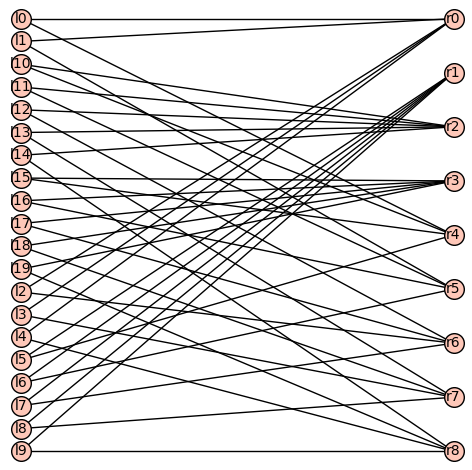

In [4]:
## Creating the bipartite graph G whose bi-adjacency matrix is H

def bipartite_from_biadjacency(H):
    m = H.nrows()
    n = H.ncols()

    L = [f"l{j}" for j in range(n)]
    R = [f"r{i}" for i in range(m)]

    G = BipartiteGraph()
    G.add_vertices(L, left=True)
    G.add_vertices(R, right=True)

    for i in range(m):
        for j in range(n):
            if H[i, j] == 1:
                G.add_edge(f"l{j}", f"r{i}")
    return G

MyGraph = bipartite_from_biadjacency(H)
MyGraph.plot()

## Checking the lossless bipartite expander graph property

For a given bi-adjacency matrix $\mathbf{H} \in \{0,1\}^{m \times n}$ where $m \leq n$, we construct a Python function **check_expander(H,gamma,c,epsilon)** that takes four arguments $\mathbf{H} \in \{0,1\}^{m \times n}$, $\gamma \in [0,1]$, $c \in \mathbb{Z}^+$, and $\epsilon \in (0,1/2)$ and verfies the expander property of the the graph (based on its bi-adjacency matrix), that is: $\forall S \subseteq L$ ($|L| = n$) where $|S| \leq \gamma n$, we have $|N(S)| \geq c(1-\epsilon) |S|$ where $N(S)$ denotes the set of neighbors of $S$.

In [5]:
from itertools import combinations
import math

def check_expander(H, gamma, c, epsilon,
                   check_left_regular=True,
                   return_counterexample=False):
    """
    Works in Sage (Matrix) and in Python (list-of-lists / numpy array), as long as H supports row/col access H[i][j] or H[i,j].
    """

    # --- Sage/Python compatible accessors + force Python ints for m,n ---
    if hasattr(H, "nrows") and hasattr(H, "ncols"):
        m, n = int(H.nrows()), int(H.ncols())
        get = lambda i, j: int(H[i, j])
    else:
        m, n = len(H), len(H[0])
        get = lambda i, j: int(H[i][j])

    assert 0 <= gamma <= 1
    assert 0 < float(epsilon) < 0.5
    assert int(c) > 0

    c = int(c)                 # ensure Python int
    epsilon = float(epsilon)   # use float for alpha/ceil (OK for small experiments)

    K = int(math.floor(gamma * n))
    if K <= 0:
        return (True, {"checked_up_to": 0}) if return_counterexample else True

    alpha = c * (1.0 - epsilon)

    # --- precompute neighbor bitmask for each column j (as Python ints) ---
    col_mask = [0] * n
    col_wt   = [0] * n
    one = 1  # Python int

    for j in range(n):
        mask = 0  # Python int
        wt = 0
        for i in range(m):
            if get(i, j) == 1:
                mask |= (one << i)
                wt += 1
        col_mask[j] = mask
        col_wt[j] = wt

    # optional: verify c-left-regular
    if check_left_regular and any(w != c for w in col_wt):
        if return_counterexample:
            bad = [j for j, w in enumerate(col_wt) if w != c]
            return False, {"reason": "not_c_left_regular", "bad_columns_0_based": bad}
        return False

    # brute force all S up to size K
    for s in range(1, K + 1):
        required = int(math.ceil(alpha * s - 1e-12))
        if required > m:
            if return_counterexample:
                return False, {"reason": "required_exceeds_m", "subset_size": s,
                               "required": required, "m": m}
            return False

        for S in combinations(range(n), s):
            neigh = 0  # Python int
            for j in S:
                neigh |= col_mask[j]
            neigh_size = int(neigh).bit_count()  # now always valid

            if neigh_size < required:
                if return_counterexample:
                    return False, {
                        "reason": "expansion_violated",
                        "subset_size": s,
                        "subset_0_based": list(S),
                        "neighborhood_size": neigh_size,
                        "required": required
                    }
                return False

    return (True, {"checked_up_to": K}) if return_counterexample else True

Some testing of the function **check_expander** for some parameters.

In [6]:
test_H = H
test_gamma = 3/20.0
test_c = 2
test_epsilon = 1/3.0
show(check_expander(test_H,test_gamma,test_c,test_epsilon,True,True))

(True, {'checked_up_to': 3})

In [7]:
test_H_1 = H
test_gamma_1 = 4/20.0
test_c_1 = 2
test_epsilon_1 = 1/3.0
show(check_expander(test_H_1,test_gamma_1,test_c_1,test_epsilon_1,True,True))

(False,
 {'reason': 'expansion_violated',
  'subset_size': 4,
  'subset_0_based': [0, 1, 2, 3],
  'neighborhood_size': 5,
  'required': 6})

## Checking that $\mathrm{Row}_\mathbb{Z}(\mathbf{H}_{(T)}) = \mathbb{Z}^{|T|}$ for every $T \subseteq [1,n]$ with $|T| < 2\gamma(1-\epsilon) n$

We build a function that check whether $\mathrm{Row}_\mathbb{Z}(\mathbf{A}) = \mathbb{Z}^{|T|}$ for $\mathbf{A} \in \mathbb{Z}^{m \times |T|}$ where $|T| \leq m$. We use SNF technique to verify this condition. If $\mathbf{A} \in \mathbb{Z}^{m \times |T|}$ with $\mathrm{rank}_\mathbb{Q}(\mathbf{A}) = r$, then according to SNF of $\mathbf{A}$, there are unimodular matrices $\mathbf{U} \in GL_m(\mathbb{Z}), \mathbf{V}\in GL_{|T|}(\mathbb{Z})$, and a diagonal matrix $\mathbf{D} \in \mathbb{Z}^{m \times |T|}$ with $\mathbf{D} = \mathrm{diag}(d_1,\dots,d_r,0,\dots,0)$ where $d_i > 0$ and $d_i \mid d_{i+1}$ for $i \in [1,r-1]$, such that $\mathbf{U}\mathbf{A}\mathbf{V}=\mathbf{D}$. We have $\mathbf{A} = \mathbf{U}^{-1}\mathbf{D}\mathbf{V}^{-1}$ and we get $\mathrm{Row}_\mathbb{Z}(\mathbf{A}) = \mathrm{Row}_\mathbb{Z}(\mathbf{D})$. Thus, $\mathrm{Row}_\mathbb{Z}(\mathbf{A}) = \mathrm{Row}_\mathbb{Z}(\mathbf{D}) = \mathbb{Z}^{|T|}$ if and only if $\mathrm{rank}_\mathbb{Q}(\mathbf{A}) = |T|$ and $d_1 = \cdots = d_{|T|} = 1$.

In [8]:
def row_lattice_is_full_Z(A):
    """
    A: Sage integer matrix (m x t) over ZZ. Returns True iff Row_Z(A) = Z^t.
    """
    m, t = A.nrows(), A.ncols()
    if t == 0:
        return True
    if A.rank() < t:   # rank over QQ
        return False
    D, U, V = A.smith_form()   # D is diagonal Smith form
    return all(D[i, i] == 1 for i in range(t))

In [9]:
from itertools import combinations

def check_row_span_property(H, gamma, eps, return_counterexample=False):
    """
    Checks: for all T ⊆ [n] with 1 ≤ |T| < 2*gamma*(1-eps)*n, Row_Z(H_(T)) = Z^{|T|}.
    H: Sage matrix (m x n) over GF(2), ZZ, etc. with integer entries.
    gamma: real/rational in [0,1]
    eps: real/rational in (0,1/2)
    """
    m, n = int(H.nrows()), int(H.ncols()) 
    K1 = int(floor(gamma * n))
    K2 = int(floor(2*gamma*(1-eps)*n))-1
    K = max(K1,K2)

    if K <= 0:
        return (True, {"checked_up_to": 0}) if return_counterexample else True

    # Work over ZZ
    HZ = Matrix(ZZ, H)

    for t in range(1, K + 1):
        for T in combinations(range(n), t):      # 0-based column indices
            A = HZ[:, list(T)]                  # m x t submatrix H_(T)
            if not row_lattice_is_full_Z(A):
                if return_counterexample:
                    return False, {
                        "reason": "row_span_not_full",
                        "bad_T_0_based": list(T),
                        "size": t
                    }
                return False

    return (True, {"checked_up_to": K}) if return_counterexample else True

In [10]:
test_H = H
test_gamma = 3/20.0
test_eps = 1/3.0
show(check_row_span_property(test_H,test_gamma,test_eps,True))

(True, {'checked_up_to': 3})

In [11]:
test_H_1 = H
test_gamma_1 = 4/20.0
test_c_1 = 2
test_epsilon_1 = 1/3.0
show(check_expander(test_H_1,test_gamma_1,test_c_1,test_epsilon_1,True,True))

(False,
 {'reason': 'expansion_violated',
  'subset_size': 4,
  'subset_0_based': [0, 1, 2, 3],
  'neighborhood_size': 5,
  'required': 6})

## Randomizing $\mathbf{H}$ using random signed permutation matrix.

We consider the following lemma.

Let $\mathbf{H} \in \mathbb{Z}^{m \times n}$ and $\mathbf{U} \in GL_m(\mathbb{Z})$ be a unimodular matrix. Define $\mathbf{H}' = \mathbf{U} \mathbf{H} \in \mathbb{Z}^{m \times n}$. Let $C_\mathbb{Q} = \ker_\mathbb{Q}(\mathbf{H})$ and $C_\mathbb{Q}' = \ker_\mathbb{Q}(\mathbf{H}')$ be the corresponding linear codes over $\mathbb{Q}$. Then $C_\mathbb{Q}' = C_\mathbb{Q}$ and hence $d(C_\mathbb{Q}) = d(C_\mathbb{Q}')$.

To randomize $\mathbf{H}$ yet keeping entries small, we update $\mathbf{H}:= \mathbf{U}\mathbf{H}$ where $\mathbf{U} \in GL_m(\mathbb{Z}) \cap \{-1,0,1\}^{m \times m}$ is a signed permutation matrix.

In [12]:
import random 

# generating a random signed permutation matrix
def random_signed_permutation_matrix(n,rng):
    '''
    generate a reproducible random n x n signed permutation matrix,
    a permutation matrix is obtained by permuting the rows of an identity matrix,
    a signed permutation matrix is obtained by randomly multiplying the rows 
    of a permutation matrix with -1 or +1
    '''
    perm = list(range(n))
    rng.shuffle(perm) # shuffle row indices
    I = identity_matrix(n)
    P = I[perm,:] # permute the rows of I according to perm
    for i in range(n):
        sign = rng.choice([-1,1])
        P[i,:] *= sign # P[i,:] := sign * P[i,:]
    return P

In [13]:
def randomized_H(H,seed):
    rng = random.Random(int(seed))
    m = H.nrows()
    U = random_signed_permutation_matrix(m,rng)
    return U*H

In [14]:
H_ori = H # saving the original H in H_ori
H = randomized_H(H,10)
test_H = H
show(H)
show(check_row_span_property(test_H,test_gamma,test_eps,True))

[ 0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1  0  0  0  0  0]
[ 0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0]
[ 0  0  0  0  0  1  1  1  1  1  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1]
[-1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1]
[ 0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0]
[-1 -1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

(True, {'checked_up_to': 3})

## Checking the distance of of the code whose parity check matrix is $\mathbf{H}$

Recall that $\mathbf{G} = \begin{bmatrix}\mathbf{g} & \mathbf{\hat{G}}\end{bmatrix}$ and the privacy of the scheme relates to the minimum distance of $\mathcal{\hat{C}}^\bot$. Since $\mathcal{\hat{C}} = \mathrm{Col}_\mathbb{Z}(\mathbf{\hat{G}})$, we have $\mathcal{\hat{C}}^\bot = \{\mathbf{x} \in \mathbb{Z}^n: \mathbf{\hat{G}}^\top \mathbf{x}= \mathbf{0}\} = \ker_\mathbb{Z}(\mathbf{\hat{G}}^\top)$. If $\mathbf{\hat{G}}^\top = \mathbf{H}$, then $\mathcal{\hat{C}}^\bot = \ker_\mathbb{Z}(\mathbf{\hat{G}}^\top) = \ker_\mathbb{Z}(\mathbf{H}) = \mathcal{D}$ where $\mathcal{D}$ is a code for which $\mathbf{H}$ is a parity check matrix. Therefore, $d(\mathcal{\hat{C}}^\bot) = d(\mathcal{D})$, and so optimizing the minimum distance of $\mathcal{\hat{C}}$ reduces to choosing $\mathbf{H}$ to be a parity check matrix of a code $\mathcal{D}$ with good minimum distance.

Notice that if $d_p(\mathcal{C})$ and $d_\mathbb{Q}(\mathcal{C})$ are respectively the distance of the code over $\mathbb{F}_p$ and $\mathbb{Q}$, we have $d_p(\mathcal{C}) \leq d_\mathbb{Q}(\mathcal{C})$.

In [15]:
test_H = Matrix(GF(3),H)
show(test_H)
test_C_hat_bot = codes.from_parity_check_matrix(test_H)
show(test_C_hat_bot)
test_d_C_hat_bot = test_C_hat_bot.minimum_distance()
show("minimum distance: ",test_d_C_hat_bot)

[0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
[0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 0 0 0 0 0]
[0 0 0 2 0 0 0 0 2 0 0 0 0 2 0 0 0 0 2 0]
[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]
[2 0 0 0 0 2 0 0 0 0 2 0 0 0 0 2 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2]
[0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0]
[2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

[20, 12] linear code over GF(3)

'minimum distance: ' 4

In [16]:
test_H_ori = Matrix(GF(2),H_ori)
show(test_H_ori)
test_C_hat_bot_ori = codes.from_parity_check_matrix(test_H_ori)
show(test_C_hat_bot_ori)
test_d_C_hat_bot_ori = test_C_hat_bot_ori.minimum_distance()
show("minimum distance: ",test_d_C_hat_bot_ori)

[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
[0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
[0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0]
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0]
[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]

[20, 12] linear code over GF(2)

'minimum distance: ' 4

# Constructing $\mathbf{g}$ for $\mathbf{G} = \begin{bmatrix}\mathbf{g} & \mathbf{\hat{G}}\end{bmatrix}$

We construct $\mathbf{g}$ by planting small disjoint supports $T \subseteq [1,n]$ on which the reconstruction is guaranteed. We say a support $T \subseteq [1,n]$ is certified if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_T)$. Observe that if $T$ is certified, then any superset $S \supseteq T$ is also certified, i.e., $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$. Now, suppose we have $b \in \mathbb{Z}^+$ disjoint certified supports $T_1,\dots,T_b$, i.e., $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_{T_i})$, for every $i \in [1,b]$. We consider the following lemma.

**Lemma**: If $T_1,\dots,T_b$ are disjoint certified supports, then any $S \subseteq [1,n]$ with $|S| \geq n - b + 1$ contains at least one $T_i$, and hence certified. That is, for any $S \subseteq [1,n]$ with $|S| \geq n - b + 1$, we have $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$.

We can attempt to maximize $b$ in the lemma by minimizing $|T_i|$, guided by an estimate of $\hat{d}^\bot$ (i.e., the distance of $C_\mathbf{H}$) and the known value of $\mathrm{rank}_\mathbb{Q}(\mathbf{H})$. If a non-zero kernel vector cannot be found at a target size $|T_i|$, we increase $|T_i|$ until one is found whenever it is possible (notice that a non-zero vector in $\ker_\mathbb{Z}(\mathbf{H}_{(T_i)})$ exists if $|T_i| \geq \mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1$). With this approach, we have $\bigcup_{i \in [1,b]}T_i \subseteq [1,n]$ and $\left|[1,n] \setminus \bigcup_{i=1}^b T_i\right| \leq \mathrm{rank}_\mathbb{Q}(\mathbf{H})$. We define $\mathbf{g}$ by fixing coordinates on each $T_i$ and for the remaining indices $j \in [1,n] \setminus \bigcup_{i=1}^b T_i$, we might set $\mathbf{g}[j] \in \{-1,0,1\}$ as a heuristic to boost the correctness probability. Moreover, we search for primitive $\bm{\lambda}_{T_i} \in \ker_\mathbb{Z}(\mathbf{H}_{(T_i)})$ with small components and prefer $(\mathbf{g})_{T_i}$ with small entries (e.g., $(\mathbf{g})_{T_i} \in \{-1,0,1\}^{|T_i|}$ whenever possible). Such choices of $\bm{\lambda}_{T_i}$ and $(\mathbf{g})_{T_i}$ are often possible when $\mathbf{H}$ is sparse and has small entries (e.g., $\mathbf{H}$ is a parity check matrix of LDPC code family).

If we construct $\mathbf{g}$ by planting disjoint support as mentioned above, the deterministic correctness threshold is given by $k_p^\mathsf{det} = n - b + 1$ where $b$ is the number of disjoint supports.
Because $\mathbf{\hat{G}} = \mathbf{H}^\top \in \mathbb{Z}^{n \times k-1}$, we have $\hat{d}^\bot \leq |T_i| \leq \mathrm{rank}_\mathbb{Q}(\mathbf{H})+1 \leq k$, and so $\left\lfloor\frac{n}{\mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1}\right\rfloor \leq b \leq \left\lfloor\frac{n}{\hat{d}^\bot}\right\rfloor$. This implies $n - \left\lfloor\frac{n}{\hat{d}^\bot}\right\rfloor + 1\leq k_p^\mathsf{det}\leq  n - \left\lfloor\frac{n}{\mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1}\right\rfloor  + 1 \leq n - \left\lfloor \frac{n}{k}\right\rfloor+1$. We construct the algorithm for constructing $\mathbf{g}$ for a given $\mathbf{H} \in \mathbb{Z}^{m \times n}$.

1. **Input**: $\mathbf{H} \in \mathbb{Z}^{m \times n}$ (the parity check matrix of an expander code with distance $\hat{d}^\bot$), target starting size $t_0$ (estimate of $\hat{d}^\bot$, $t_{\max} = \mathrm{rank}_\mathbb{Q}(\mathbf{H}) + 1$, and $R \in \mathbb{Z}^+$ (maximum trials for random candidates).
2. **Output**: $\mathbf{g}$ (the first column of $\mathbf{G}$ and $\mathcal{T}$ (the disjoint sets of indices for planted certified supports).
3. Initialize $\Omega := [1,n]$, $\mathbf{g}:= \mathbf{0}$, $\mathcal{T} = \emptyset$ (set of lists of indices for planted support).
4. While $|\Omega| \geq t_0$ do:
   1. $Found := \mathbf{False}$
   2. For $t = t_0$ to $\min\{t_{\max},|\Omega|\}$ do
      1. If $t < t_{\max}$:
         1. Try up to $R$ random subsets $T \subseteq \Omega$ with $|T| = t$.
         2. If some $T$ satisfies $\ker_\mathbb{Z}(\mathbf{H}_{(T)}) \supsetneq \{\mathbf{0}\}$: record $T$, set $Found := \mathbf{True}$; **break** the for loop.
         3. If $t$ reach $t_{\max}$, we choose any $T \subseteq \Omega$, set $Found := \mathbf{True}$; **break** the for loop.
    3. If **not** $Found$, **break** the while loop (we cannot plant any more supports).
    4. Find a primitive $\bm{\lambda}_T \in \ker_\mathbb{Z}(\mathbf{H}_{(T)})$ (prefer $\bm{\lambda}_T$ with small entries).
    5. Solve $\bm{\lambda}_T^\top (\mathbf{g})_T = 1$ for $(\mathbf{g}))T$ (generalized Bezout's identity).
    6. Set $\mathbf{g}[j] := (\mathbf{g})_T[j]$ for each $j \in T$.
5. Set $\mathbf{g}[j] \in \{-1,0,1\}$ (often $0$) for the remaining indices to boost correctness.
6. Return $\mathbf{g}$.

## Some basic helper functions

Several helper functions:
1. gcd_vec(vals): computing the gcd of lists of numbers (vals).
2. make_primitive(v): making the vector v a primitive vector.
3. hamming_weight(v): computing the Hamming weight of a vector v.
4. has_pm1(v): checking whether v has -1/+1 components.
5. in_pm1(v): checking whether all components of v are -1/0/+1. 

In [17]:
# computing the gcd of vector components

def gcd_vec(vals):
    """
    vals can be a Python list, Sage vector, or free-module element.
    Returns gcd of entries as a nonnegative ZZ integer.
    """
    g = ZZ(0)
    for x in vals:
        g = gcd(g, ZZ(x))
    return abs(g)


# making a vector v as primitive by dividing the components with the gcd of the components.
def make_primitive(v):
    """
    Return primitive vector by dividing all coordinates by gcd.
    Works for free-module elements and vectors.
    """
    g = gcd_vec(v)
    if g == 0:
        # v is the zero vector
        return vector(ZZ, list(v))
    return vector(ZZ, [ZZ(x)//g for x in v])


# computing the Hamming weight
def hamming_weight(v):
    return sum(1 for x in v if ZZ(x) != 0)

# check whether a vector has -1/+1 components
def has_pm1(v):
    return any(abs(ZZ(x)) == 1 for x in v)

# check whether the entries of a vector are-1/0/+1
def in_pm1(v):
    for x in v:
        if ZZ(x) not in [-1, 0, 1]:
            return False
    return True

## Constructing the kernel basis on a support $T$, i.e., we find the basis of $\ker_\mathbb{Z}(\mathbf{H}_{(T)})$

$\mathbf{B}$ is a matrix whose rows are the basis of $\ker_\mathbb{Z}(\mathbf{H}_{(T)}$. We apply LLL to the basis matrix $\mathbf{B}$ to transform it into a short basis. LLL might be used when $\mathbf{B} \in \mathbb{Z}^{m \times |T|}$ with $m \geq 2$.

In [18]:
def kernel_basis_on_support(HZZ, T, use_lll=True):
    """
    HZZ: m x n matrix over ZZ
    T: list of column indices (0-based)
    Returns a basis matrix whose rows span ker_Z(H_{(T)}), over ZZ.
    If use_lll=True and kernel rank >= 2, LLL-reduce the basis rows.
    """
    # Make sure T is clean (optional but recommended)
    T = sorted(set(T))

    HT = HZZ[:, T]                      # m x |T|
    K  = HT.right_kernel(ZZ)            # Z-module kernel
    B  = K.basis_matrix()               # rows are a Z-basis (possibly not "nice")

    # LLL changes the basis but not the lattice it spans
    if use_lll and B.nrows() > 1:
        B = B.LLL()
    return B

Pick a good primitive $\bm{\lambda}_T$ based on some basis matrix $\mathbf{B}$.

In [19]:
def pick_primitive_lambda(B):
    """
    B: matrix over ZZ, rows are a Z-basis of a kernel.
    Returns a primitive nonzero vector (ZZ-vector), or None if kernel trivial.
    """
    if B.nrows() == 0:
        return None

    best = None
    best_score = None

    for i in range(B.nrows()):
        v = B.row(i)                                 # free-module element / vector-like
        if all(ZZ(x) == 0 for x in v):
            continue
        
        v = make_primitive(v)

        score = (
            0 if has_pm1(v) else 1,                  # prefer ±1 entry
            hamming_weight(v),                       # then sparse
            max(abs(ZZ(x)) for x in v)               # then small coefficients
        )
        if best is None or score < best_score:
            best, best_score = v, score

    return best

A wrapper that computes the basis $\bm{\lambda}_T$ on a support $T$. We consider using LLL to aim for a good (small and nearly orthogonal) basis.

In [20]:
def find_good_lambda_on_support(HZZ, T, use_lll=True):
    B = kernel_basis_on_support(HZZ, T, use_lll=use_lll)
    lam = pick_primitive_lambda(B)
    return lam

## Fast rejection of $T$

We are interested to find $T \subseteq [1,n]$ such that $\ker_\mathbb{Z}(\mathbf{H}_{(T)}) \supsetneq \{\mathbf{0}\}$. Notice that we have $\ker_\mathbb{Q}(\mathbf{H}_{(T)}) \supsetneq \{\mathbf{0}\}$ if and only if $\mathrm{rank}_{\mathbb{Q}}(\mathbf{H}_{(T)}) < |T|$. Since the entries of the matrices are small, we can consider using a small finite field $\mathbb{F}_p$ instead of $\mathbb{Q}$. If $\mathrm{rank}_{\mathbb{F}_p}(\mathbf{H}_{(T)}) = |T|$, then it is guaranteed that (since the entries of $\mathbf{H}$ is small), we have $\mathrm{rank}_\mathbb{Q}(\mathbf{H}_{(T)} = |T|$, which implies $\ker_\mathbb{Q}(\mathbf{H}_{(T)}) = \{\mathbf{0}\}$, and so $\ker_\mathbb{Z}(\mathbf{H}_{(T)}) = \{\mathbf{0}\}$.

In [21]:
def fast_reject_full_rank_modp(HZZ, T, primes=(101, 103, 107)):
    """
    Return True if we can safely reject T because H[:,T] has full column rank mod p
    for at least one prime p in primes.
    Safe: if it returns True, then rank_QQ(H[:,T]) = |T|, hence no integer kernel.
    """
    HT = HZZ[:, T]
    m, t = HT.nrows(), HT.ncols()
    if t > m:
        return False
    for p in primes:
        r = HT.change_ring(GF(p)).rank()
        if r == t:
            return True
    return False

## Constructing $(\mathbf{g})_T$ from $\bm{\lambda}_T$.

### Option 1: quick scan

Option 1: finding $(\mathbf{g})_T$ if $\bm{\lambda}_T$ is a vector whose components are either $-1$, $0$, or $+1$ quickly. Notice that if $\bm{\lambda}_T \in \ker_\mathbb{Z}(\mathbf{H}_{(T)}) \setminus \{\mathbf{0}\}$ and $\bm{\lambda}_T \in \{-1,0,1\}^{|T|}$ and $(\mathbf{g})_{T} \in \mathbb{Z}^{|T|}$ satisfies $\bm{\lambda}_T^\top(\mathbf{g})_T=1$, we can set $(\mathbf{g})_T$ as a vector whose entries are all $0$ except in the first index $j$ such that $\bm{\lambda}_S[j]$ is non-zero. Let this index be $j$, then we set $(\mathbf{g})_S[j] = 1$ if $\bm{\lambda}_S[j] =1 $ and $(\mathbf{g})_S[j] = -1$ if $\bm{\lambda}_S[j] = -1$. The technique in option 1 is used for the next technique. We call this function **g_on_support_unit**.

Basically, the objective of this function is to produce $(\mathbf{g})_T$ with the following properties:
1. $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$,
2. $\bm{\lambda}_T^\top (\mathbf{g})_T = 1$,
3. $\|(\mathbf{g})_T\|_1 = 1$.

In [22]:
# option 1: finding g if lambda is a vector whose components are either -1, 0, or 1 quickly

def g_on_support_unit(lambda_T):
    """
    Option 1:
    If lambda_T has a ±1 entry, return g_T in {-1,0,1}^{|T|} with lambda_T^T * g_T = 1.

    Strategy:
      - If lambda_T[j] == +1, set g_T[j] = +1 (others 0).
      - Else if lambda_T[j] == -1, set g_T[j] = -1 (others 0).
      - If no ±1 entry exists, return None.
    """
    lam = vector(ZZ, list(lambda_T))
    t = len(lam)
    gT = vector(ZZ, [0]*t)

    # Prefer +1 pivot, then -1 pivot
    for j in range(t):
        if lam[j] == 1:
            gT[j] = 1
            return gT

    for j in range(t):
        if lam[j] == -1:
            gT[j] = -1
            return gT

    return None

### Option 2: using the generalized Bezout's identity

Option 2: finding $(\mathbf{g})_T$ by aiming for $(\mathbf{g})_T$ with higher Hamming weight. We might call **g_on_support_unit** as a subroutine.

Generalized Bezout identity. For an input $\bm{\lambda} \in \mathbb{Z}^t$, the output is $\mathbf{g}\in \mathbb{Z}^t$ such that $\bm{\lambda}^\top \mathbf{g} = 1$.

In [23]:
# bezout helper

def bezout_solution_for_dot_1(lam):
    """
    Given lam in ZZ^t with gcd(lam)=1, return g in ZZ^t such that lam^T * g = 1.

    Returns None if gcd(lam) != 1 or lam is all-zero.
    Uses iterative extended gcd folding; robust to zeros.
    """
    lam = vector(ZZ, list(lam))
    t = len(lam)

    # positions of nonzero entries
    nz = []
    for i in range(t):
        if lam[i] != 0:
            nz.append(i)
    if len(nz) == 0:
        return None # lam is all-zero

    # check gcd condition explicitly
    if gcd_vec(lam) != 1:
        return None

    # start with the first non-zero coordinate
    i0 = nz[0]
    current = ZZ(lam[i0])
    coeffs = [ZZ(0)] * t
    coeffs[i0] = ZZ(1)

    # fold in remaining nonzero coordinates
    for i in nz[1:]:
        gg, u, v = xgcd(current, lam[i])   # u*current + v*lam[i] = gg
        coeffs = [ZZ(u) * c for c in coeffs]
        coeffs[i] = coeffs[i] + ZZ(v)
        current = ZZ(gg)
        if current == 1 or current == -1:
            break

    # normalize sign: current = +1
    if current == -1:
        coeffs = [-c for c in coeffs]
        current = ZZ(1)

    if current != 1:
        return None

    return vector(ZZ, coeffs)

**make_dense_g** takes a vector $\bm{\lambda}_T \in \mathbb{Z}^{|T|}$ and output a vector $(\mathbf{g})_T \in \mathbb{Z}^{|T|}$ using the following approach:
1. Consider finding $(\mathbf{g})_T$ using option 1 (i.e., **g_on_support_unit(lambda_T)**) to keep $(\mathbf{g})_{T}$ sparse. If it is not possible, we consider the generalized Bezout identity approach.
2. Optionally densify $\bm{\lambda}_T$ by: filling the indices $i \in T$ such that $\bm{\lambda}_T[i] = 0$ with non-zero values (default $1$) and add canceling pairs to keep the dot product unchanged.

In **make_dense_g(lambda_T, fill_zero_coords=True, nonzero_value=1, max_pair_fills=None)**:
1. fill_zero_coords=False to keep $(\mathbf{g})_T$ dense (heuristic to increase the correctness probability).
2. max_pair_fills to cap the number of canceling pairs we add. 

In [24]:
# option 2: find g in general, dense-by-default (fills lam=0 positions)

def make_dense_g(lambda_T, fill_zero_coords=True, nonzero_value=1, max_pair_fills=None):
    """
    Option 2 (dense by default):
    Build gT in ZZ^{|T|} such that lam^T * gT = 1, then optionally densify.

    Default: fill_zero_coords=True.

    Densification steps:
      (A) fill free coordinates where lam[j]=0 (does not change dot product)
      (B) add canceling pairs among remaining coordinates to keep dot fixed

    Returns:
      gT (ZZ vector) or None.
    """
    lam = vector(ZZ, list(lambda_T))
    lam = make_primitive(lam)

    if gcd_vec(lam) != 1:
        return None

    t = len(lam)

    # (1) base solution: unit if possible, otherwise Bézout
    gT = g_on_support_unit(lam)
    if gT is None:
        gT = bezout_solution_for_dot_1(lam)
        if gT is None:
            return None

    # (2) fill free coords lam[j]=0
    if fill_zero_coords:
        for j in range(t):
            if lam[j] == 0 and gT[j] == 0:
                gT[j] = ZZ(nonzero_value)

    # (3) canceling pairs among remaining zeros where lam != 0
    idx = [j for j in range(t) if lam[j] != 0 and gT[j] == 0]
    filled = 0

    for a in range(len(idx)):
        for b in range(a + 1, len(idx)):
            if max_pair_fills is not None and filled >= max_pair_fills:
                break

            i = idx[a]
            j = idx[b]

            if gT[i] != 0 or gT[j] != 0:
                continue

            # Case 1: lam[i] == lam[j] => set (g[i], g[j]) = (1, -1)
            if lam[i] == lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(-1)

            # Case 2: lam[i] == -lam[j] => set (g[i], g[j]) = (1, 1)
            elif lam[i] == -lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(1)

            else:
                continue

            # safety check
            if lam.dot_product(gT) != 1:
                gT[i] = ZZ(0)
                gT[j] = ZZ(0)
            else:
                filled += 1

        if max_pair_fills is not None and filled >= max_pair_fills:
            break

    if lam.dot_product(gT) != 1:
        return None

    return gT

### Option 3: prefer dense $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$

Option 3: finding $(\mathbf{g})_T$ if $\bm{\lambda}_T$ by aiming for $(\mathbf{g})_T$ with higher Hamming weight while maintaining $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$. We use **g_on_support_unit** as a subroutine.

In [25]:
# option 3: find g, aim g with a higher Hamming weight, but its entries are in {-1,0,1}

def make_dense_g_pm1(lambda_T, fill_zero_coords=True, max_pair_fills=None):
    """
    Option 3:
    Build gT in {-1,0,1}^{|T|} such that lam^T * gT = 1, aiming for higher Hamming weight.

    Requires:
      - gcd(lam)=1
      - lam has a ±1 entry (so unit base exists)

    Densification:
      (A) fill lam[j]=0 coords with +1
      (B) add canceling pairs with pm1 assignments
    """
    lam = vector(ZZ, list(lambda_T))
    lam = make_primitive(lam)

    if gcd_vec(lam) != 1:
        return None

    t = len(lam)

    # base must exist in pm1
    gT = g_on_support_unit(lam)
    if gT is None:
        return None

    # (A) fill free coordinates (lam=0) with +1
    if fill_zero_coords:
        for j in range(t):
            if lam[j] == 0 and gT[j] == 0:
                gT[j] = ZZ(1)

    # (B) canceling pairs among remaining zeros with lam != 0
    idx = [j for j in range(t) if lam[j] != 0 and gT[j] == 0]
    filled = 0

    for a in range(len(idx)):
        for b in range(a + 1, len(idx)):
            if max_pair_fills is not None and filled >= max_pair_fills:
                break

            i = idx[a]
            j = idx[b]

            if gT[i] != 0 or gT[j] != 0:
                continue

            if lam[i] == lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(-1)
            elif lam[i] == -lam[j]:
                gT[i] = ZZ(1)
                gT[j] = ZZ(1)
            else:
                continue

            if lam.dot_product(gT) != 1:
                gT[i] = ZZ(0)
                gT[j] = ZZ(0)
            else:
                filled += 1

        if max_pair_fills is not None and filled >= max_pair_fills:
            break

    # sanity checks
    if lam.dot_product(gT) != 1:
        return None

    for x in gT:
        if x not in [-1,0,1]:
            return None

    return gT

As a preferred policy, we try option 3 first, if it fails, we use option 2 (which is guaranteed to be succeed whenever the kernel is non-trivial).

In [26]:
def construct_gT(lambda_T,
                 opt3_fill_zero_coords=True, 
                 opt3_max_pair_fills=None,
                 opt2_fill_zero_coords=True, 
                 opt2_nonzero_value=1, 
                 opt2_max_pair_fills=None):
    """
    Policy:
      - Try Option 3 first (pm1-only).
      - If it fails, fall back to Option 2 (general dense-by-default).
    Return gT
    """
    g3 = make_dense_g_pm1(lambda_T,
                          fill_zero_coords=opt3_fill_zero_coords,
                          max_pair_fills=opt3_max_pair_fills)
    if g3 is not None:
        return g3

    g2 = make_dense_g(lambda_T,
                      fill_zero_coords=opt2_fill_zero_coords,
                      nonzero_value=opt2_nonzero_value,
                      max_pair_fills=opt2_max_pair_fills)
    if g2 is not None:
        return g2

    return None

## Choosing $T \subseteq \Omega$ with $|T| = t$ and $\ker_\mathbb{Z}(\mathbf{H}_{(T)})$ contains small non-zero vector

Technique 1: sliding window. We keep $\Omega$ sorted and try consecutive chunks of size exactly $t$.

In [27]:
# sliding window technique
def candidates_window(Omega, t):
    """
    Sliding window technique:
    Yield subsets of size exactly t by trying consecutive chunks of Omega (sorted).
    Omega can be any iterable (list, set, etc.).
    """
    Omega = list(Omega)
    Omega.sort()

    if t > len(Omega):
        return

    for start in range(0, len(Omega) - t + 1):
        yield Omega[start:start + t]

Technique 2: random subset. We choose a random subset $T \subseteq \Omega$ of size exactly $t$.

In [28]:
# random subset technique
def candidates_random(Omega, t, trials=100, rng=None):
    """
    Random subset technique:
    Yield subsets of size exactly t by random sampling from Omega.

    Requirements:
      - rng must be provided for reproducibility (e.g., random.Random(seed)).
    """
    if rng is None:
        raise ValueError("candidates_random requires rng for reproducibility.")

    Omega = list(Omega)

    if t > len(Omega):
        return

    for _ in range(trials):
        T = rng.sample(Omega, t)
        T.sort()
        yield T

Choosing $T$ with a hybrid approach. We try several candidates (using the sliding window and random subset technique), compute a "score" for each subset $T$. The score of each subset depends on $(\mathbf{g})_T$ with the following preferences:
1. $(\mathbf{g})_T \in \{-1,0,1\}^{|T|}$.
2. Smaller $|\mathrm{supp}(\bm{\lambda}_T)|$ (i.e., smaller $wt_H(\bm{\lambda}_T)$).
3. Smaller $\|\bm{\lambda}_T\|_\infty$.
4. Denser $(\mathbf{g})_T$ (i.e., higher $wt_H((\mathbf{g})_T)$.

We consider the function **choose_best_candidate(HZZ, Omega, t, K=50, rng=None, max_abs_coeff=10, nonzero_value=1,mode="Dense",use_lll=True,fallback_to_option2=True)**:
1. HZZ is the matrix (over the integers).
2. Omega is the list of indices, $\Omega \subseteq [1,n]$ (initially $\Omega = [1,n]$).
3. $t$ is the subset size.
4. $K$ is the number of candidates to try (default value $50$).
5. rng is used for randomness reproducibility.
6. max_abs_coeff is the maximum of the absolute value of entries tolerated for $(\mathbf{g})_T$ (default value $10$).
7. nonzero_value is used in **construct_gT(lambda_T,opt3_fill_zero_coords=True,opt3_max_pair_fills=None,opt2_fill_zero_coords=True,opt2_nonzero_value=1,opt2_max_pair_fills=None)**.
8. mode="Dense" is the default so that we consider **construct_gT(lambda_T,opt3_fill_zero_coords=True,opt3_max_pair_fills=None,opt2_fill_zero_coords=True,opt2_nonzero_value=1,opt2_max_pair_fills=None)**. If mode="Sparse", then we consider **construct_gT(lambda_T,opt3_fill_zero_coords=False,opt3_max_pair_fills=None,opt2_fill_zero_coords=False,opt2_nonzero_value=1,opt2_max_pair_fills=None)**.
9. use_lll=True means the kernel basis is reduced using the LLL algorithm.
10. fallback_to_option2=True means that if we do not get the small solution, we might tolerate a larger value for the components of $(\mathbf{g})_T$ (up to max_abs_coeff). 

In [29]:
# hybrid method for choosing the best T

def choose_best_candidate(HZZ, Omega, t, K=50, rng=None,
                          max_abs_coeff=10, nonzero_value=1,
                          mode="Dense", use_lll=True,
                          fallback_to_option2=True):
    """
    Hybrid candidate selection.

    - Tries K candidates:
        * about half via sliding windows (deterministic)
        * the rest via random sampling (reproducible via rng)

    - For each candidate T:
        1) compute lam in ker_Z(H_(T)) (primitive, preferably small)
        2) build gT using construct_gT (Option 3 then Option 2) with Dense/Sparse settings
        3) optionally fallback to Option 2 directly if construct_gT fails
        4) reject if ||gT||_inf > max_abs_coeff
        5) score candidates and pick the best (lexicographic)

    Returns:
        (T_best, lam_best, gT_best) or (None, None, None)
    """
    if rng is None:
        raise ValueError("choose_best_candidate requires rng for reproducibility.")

    Omega = sorted(list(Omega))
    if t > len(Omega):
        return None, None, None

    # --- build candidate list ---
    cand_list = []

    # windows: take up to K//2 consecutive chunks
    win_limit = max(1, K // 2)
    for start in range(0, len(Omega) - t + 1):
        cand_list.append(Omega[start:start+t])
        if len(cand_list) >= win_limit:
            break

    # random candidates: fill remaining budget
    remaining = K - len(cand_list)
    if remaining > 0:
        for T in candidates_random(Omega, t, trials=remaining, rng=rng):
            cand_list.append(T)

    best_T = None
    best_lam = None
    best_gT = None
    best_score = None

    # --- evaluate candidates ---
    for T in cand_list:
        if fast_reject_full_rank_modp(HZZ, T, primes=(101,103,107)):
            continue  # definitely no kernel; skip expensive kernel computation
        
        lam = find_good_lambda_on_support(HZZ, T, use_lll=use_lll)
        if lam is None:
            continue

        # choose Dense/Sparse policy
        if mode == "Dense":
            gT = construct_gT(lam,
                              opt3_fill_zero_coords=True,
                              opt3_max_pair_fills=None,
                              opt2_fill_zero_coords=True,
                              opt2_nonzero_value=nonzero_value,
                              opt2_max_pair_fills=None)
        else:  # "Sparse"
            gT = construct_gT(lam,
                              opt3_fill_zero_coords=False,
                              opt3_max_pair_fills=None,
                              opt2_fill_zero_coords=False,
                              opt2_nonzero_value=nonzero_value,
                              opt2_max_pair_fills=None)

        # optional fallback (in case construct_gT returns None unexpectedly)
        if gT is None and fallback_to_option2:
            if mode == "Dense":
                gT = make_dense_g(lam,
                                  fill_zero_coords=True,
                                  nonzero_value=nonzero_value,
                                  max_pair_fills=None)
            else:
                gT = make_dense_g(lam,
                                  fill_zero_coords=False,
                                  nonzero_value=nonzero_value,
                                  max_pair_fills=None)

        if gT is None:
            continue

        # reject huge gT
        gT_inf = max(abs(ZZ(x)) for x in gT)
        if gT_inf > max_abs_coeff:
            continue

        pm1_ok = in_pm1(gT)

        # score: smaller is better
        score = (
            0 if pm1_ok else 1,                    # prefer gT in {-1,0,1}
            hamming_weight(lam),                   # smaller support of lambda
            max(abs(ZZ(x)) for x in lam),          # smaller lambda coefficients
            -hamming_weight(gT),                   # prefer denser gT (higher weight)
            gT_inf                                 # then smaller gT infinity norm
        )

        if best_score is None or score < best_score:
            best_score = score
            best_T = T
            best_lam = lam
            best_gT = gT

    if best_T is None:
        return None, None, None

    return best_T, best_lam, best_gT


## Main function to construct $\mathbf{g}$ from $\mathbf{\hat{G}} = \mathbf{H}^\top$

In [30]:
import random

def plant_supports_and_build_g(HZZ,
                               t0,
                               tmax=None,
                               K=50,
                               fill_remaining="zero",
                               mode="Dense",
                               max_abs_coeff=10,
                               nonzero_value=1,
                               rng=None,
                               seed=10,
                               use_lll=True,
                               fallback_to_option2=True,
                               primes=(101,103,107),
                               verbose=False):
    r"""
    Plant disjoint supports and build a global vector g.

    We maintain a remaining index set Omega \subseteq {0,1,...,n-1}. Each iteration:
      - pick a subset T \subseteq Omega of size t (starting from t0 and increasing up to tmax), such that ker_Z(H_{(T)}) is non-trivial,
      - choose a "good" primitive lambda_T in ker_Z(H_{(T)}),
      - construct g_T such that lambda_T^T * g_T = 1 (using the above construct_gT policy),
      - write g_T into the global vector g on coordinates T,
      - remove T from Omega (disjoint supports).

    Parameters
    ----------
    HZZ : Sage matrix over ZZ, shape (m, n)
          Parity-check matrix (integer entries, often -1/0/1).
    t0  : int
          Starting support size to try.
    tmax: int or None
          Maximum support size to try. If None, set to rank_QQ(HZZ)+1.
    K : int
        Number of candidates to try per call to choose_best_candidate.
    fill_remaining : str
                     How to fill g[j] for remaining j in Omega at the end:
                      - "zero" (default): set all remaining entries to 0
                      - "pm1": set remaining entries randomly in {-1,0,1}
                      - "pm1_nozero": set remaining entries randomly in {-1,+1}
    mode : str
           Passed to choose_best_candidate / construct_gT. ("Dense" or "Sparse")
    max_abs_coeff : int
           Reject any candidate whose ||g_T||_inf > max_abs_coeff.
    nonzero_value : int
           Passed into construct_gT (used when filling free coordinates in dense mode).
    rng : random.Random or None
          Random generator for reproducibility. If None, a new one is created from seed.
    seed : int
           Seed used to create rng if rng is None.
    use_lll : bool
              Whether to LLL-reduce kernel basis in find_good_lambda_on_support.
    fallback_to_option2 : bool
            Passed to choose_best_candidate. Safety net if construct_gT fails unexpectedly. (Default: True)
    primes : tuple of primes
             Primes used by fast_reject_full_rank_modp inside choose_best_candidate (if choose_best_candidate accepts it).
              Here we pass it manually in the loop below if we need to.
    verbose : bool
              If True, print progress (chosen t, support sizes, remaining Omega).

    Returns
    -------
    supports : list of lists
        List of planted supports T (each T is a sorted list of 0-based indices).
    lambdas : list of Sage vectors
        Corresponding primitive lambda_T vectors in ZZ^{|T|}.
        Note: lambda_T coordinates align with the column order in T.
    g : Sage vector over ZZ
        Global vector g in ZZ^n.
    rng : random.Random
        RNG used (for reproducibility).

    Notes
    -----
    - This function tries t = t0, t0+1, ..., min(tmax, |Omega|) each outer iteration.
      It accepts the first t for which choose_best_candidate returns a valid T.
      This biases toward smaller supports (helps maximize the number of disjoint supports).
    - Indices are assumed 0-based throughout.
    """
    # reproducible RNG
    if rng is None:
        rng = random.Random(int(seed))

    m, n = HZZ.nrows(), HZZ.ncols()
    t0 = int(t0)

    # rank over QQ is the correct notion for dependence
    rQ = HZZ.change_ring(QQ).rank()

    if tmax is None:
        tmax = int(rQ) + 1
    else:
        tmax = int(tmax)

    # Remaining indices (0-based)
    Omega = list(range(n))
    supports = []
    lambdas = []
    g = vector(ZZ, [0]*n)

    # Outer loop: continue while we can still fit a support of size t0
    while len(Omega) >= t0:
        found_any = False
        T_best = None
        lam_best = None
        gT_best = None

        # Try increasing sizes; stop at min(tmax, len(Omega))
        t_upper = min(tmax, len(Omega))

        for t in range(t0, t_upper + 1):
            # use choose_best_candidate for the best T of this size
            T, lam, gT = choose_best_candidate(HZZ, Omega, t,
                                               K=K,
                                               rng=rng,
                                               max_abs_coeff=max_abs_coeff,
                                               nonzero_value=nonzero_value,
                                               mode=mode,
                                               use_lll=use_lll,
                                               fallback_to_option2=fallback_to_option2)

            if T is None:
                continue

            # Sanity checks (optional but helpful)
            # - T should be sorted, 0-based, subset of Omega
            # - lam and gT lengths should match |T|
            if len(lam) != len(T) or len(gT) != len(T):
                # Something inconsistent; skip this candidate
                continue

            # Optional: verify dot product invariant (should hold if construct_gT works)
            if vector(ZZ, list(lam)).dot_product(vector(ZZ, list(gT))) != 1:
                continue

            # Accept the first size t that yields a valid candidate (bias for small supports)
            found_any = True
            T_best, lam_best, gT_best = T, lam, gT
            if verbose:
                print("Found support of size t =", t, "; |Omega| before =", len(Omega))
            break

        if not found_any:
            if verbose:
                print("No more supports found; stopping. |Omega| =", len(Omega))
            break

        # Plant gT_best into global g on coordinates T_best
        for pos in range(len(T_best)):
            j = T_best[pos]          # 0-based index in [0, n-1]
            g[j] = ZZ(gT_best[pos])  # gT_best is aligned with T_best order

        # Record planted support and lambda
        supports.append(list(T_best))
        lambdas.append(vector(ZZ, list(lam_best)))

        # Remove T_best from Omega (disjoint supports)
        Tset = set(T_best)
        Omega = [j for j in Omega if j not in Tset]

        if verbose:
            print("Planted support; |Omega| after =", len(Omega))

    # Fill remaining indices of g according to policy
    if fill_remaining == "zero":
        # already zero by initialization; nothing to do
        pass
    elif fill_remaining == "pm1":
        for j in Omega:
            g[j] = ZZ(rng.choice([-1, 0, 1]))
    elif fill_remaining == "pm1_nozero":
        for j in Omega:
            g[j] = ZZ(rng.choice([-1, 1]))
    else:
        raise ValueError("Unknown fill_remaining policy: {}".format(fill_remaining))

    return supports, lambdas, g, rng

We test the construction of $\mathbf{g}$ using previously defined $\mathbf{\hat{G}}^\top=\mathbf{H}$. The lower bound for he distance of the code is known in advance.

In [31]:
%%time
H
show(H)
# case 1: remaining zero, Dense, use_lll (1st choice, balanced)
(T1, lambdas1, g1, rng1) = plant_supports_and_build_g(
    H,4,tmax=None,K=100,fill_remaining="zero",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=10,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T1, lambdas1, g1))
# case 2: remaining pm1, Dense, use_lll (2nd choice, densest)
(T2, lambdas2, g2, rng) = plant_supports_and_build_g(
    H,4,tmax=None,K=100,fill_remaining="pm1",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=10,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T2, lambdas2, g2))
# case 3: remaining zero, Sparse, use_lll (3rd choice, sparsest)
(T3, lambdas3, g3, rng) = plant_supports_and_build_g(
    H,4,tmax=None,K=100,fill_remaining="zero",mode="Sparse",max_abs_coeff=10,nonzero_value=1,rng=None,seed=10,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T3, lambdas3, g3))

[ 0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1  0  0  0  0  0]
[ 0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0]
[ 0  0  0  0  0  1  1  1  1  1  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1]
[-1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1]
[ 0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0]
[-1 -1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

([[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]],
 [(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, -1, -1, 0, 0, -1, -1, 0, 0, 0))

([[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]],
 [(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, 0, 0, -1, -1, 0, -1, 0))

([[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]],
 [(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)],
 (0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, -1, -1, 0, 0, -1, -1, 0, 0, 0))

CPU times: user 79.2 ms, sys: 3.52 ms, total: 82.7 ms
Wall time: 92.6 ms


In [32]:
%%time
H_ori
show(H_ori)
# case 1: remaining zero, Dense, use_lll (1st choice, balanced)
(T1_ori, lambdas1_ori, g1_ori, rng1_ori) = plant_supports_and_build_g(
    H_ori,4,tmax=None,K=100,fill_remaining="zero",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=10,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T1_ori, lambdas1_ori, g1_ori))
# case 2: remaining pm1, Dense, use_lll (2nd choice, densest)
(T2_ori, lambdas2_ori, g2_ori, rng_ori) = plant_supports_and_build_g(
    H_ori,4,tmax=None,K=100,fill_remaining="pm1",mode="Dense",max_abs_coeff=10,nonzero_value=1,rng=None,seed=10,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T2_ori, lambdas2_ori, g2_ori))
# case 3: remaining zero, Sparse, use_lll (3rd choice, sparsest)
(T3_ori, lambdas3_ori, g3_ori, rng_ori) = plant_supports_and_build_g(
    H_ori,4,tmax=None,K=100,fill_remaining="zero",mode="Sparse",max_abs_coeff=10,nonzero_value=1,rng=None,seed=10,
    use_lll=True,fallback_to_option2=True,primes=(101,103,107),verbose=False)
show((T3_ori, lambdas3_ori, g3_ori))

[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
[0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
[0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0]
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0]
[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]

([[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]],
 [(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, -1, -1, 0, 0, -1, -1, 0, 0, 0))

([[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]],
 [(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)],
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, 0, 0, -1, -1, 0, -1, 0))

([[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]],
 [(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)],
 (0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, -1, -1, 0, 0, -1, -1, 0, 0, 0))

CPU times: user 59.7 ms, sys: 2.93 ms, total: 62.7 ms
Wall time: 62.8 ms


Helper function for:
1. getting the number of disjoint supports $b$, i.e., $T_1,\dots,T_b$ are disjoint certificied support,
2. getting the list of sizes of each disjoint support, i.e., $[t_1,\dots,t_b]$ where $t_i = |T_i|$,
3. getting the free indices that are not included in any certified support.
4. determining the deterministic correctness threshold based on $b$.

In [33]:
# getting number of disjoint supports
def get_b(List_of_T):
    return len(List_of_T)

def support_sizes(Lists_of_T):
    return [len(T) for T in Lists_of_T]

def free_indices(List_of_T,n):
    T_new = []
    for sublist in List_of_T:
        T_new += sublist
    T_new.sort()
    Free = [i for i in range(n) if i not in T_new]
    return Free

def k_c_det(List_of_T,n):
    b = get_b(List_of_T)
    return n - b + 1

In [34]:
show(get_b(T1))
show(support_sizes(T1))
show(free_indices(T1,20))
show(k_c_det(T1,20))

4

[5, 4, 5, 4]

[10, 18]

17

In [35]:
show(get_b(T1_ori))
show(support_sizes(T1_ori))
show(free_indices(T1_ori,20))
show(k_c_det(T1_ori,20))

4

[5, 4, 5, 4]

[10, 18]

17

Checking the kernel of $\mathbf{H}_{(S)}$ for $S \subseteq [1,n]$ with free indices.

In [36]:
show(H)
T1_free = free_indices(T1,20)
HT1_free = H[:,T1_free]
show(HT1_free)
show(HT1_free.right_kernel(ZZ))
show(H_ori)
T1ori_free = free_indices(T1_ori,20)
HT1ori_free = H[:,T1ori_free]
show(HT1ori_free)
show(HT1ori_free.right_kernel(ZZ))

[ 0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1  0  0  0  0  0]
[ 0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0]
[ 0  0  0  0  0  1  1  1  1  1  0  0  0  0  0  0  0  0  0  0]
[ 0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1]
[-1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1]
[ 0  0  1  0  0  0  0  1  0  0  0  0  1  0  0  0  0  1  0  0]
[-1 -1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

[ 0  0]
[-1  0]
[ 0 -1]
[ 0  0]
[ 0  0]
[-1  0]
[ 0 -1]
[ 0  0]
[ 0  0]

Free module of degree 2 and rank 0 over Integer Ring
Echelon basis matrix:
[]

[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
[1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
[0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0]
[0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0]
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0]
[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]

[ 0  0]
[-1  0]
[ 0 -1]
[ 0  0]
[ 0  0]
[-1  0]
[ 0 -1]
[ 0  0]
[ 0  0]

Free module of degree 2 and rank 0 over Integer Ring
Echelon basis matrix:
[]

## Constructing $\mathbf{G}$ from $\mathbf{g}$ and $\mathbf{H}$

Recall that $\mathbf{G} = \begin{bmatrix}\mathbf{g} & \mathbf{\hat{G}}\end{bmatrix}$ where $\mathbf{\hat{G}} = \mathbf{H}^\top$.

In [37]:
def construct(g,H):
    '''
    constructing G = [g H^T] using g obtained from plant_supports_and_build_g
    '''
    Ghat = H.transpose() # transposing H
    g_col = g.column() # changing g to column vector
    return g_col.augment(Ghat)

Helper function to compare the matrices constructed using the following approach:
1. remaining="zero", mode="Dense" (balanced)
2. remaining="pm1", mode="Dense" (densest)
3. remaining="zero", mode="Sparse" (sparsest)

In [38]:
def compare_matrices(G1, G2, G3):
    r"""
    Compare three matrices G1, G2, G3 and report their equality status.
    """
    G12 = (G1 == G2)
    G13 = (G2 == G3)
    G23 = (G2 == G3)

    if G12 and G13:
        print("all same")
    elif G12:
        print("balanced and densest")
    elif G13:
        print("balanced and sparsest")
    elif G23:
        print("densest and sparsest")
    else:
        print("all different")

In [39]:
G1 = construct(g1,H)
G2 = construct(g2,H)
G3 = construct(g3,H)
show((G1,G2,G3))
compare_matrices(G1,G2,G3)

(20 x 10 dense matrix over Integer Ring,
 20 x 10 dense matrix over Integer Ring,
 20 x 10 dense matrix over Integer Ring)

all different


In [40]:
G1_ori = construct(g1_ori,H_ori)
G2_ori = construct(g2_ori,H_ori)
G3_ori = construct(g3_ori,H_ori)
show((G1_ori,G2_ori,G3_ori))
compare_matrices(G1_ori,G2_ori,G3_ori)

(20 x 10 dense matrix over Integer Ring,
 20 x 10 dense matrix over Integer Ring,
 20 x 10 dense matrix over Integer Ring)

all different


# Correctness analysis for the scheme

## Theoretical lower bound

To analyze the theoretical lower bound of success probability of the correctness if we construct $\mathbf{g}$ using the above algorithm, we consider a fixed $\mathbf{G} \in \mathbb{Z}^{n \times k}$. Observe that for $S \subseteq [1,n]$ and planted disjoint certified supports $T_1,\dots,T_b$, we have $\Pr\left[\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)\right] \geq \Pr\left[\bigcup_{i=1}^b (T_i \subseteq S)\right]$. For a fixed planted certified support $T_i$ of size $|T_i| = t_i$ and fixed $S \subseteq [1,n]$ of size $|S| = s$, the probability that $T_i \subseteq S$ is $\Pr[T_i \subseteq S] = \frac{\binom{n-t_i}{s-t_i}}{\binom{n}{s}}$. Using the inclusion-exclusion principle, we have
\begin{align}
    \Pr\left[\bigcup_{i=1}^b (T_i \subseteq S)\right] &= \sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \frac{\binom{n-\sum_{i \in J}t_i}{s-\sum_{i\in J} t_i}} {\binom{n}{s}} \nonumber \\ 
    &= \frac{1}{\binom{n}{s}} \sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \binom{n-\sum_{i \in J}t_i}{s-\sum_{i\in J} t_i}. 
\end{align}
For $n \in \mathbb{Z}^+$ and $\mathcal{T} = \{T_1,\dots,T_b\}$ of disjoint supports where $T_i \subseteq [1,n]$, we can compute the value of $\Pr_{LB}(s,\mathcal{T})$ for $s \in [1,n]$ where
\begin{align}
    \Pr_{LB}(s,\mathcal{T}) \stackrel{\text{def}}{=} \frac{1}{\binom{n}{s}}\cdot\sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \binom{n-\sum_{i \in J}t_i}{s-\sum_{i\in J} t_i},
\end{align}
where $t_i = |T_i|$ for $i \in [1,b]$.

In [41]:
def PLB(n, s, sizes):
    """
    Exact Pr_LB(s,{T1,...,Tb}) using inclusion-exclusion.
    sizes = [t1,...,tb], disjoint supports.
    """
    b = len(sizes)
    denom = binomial(n, s)
    total = ZZ(0)

    # Iterate over nonempty subsets J via bitmasks
    for mask in range(1, 1 << b):
        u = 0
        bits = 0
        for i in range(b):
            if (mask >> i) & 1:
                u += sizes[i]
                bits += 1
        if u > s:
            continue

        term = binomial(n - u, s - u)
        if bits % 2 == 1:
            total += term
        else:
            total -= term

    return float(total / denom)

Constructing the curve for $\Pr_{LB}(s,\mathcal{T})$ for a given $\mathcal{T}$ and $1\leq s \leq n$. 

In [42]:
def PLB_curve(n, sizes, s_min=1, s_max=None):
    """
    Return the PLB curve as a list of pairs [(s, PLB(n,s,sizes)), ...].

    Parameters
    ----------
    n : int
        Total number of indices.
    sizes : list of int
        sizes = [t1,...,tb] with disjoint supports.
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    -------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = int(n)
    sizes = list(sizes)

    if s_max is None:
        s_max = n

    s_min = int(s_min)
    s_max = int(s_max)

    # Clamp the range safely
    if s_min < 0:
        s_min = 0
    if s_max > n:
        s_max = n

    curve = []
    for s in range(s_min, s_max + 1):
        curve.append((s, PLB(n, s, sizes)))
    return curve

Some testing using the previous output.

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


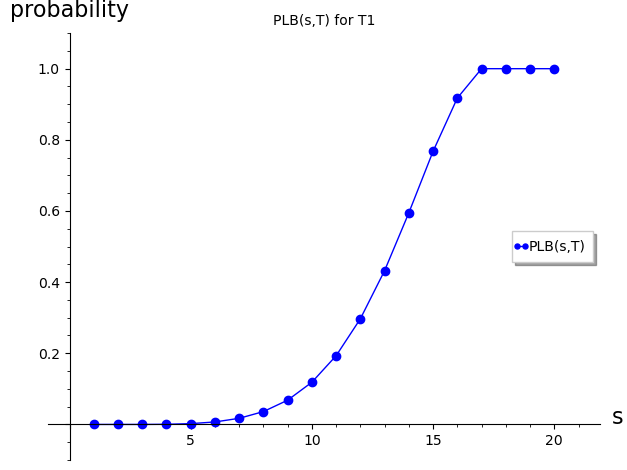

In [43]:
curve_T1 = PLB_curve(20,support_sizes(T1),s_min = 1,s_max = None)
print(curve_T1)
plot_T1 = list_plot(curve_T1, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T1')
show(plot_T1, legend_loc = 'center right',axes_pad =0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


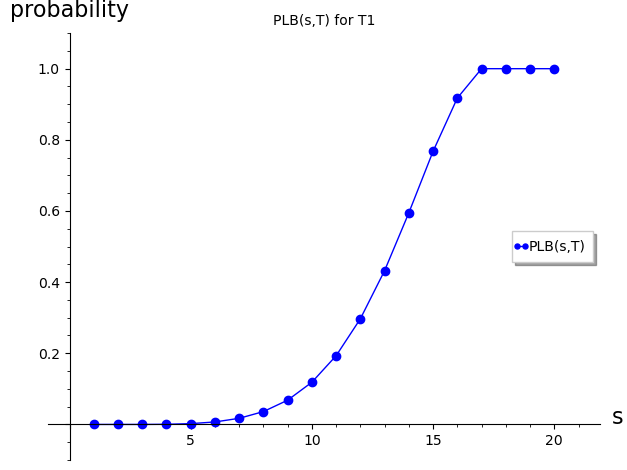

In [44]:
curve_T1_ori = PLB_curve(20,support_sizes(T1_ori),s_min = 1,s_max = None)
print(curve_T1_ori)
plot_T1_ori = list_plot(curve_T1_ori, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T1')
show(plot_T1_ori, legend_loc = 'center right',axes_pad =0.1)

## A better lower bound: using witness supports $W_i = \mathrm{supp}(\bm{\lambda}_{T_i})$

Suppose $\mathcal{T}_i = \{T_1,\dots,T_b\}$ is a set of certified planted supports. We have $\bm{\lambda}_{T_i}^\top (\mathbf{g})_{T_i} = 1$. Let
\begin{align}
    W_i &\stackrel{\text{def}}{=} \mathrm{supp}(\bm{\lambda}_{(T_i)})\\
    w_i &\stackrel{\text{def}}{=} |W_i| = wt_H(\bm{\lambda}_{T_i})
\end{align}
If $W_i \subseteq S$, then we can embed $\bm{\lambda}_{T_i}$ into a vector $\bm{\lambda}_S\in \mathbb{Z}^{|S|}$ by placing non-zero entries on the coordinates of $W_i \subseteq S$ and zeros elsewhere. We have $\bm{\lambda}_S \in \ker_\mathbb{Z}(\mathbf{H}_{(S)})$. Since $\bm{\lambda}[j] = 0$ for $j \notin W_i$, we have $\bm{\lambda}_S^\top (\mathbf{g})_{S} = \bm{\lambda}_{T_i}^\top (\mathbf{g})_{T_i} = 1$. This makes $W_i \subseteq S \Rightarrow \mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$.

Since $T_i$ for $i \in [1,b]$ are disjoint and $W_i \subseteq T_i$, $W_i$ for $i \in [1,b]$ are also disjoint, we have $\Pr[W_i \subseteq S] \geq \Pr[T_i \subseteq S]$ for random $S\subseteq [1,n]$. For $n \in \mathbb{Z}^+$, $s \in [1,n]$, and a collection of disjoint sets $\mathcal{W} = \{W_1,\dots,W_b\}$ where $W_i = \mathrm{supp}(\bm{\lambda}_{T_i})$, we define
\begin{align}
    \Pr_{witness}(s,\mathcal{W}) \stackrel{\text{def}}{=} \frac{1}{\binom{n}{s}}\cdot\sum_{\emptyset \neq J \subseteq [1,b]} (-1)^{|J| + 1} \cdot \binom{n-\sum_{i \in J}w_i}{s-\sum_{i\in J} w_i},
\end{align}
where $w_i = |W_i|$ for $i \in [1,b]$. We have $\Pr_{witness}(s,\mathcal{W}) \geq \Pr_{LB}(s,\mathcal{T})$.

We first consider the following helper function to get the list of $w_i$ from the list of $\bm{\lambda_{T_i}}$.

In [45]:
# list of hamming weight
def hamming_weight_list(List_of_v):
    return [hamming_weight(v) for v in List_of_v]

# finding the witness_size
def witness_sizes(Lambdas):
    return hamming_weight_list(Lambdas)

In [46]:
show(lambdas1)
show(witness_sizes(lambdas1))

[(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)]

[4, 4, 4, 4]

PWitness(n,s,witness_sizes)

In [47]:
def PWitness(n, s, witness_sizes):
    """
    Exact Pr_witness(s,{W1,...,Wb}) using inclusion-exclusion.
    witness_sizes = [w1,...,wb], disjoint supports.
    """
    b = len(witness_sizes)
    denom = binomial(n, s)
    total = ZZ(0)

    # Iterate over nonempty subsets J via bitmasks
    for mask in range(1, 1 << b):
        u = 0
        bits = 0
        for i in range(b):
            if (mask >> i) & 1:
                u += witness_sizes[i]
                bits += 1
        if u > s:
            continue

        term = binomial(n - u, s - u)
        if bits % 2 == 1:
            total += term
        else:
            total -= term

    return float(total / denom)

Constructing the curve for $\Pr_{witness}(s,\mathcal{W})$ for a given $\mathcal{W}$ and $1\leq s \leq n$. 

In [48]:
def PWitness_curve(n, witness_sizes, s_min=1, s_max=None):
    """
    Return the PWitness curve as a list of pairs [(s, PWitness(n,s,witness_sizes)), ...].

    Parameters
    ----------
    n : int
        Total number of indices.
    witness_sizes : list of int
        witness_sizes = [w1,...,wb] associated with disjoint supports.
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    -------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = int(n)
    witness_sizes = list(witness_sizes)

    if s_max is None:
        s_max = n

    s_min = int(s_min)
    s_max = int(s_max)

    # Clamp the range safely
    if s_min < 0:
        s_min = 0
    if s_max > n:
        s_max = n

    curve = []
    for s in range(s_min, s_max + 1):
        curve.append((s, PWitness(n, s, witness_sizes)))
    return curve

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


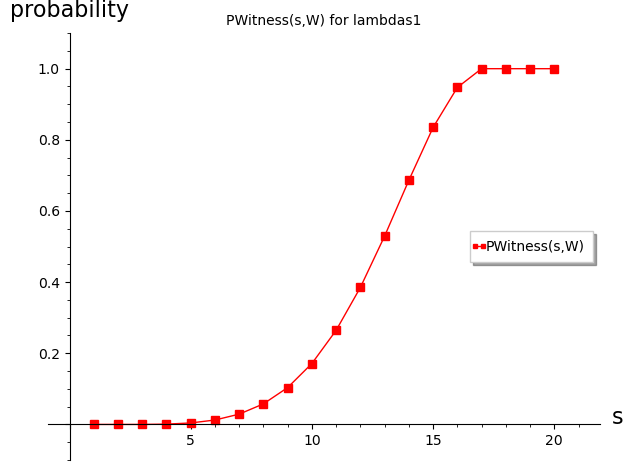

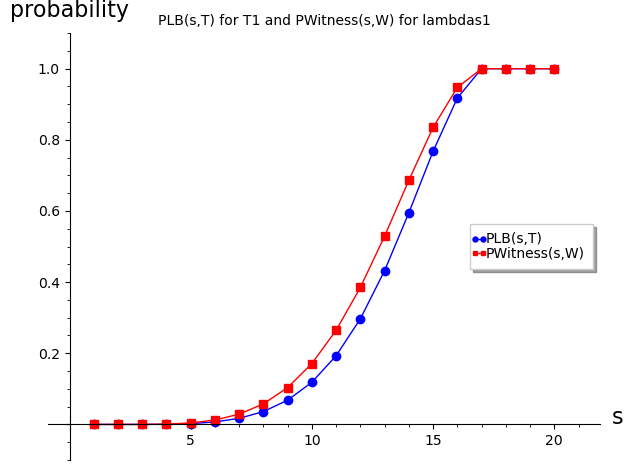

In [49]:
curve_lambdas1 = PWitness_curve(20,witness_sizes(lambdas1),s_min = 1,s_max = None)
print(curve_lambdas1)
plot_lambdas1 = list_plot(curve_lambdas1, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas1')
show(plot_lambdas1, legend_loc = 'center right', axes_pad=0.1)
show(plot_T1+plot_lambdas1,axes_labels = ['s','probability'],title='PLB(s,T) for T1 and PWitness(s,W) for lambdas1',legend_loc = 'center right', axes_pad = 0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


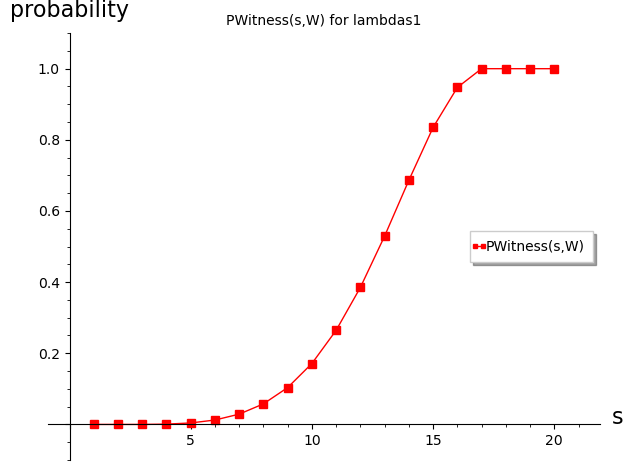

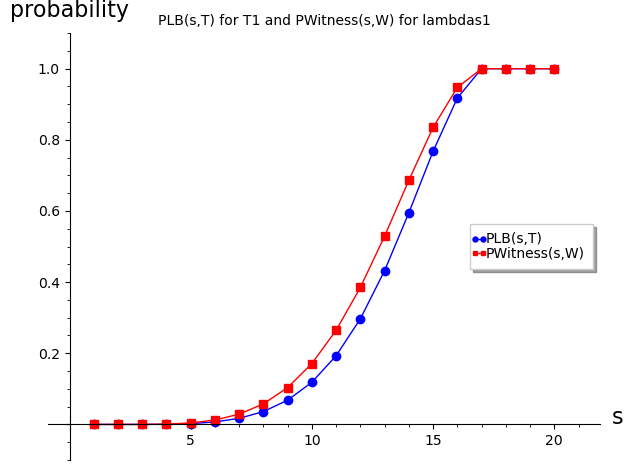

In [50]:
curve_lambdas1_ori = PWitness_curve(20,witness_sizes(lambdas1_ori),s_min = 1,s_max = None)
print(curve_lambdas1_ori)
plot_lambdas1_ori = list_plot(curve_lambdas1_ori, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas1')
show(plot_lambdas1_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T1_ori+plot_lambdas1_ori,axes_labels = ['s','probability'],title='PLB(s,T) for T1 and PWitness(s,W) for lambdas1',legend_loc = 'center right', axes_pad = 0.1)

## Actual lower bound based on experiment

Recall that a scheme is $\epsilon(n)$-correct with correctness threshold $k_c \in [1,n]$ if for every $T \subseteq [1,n]$ with $|T| \geq k_c$, we have $\Pr_{\mathbf{G}\gets\mathcal{D}_\mathbf{G}}[\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_T)] \geq 1-\epsilon(n)$.

We define the function **check_span(G)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{s \times k}$ as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$.

Suppose $\mathbf{G} \in \mathbb{Z}^{s \times k}$ and $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$. This means $\mathbf{e}_1^\top$ can be obtained using integer elementary row operations on $\mathbf{G}$. If $\mathbf{R}_\mathbf{G} \in \mathbb{Z}^{s \times k}$ is the row-HNF of $\mathbf{G}$, then it is unique lower triangular matrix such that $\mathbf{R}_\mathbf{G} = \mathbf{U}_\mathbf{G} \mathbf{G}$ for some $\mathbf{U}_\mathbf{G} \in GL_{|S|}(\mathbb{Z})$. By the row-HNF pivot/remainder condition, if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$, we must have $\mathbf{R}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$ (i.e., the first row of $\mathbf{R}_\mathbf{G}$ ($1$-based indexing) is $\mathbf{e}_1^\top$. In short: $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}) \Leftrightarrow \mathbf{R}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$.

We define the function **check_span_S(G,S)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $S \subseteq [0,n-1]$ ($0$-based-index) as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$.

In [51]:
def check_span(G):
    """
    Returns True if e_1^T is in the integer row span of G, by checking if the first row of the row HNF of G is e_1^T.
    """
    # If there are no rows, row span is {0}
    if G.nrows() == 0:
        return False

    k = G.ncols()
    e1 = vector(ZZ, [1] + [0] * (k - 1))

    R = G.hermite_form() # unique row HNF of G

    # If HNF has no rows (rare edge case), fail safely
    if R.nrows() == 0:
        return False

    return R[0] == e1 # check if first row is e_1^T

def check_span_S(G, S):
    """
    Return True iff e_1^T is in the integer row span of G_S,
    where G_S is the submatrix consisting of rows of G indexed by S.

    Assumes:
      - indices in S are 0-based and lie in {0,...,n-1}.
    """
    # If S is empty, then G_S has no rows, so its row span is {0}
    if len(S) == 0:
        return False

    # quick reject: if first column is all zeros on S, cannot reach e1
    has_nonzero_col0 = False
    for i in S:
        if G[i, 0] != 0:
            has_nonzero_col0 = True
            break
    if not has_nonzero_col0:
        return False

    G_S = G.matrix_from_rows(S)
    return check_span(G_S)

We define $\Pr_{actual}(s,\mathbf{G})$ for a fixed matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $s \in [1,n]$ as
\begin{align}
    \Pr_{actual}(s,\mathbf{G}) &\stackrel{\text{def}}{=} \frac{|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)\right)\}|}{|\{S\subseteq [1,n]: \left(|S| = s\right)\}|}\\
    &= \frac{1}{\binom{n}{s}}|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)\right)\}|
\end{align}

In [52]:
from itertools import combinations
from sage.all import binomial, QQ

def Pactual(s, G):
    """
    Exact Pr_actual(s, G) by enumerating all subsets S of size s.
    Works for small n (e.g., n=20).
    Returns an exact rational in QQ.
    """
    n = G.nrows()
    total = binomial(n, s)
    if total == 0:
        return QQ(0)

    good = 0
    for S in combinations(range(n), s):
        if check_span_S(G, S):
            good += 1

    return QQ(good) / QQ(total)

Some test for **Pactual(s,G)**.

In [53]:
show(G1)
Pactual17 = Pactual(17,G1)
Pactual16 = Pactual(16,G1)
Pactual15 = Pactual(15,G1)
Pactual14 = Pactual(14,G1)
show("17","--",Pactual17,"--",1-Pactual17)
show("16","--",Pactual16,"--",1-Pactual16)
show("15","--",Pactual15,"--",1-Pactual15)
show("14","--",Pactual14,"--",1-Pactual14)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

'17' '--' 1 '--' 0

'16' '--' 4843/4845 '--' 2/4845

'15' '--' 1289/1292 '--' 3/1292

'14' '--' 38453/38760 '--' 307/38760

In [54]:
show(G1_ori)
Pactual17_ori = Pactual(17,G1_ori)
Pactual16_ori = Pactual(16,G1_ori)
Pactual15_ori = Pactual(15,G1_ori)
Pactual14_ori = Pactual(14,G1_ori)
show("17","--",Pactual17_ori,"--",1-Pactual17_ori)
show("16","--",Pactual16_ori,"--",1-Pactual16_ori)
show("15","--",Pactual15_ori,"--",1-Pactual15_ori)
show("14","--",Pactual14_ori,"--",1-Pactual14_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

'17' '--' 1 '--' 0

'16' '--' 4843/4845 '--' 2/4845

'15' '--' 1289/1292 '--' 3/1292

'14' '--' 38453/38760 '--' 307/38760

Constructing the curve for $\Pr_{actual}(s,\mathbf{G})$ for a given $\mathbf{G}$ and $1\leq s\leq n$. 

In [55]:
def Pactual_curve(G, s_min=1, s_max=None):
    """
    Return the Pactual curve as a list of pairs [(s, Pactual(s,G)) for s in [s_min..s_max]] exactly (small n only).

    Parameters
    -----------
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    --------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = G.nrows()
    if s_max is None:
        s_max = n
    return [(s, Pactual(s, G)) for s in range(s_min, s_max + 1)]

In [56]:
%%time
show(G1)
curve_actual_G1 = [(s, float(p)) for (s,p) in Pactual_curve(G1, s_min = 1, s_max = None)]
print(curve_actual_G1)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006191950464396285), (5, 0.030959752321981424), (6, 0.09414344685242518), (7, 0.21852425180598556), (8, 0.411709137096134), (9, 0.6322457728030484), (10, 0.7953625322046375), (11, 0.8951655155989521), (12, 0.9503929507025483), (13, 0.9787151702786377), (14, 0.9920794633642931), (15, 0.9976780185758514), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 38.7 s, sys: 0 ns, total: 38.7 s
Wall time: 38.7 s


In [57]:
%%time
show(G1_ori)
curve_actual_G1_ori = [(s, float(p)) for (s,p) in Pactual_curve(G1, s_min = 1, s_max = None)]
print(curve_actual_G1_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006191950464396285), (5, 0.030959752321981424), (6, 0.09414344685242518), (7, 0.21852425180598556), (8, 0.411709137096134), (9, 0.6322457728030484), (10, 0.7953625322046375), (11, 0.8951655155989521), (12, 0.9503929507025483), (13, 0.9787151702786377), (14, 0.9920794633642931), (15, 0.9976780185758514), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 42.5 s, sys: 0 ns, total: 42.5 s
Wall time: 42.5 s


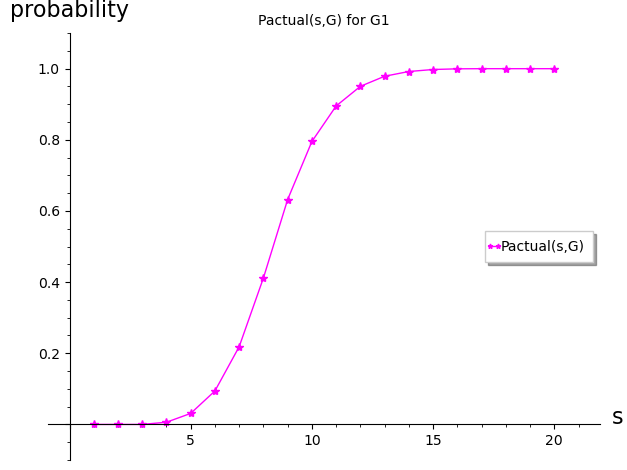

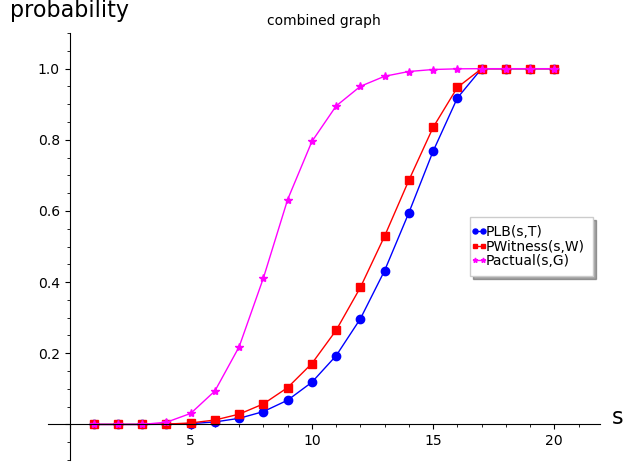

In [58]:
plot_G1 = list_plot(curve_actual_G1, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G1')
show(plot_G1, legend_loc = 'center right', axes_pad=0.1)
show(plot_T1+plot_lambdas1+plot_G1, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

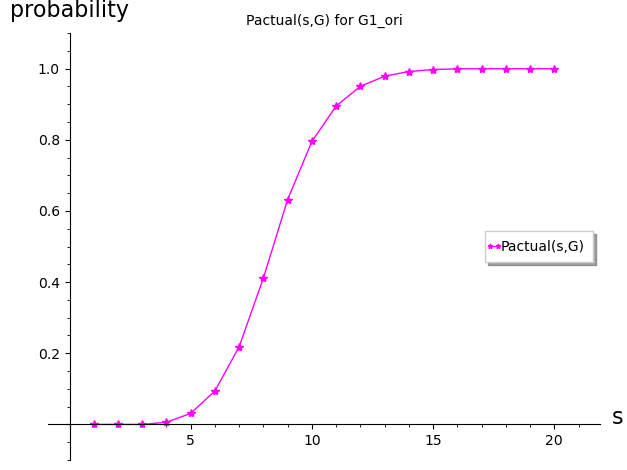

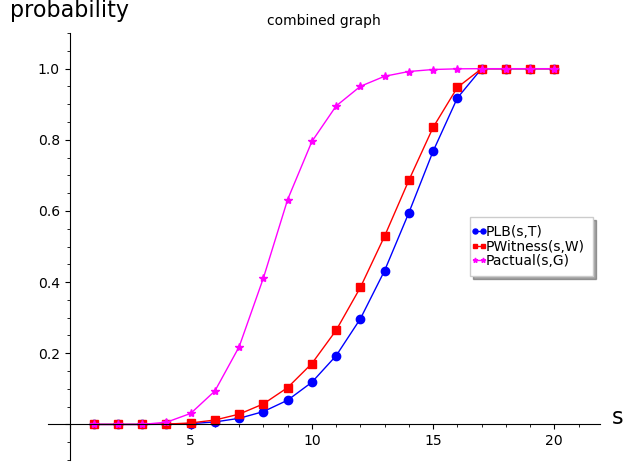

In [59]:
plot_G1_ori = list_plot(curve_actual_G1_ori, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G1_ori')
show(plot_G1_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T1_ori+plot_lambdas1+plot_G1_ori, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

Presenting using table.

In [60]:
print(curve_T1)
print(curve_lambdas1)
print(curve_actual_G1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006191950464396285), (5, 0.030959752321981424), (6, 0.09414344685242518), (7, 0.21852425180598556), (8, 0.411709137096134), (9

In [61]:
print(curve_T1_ori)
print(curve_lambdas1_ori)
print(curve_actual_G1_ori)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006191950464396285), (5, 0.030959752321981424), (6, 0.09414344685242518), (7, 0.21852425180598556), (8, 0.411709137096134), (9

In [62]:
import pandas as pd
def correctness(curve_T,curve_lambdas,curve_actual_G,n):
    '''
    creating a combined table of curve_T, curve_lambdas, and curve_actual_G
    the number is rounded to eight digit after decimal point
    '''
    # convert each list of pairs into a small dataframe
    df_curve_T = pd.DataFrame(curve_T, columns = ['t',' Pr_LB(t,T)'])
    df_curve_lambdas = pd.DataFrame(curve_lambdas, columns = ['t', 'Pr_Witness(t,W)'])
    df_curve_actual_G = pd.DataFrame(curve_actual_G, columns = ['t','Pr_actual(t,G)'])
    # merge on 't' using outer join to keep all t values
    df = df_curve_actual_G.merge(df_curve_lambdas, on = 't', how = 'outer').merge(df_curve_T, on = 't', how= 'outer')
    df = df.sort_values('t', ascending=False).reset_index(drop=True)
    caption = f"experiment for correctness and privacy threshold for n = {n}"
    display(df.style.set_caption(caption))

In [63]:
correctness(curve_T1,curve_lambdas1, curve_actual_G1, 20)

,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,20,1.000000,1.000000,1.000000
1,19,1.000000,1.000000,1.000000
2,18,1.000000,1.000000,1.000000
3,17,1.000000,1.000000,1.000000
4,16,0.999587,0.947162,0.917441
5,15,0.997678,0.834881,0.767802
6,14,0.992079,0.686275,0.594943
7,13,0.978715,0.529412,0.432405
8,12,0.950393,0.385123,0.296975
9,11,0.895166,0.264587,0.193141


In [64]:
correctness(curve_T1_ori,curve_lambdas1_ori, curve_actual_G1_ori, 20)

,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,20,1.000000,1.000000,1.000000
1,19,1.000000,1.000000,1.000000
2,18,1.000000,1.000000,1.000000
3,17,1.000000,1.000000,1.000000
4,16,0.999587,0.947162,0.917441
5,15,0.997678,0.834881,0.767802
6,14,0.992079,0.686275,0.594943
7,13,0.978715,0.529412,0.432405
8,12,0.950393,0.385123,0.296975
9,11,0.895166,0.264587,0.193141


# Smallness of the reconstruction vector $\bm{\lambda}_S$ for some $S \subseteq [1,n]$

Previously, we argue that for $n \in \mathbb{Z}^+$ and $S \subseteq [1,n]$, $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$ if and only if $\mathbf{R}_{\mathbf{G}_S}[1,\cdot] = \mathbf{e}_1^\top$ where $\mathbf{R}_{\mathbf{G}_S}$ is the row-HNF of $\mathbf{G}_S$, i.e., there exists $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbf{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$.

Notice that $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$ if and only if there exists $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ such that $\bm{\lambda}_S^\top \mathbf{G}_S = \mathbf{e}_1^\top$. One solution of $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ is $\bm{\lambda}_S = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ since we have $\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\mathbf{G}_S = (\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S)[1,\cdot] = \mathbf{R}_{\mathbf{G}_S} = \mathbf{e}_1^\top$.

In this part, we are intested to experimentally determine:
1. $\|\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\|_\infty$,
2. $wt_H(\mathbf{U}_{\mathbf{G}_S}[1,\cdot])$.

The following **check_smallness(G)** for a matrix $\mathbf{G}\in \mathbb{Z}^{s \times k}$ does the following:
1. Determine the row HNF of $\mathbf{G}$, i.e., $\mathbf{R}_\mathbf{G}$, and $\mathbf{U}_\mathbf{G} \in GL_s(\mathbb{Z})$ such that $\mathbf{U}_\mathbf{G}\mathbf{G} = \mathbf{R}_\mathbf{G}$.
2. Define $\bm{\lambda} = \mathbf{U}_\mathbf{G}[1,\cdot]$.
3. Compute $\|\bm{\lambda}\|_\infty = \max\{|\bm{\lambda}[i]: i \in [1,s]\}$ and $wt_H(\mathbf{\bm{\lambda}})=|\{i \in [1,s]: \bm{\lambda}[i] \neq 0\}|$.

The following **check_smallness_S(G,S)** for a matrix $\mathbf{G}_S \in \mathbb{Z}^{s \times k}$ and $S \subseteq [1,n]$ call **check_smallness(G_S)** for a submatrix $\mathbf{G}_S$.

In [65]:
def check_smallness(G):
    # determining ||U_G.row(0)||_infty and wt_H(U_G.row(0))
    if G.nrows() == 0:
        return (0, 0)
    R, U = G.hermite_form(transformation=True)
    lam = U[0,:]
    lam_entries = lam.list()
    
    linf = max(abs(x) for x in lam.list())
    # linf = max(abs(x) for x in lam) # buggy
    wt = sum(1 for x in lam.list() if x != 0)
    # wt = sum(1 for x in lam if x!= 0) # buggy
        
    return (linf, wt)


def check_smallness_S(G, S):
    # determining |||U_G_S[0,:]|_infty and wt_H(U_G_S[0,:])
    if len(S) == 0:
        return (0, 0)

    G_S = G.matrix_from_rows(S)
    return check_smallness(G_S)

For a fixed $s \in [1,n]$, we want to know:
1. the maximum of $\|\mathbf{U}_{\mathbf{G}_S}[1,\cdot]\|_\infty$ where $S \subseteq [1,n]$ and $|S| = s$,
2. the maximum of $wt_H(\mathbf{U}_{\mathbf{G}_S}[1,\cdot])$ where $S \subseteq [1,n]$ and $|S| = s$.

We write the function **stats_smallness(s,G)** that returns a pair of these quantities.

In [66]:
from itertools import combinations

def stats_smallness(s,G):
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n
    linf_max = 0
    wt_max = 0
    for S in combinations(range(n),s):
        (linf,wt) = check_smallness_S(G,S)
        if linf > linf_max:
            linf_max = linf
        if wt > wt_max:
            wt_max = wt
    return (linf_max,wt_max)

Constructing the curve for $stats\_smallness(s,G)$ for a given $\mathbf{G}$ and $1\leq s\leq n$. 

In [67]:
def stats_smallness_curve(G, s_min=1, s_max=None):
    """
    Return a list of triples:
        [(s, max_linf, max_wt) for s in [s_min..s_max]]

    where:
      - max_linf = max_{|S|=s} ||U_{G_S}[0,:]||_infty
      - max_wt   = max_{|S|=s} wt_H(U_{G_S}[0,:])
      - S ranges over subsets of {0,...,n-1} (0-based) with |S|=s
      - U_{G_S} * G_S = R_{G_S} is the row-HNF with transformation.

    This calls stats_smallness(s, G) exactly once per s.
    """
    n = G.nrows()

    if s_max is None:
        s_max = n

    s_min = int(s_min)
    s_max = int(s_max)

    # Clamp to valid range
    if s_min < 1:
        s_min = 1
    if s_max > n:
        s_max = n
    if s_min > s_max:
        return []

    out = []
    for s in range(s_min, s_max + 1):
        linf_max, wt_max = stats_smallness(s, G)
        out.append((s, linf_max, wt_max))
    return out

In [68]:
%%time
curve_smallness_G1 = stats_smallness_curve(G1, s_min = 1, s_max = None)
print(curve_smallness_G1)

[(1, 1, 1), (2, 1, 2), (3, 1, 3), (4, 1, 4), (5, 1, 5), (6, 2, 6), (7, 2, 7), (8, 2, 8), (9, 2, 9), (10, 2, 10), (11, 2, 10), (12, 2, 10), (13, 2, 10), (14, 2, 10), (15, 1, 6), (16, 1, 6), (17, 1, 6), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 28.7 s, sys: 3.96 ms, total: 28.7 s
Wall time: 28.7 s


In [69]:
%%time
curve_smallness_G1_ori = stats_smallness_curve(G1_ori, s_min = 1, s_max = None)
print(curve_smallness_G1_ori)

[(1, 1, 1), (2, 1, 2), (3, 1, 3), (4, 1, 4), (5, 1, 5), (6, 1, 6), (7, 1, 7), (8, 1, 8), (9, 1, 8), (10, 1, 10), (11, 1, 10), (12, 1, 10), (13, 1, 10), (14, 1, 10), (15, 1, 6), (16, 1, 6), (17, 1, 6), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 29.2 s, sys: 69 μs, total: 29.2 s
Wall time: 29.2 s


Presenting using table.

In [70]:
import pandas as pd

def smallness(curve_smallness_G,n):
    df = pd.DataFrame(curve_smallness_G, columns =['t', 'infinity norm bound', 'Hamming weight'])
    df = df.sort_values('t', ascending=False).reset_index(drop=True)
    caption = f"experiment for smallness and sparsity for n = {n}"
    display(df.style.set_caption(caption))

In [71]:
R1, U1 = G1.hermite_form(transformation=True)
show(U1,R1,G1)
R1_ori, U1_ori = G1_ori.hermite_form(transformation=True)
show(U1_ori,R1_ori,G1_ori)

20 x 20 dense matrix over Integer Ring (use the '.str()' method to see the entries) 20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries) 20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

20 x 20 dense matrix over Integer Ring (use the '.str()' method to see the entries) 20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries) 20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

In [72]:
smallness(curve_smallness_G1,20)

,t,infinity norm bound,Hamming weight
0,20,1,4
1,19,1,4
2,18,1,4
3,17,1,6
4,16,1,6
5,15,1,6
6,14,2,10
7,13,2,10
8,12,2,10
9,11,2,10


In [73]:
smallness(curve_smallness_G1_ori,20)

,t,infinity norm bound,Hamming weight
0,20,1,4
1,19,1,4
2,18,1,4
3,17,1,6
4,16,1,6
5,15,1,6
6,14,1,10
7,13,1,10
8,12,1,10
9,11,1,10


In [74]:
curve_smallness_G1_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G1]
curve_smallness_G1_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G1]
print(curve_smallness_G1_infty_norm)
print(curve_smallness_G1_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 10), (12, 10), (13, 10), (14, 10), (15, 6), (16, 6), (17, 6), (18, 4), (19, 4), (20, 4)]


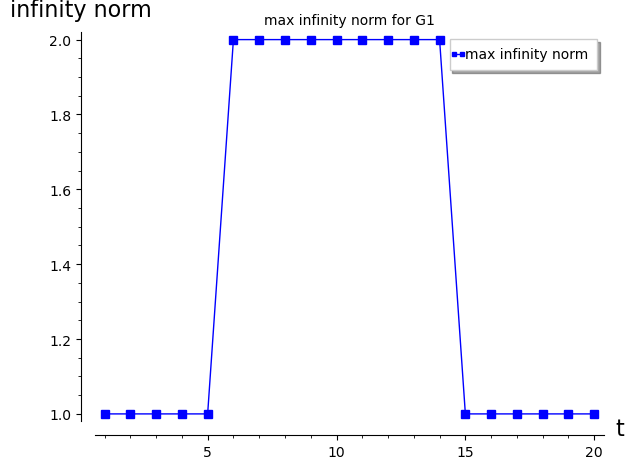

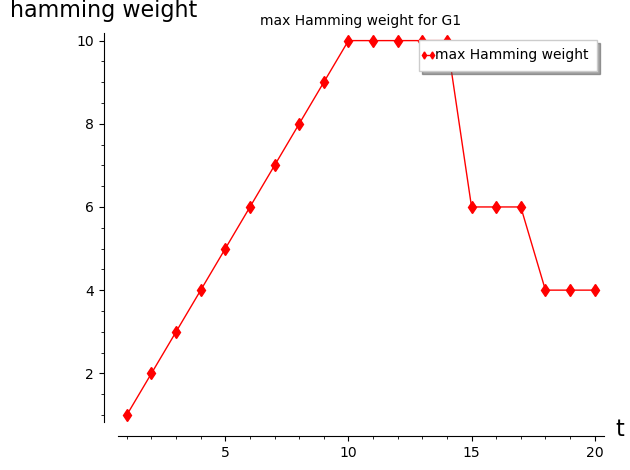

In [75]:
plot_G1_infty_norm = list_plot(curve_smallness_G1_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G1')
show(plot_G1_infty_norm, legend_loc = 'upper right')
plot_G1_hamming_weight = list_plot(curve_smallness_G1_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G1')
show(plot_G1_hamming_weight,legend_loc = 'upper right')

In [76]:
curve_smallness_G1_ori_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G1_ori]
curve_smallness_G1_ori_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G1_ori]
print(curve_smallness_G1_ori_infty_norm)
print(curve_smallness_G1_ori_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 8), (10, 10), (11, 10), (12, 10), (13, 10), (14, 10), (15, 6), (16, 6), (17, 6), (18, 4), (19, 4), (20, 4)]


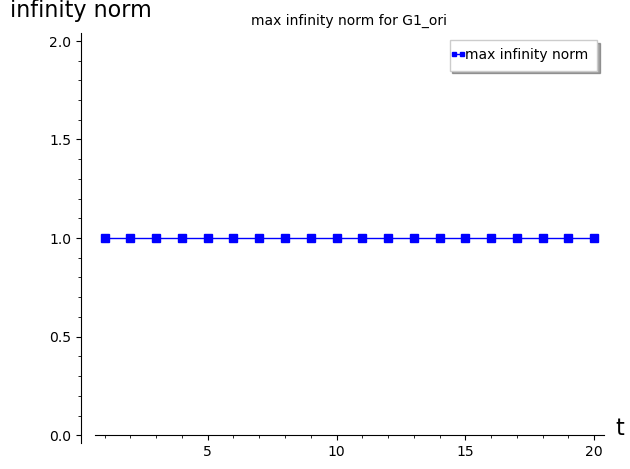

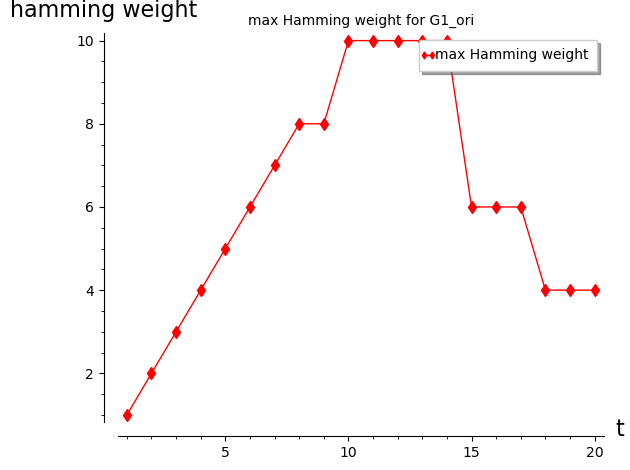

In [77]:
plot_G1_ori_infty_norm = list_plot(curve_smallness_G1_ori_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G1_ori')
show(plot_G1_ori_infty_norm, legend_loc = 'upper right')
plot_G1_ori_hamming_weight = list_plot(curve_smallness_G1_ori_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G1_ori')
show(plot_G1_ori_hamming_weight,legend_loc = 'upper right')

# Test for $\mathbf{G}_2$

The matrix $\mathbf{G}_2$

In [78]:
show(G2,G2_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries) 20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

## $\Pr_{LB}(s,\mathcal{T})$

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


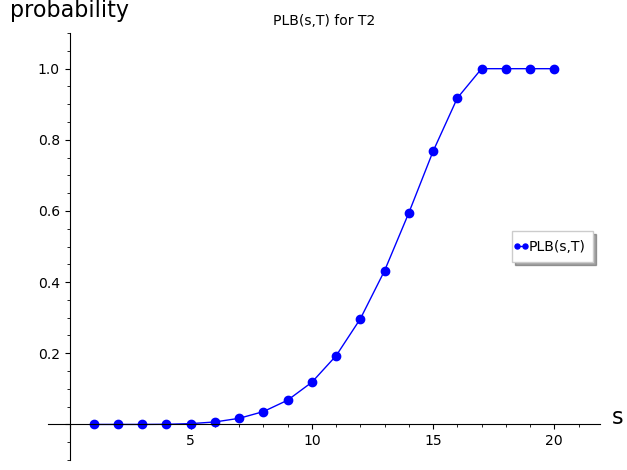

In [79]:
curve_T2 = PLB_curve(20,support_sizes(T2),s_min = 1,s_max = None)
print(curve_T2)
plot_T2 = list_plot(curve_T2, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T2')
show(plot_T2, legend_loc = 'center right',axes_pad =0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


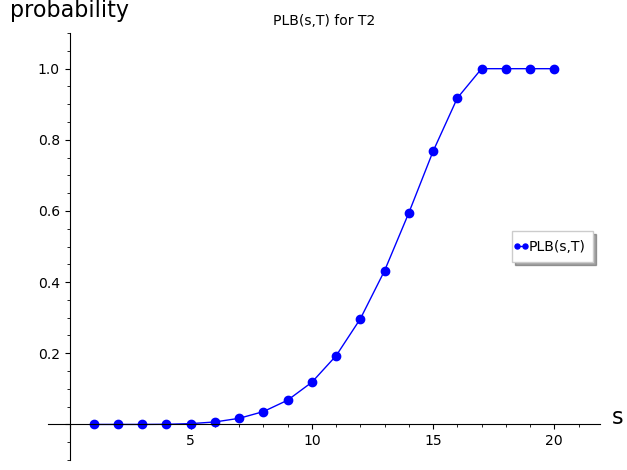

In [80]:
curve_T2_ori = PLB_curve(20,support_sizes(T2_ori),s_min = 1,s_max = None)
print(curve_T2_ori)
plot_T2_ori = list_plot(curve_T2_ori, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T2')
show(plot_T2_ori, legend_loc = 'center right',axes_pad =0.1)

## $\Pr_{Witness}(s,\mathcal{W})$

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


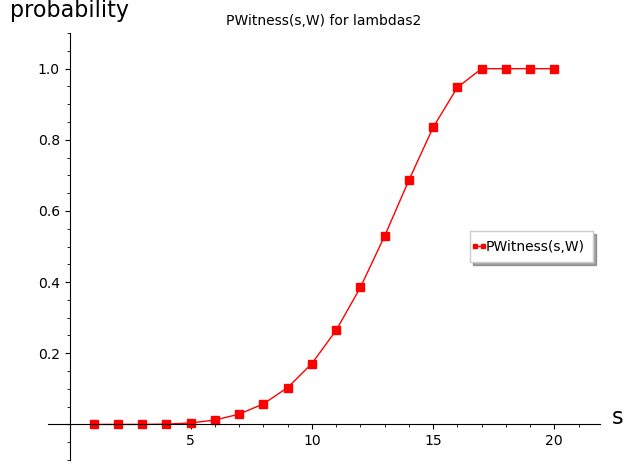

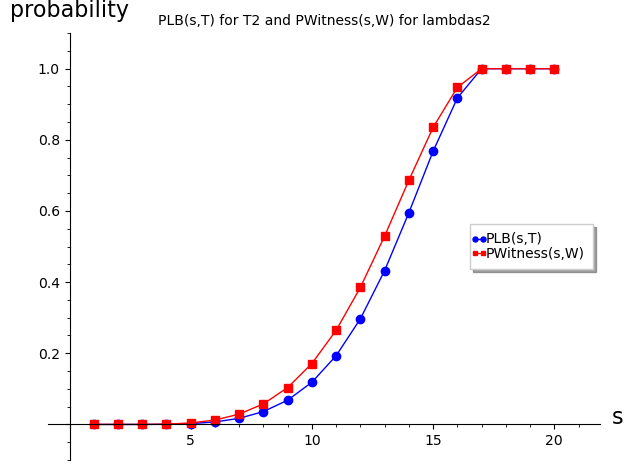

In [81]:
curve_lambdas2 = PWitness_curve(20,witness_sizes(lambdas2),s_min = 1,s_max = None)
print(curve_lambdas2)
plot_lambdas2 = list_plot(curve_lambdas2, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas2')
show(plot_lambdas2, legend_loc = 'center right', axes_pad=0.1)
show(plot_T2+plot_lambdas2,axes_labels = ['s','probability'],title='PLB(s,T) for T2 and PWitness(s,W) for lambdas2',legend_loc = 'center right', axes_pad = 0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


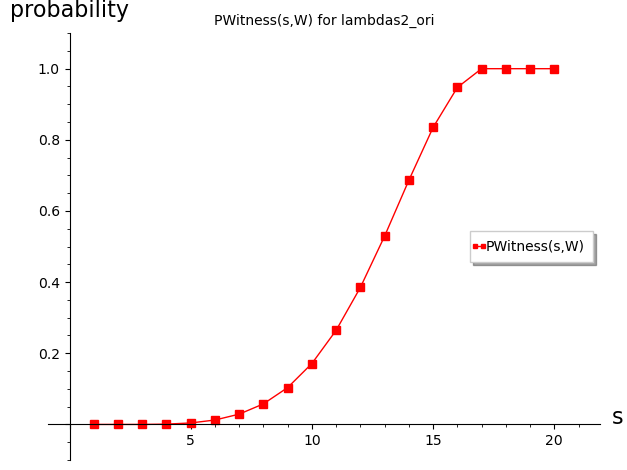

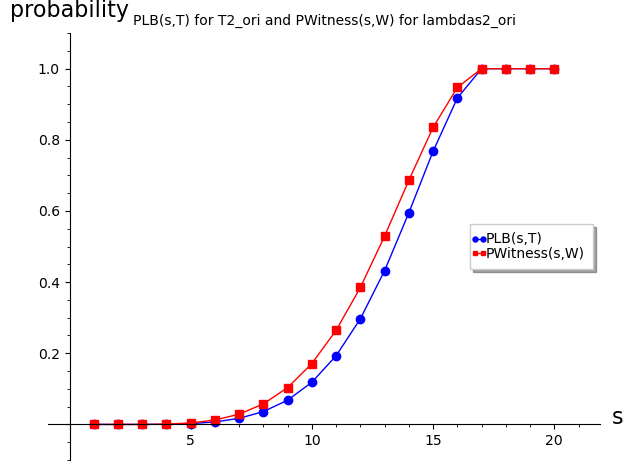

In [82]:
curve_lambdas2_ori = PWitness_curve(20,witness_sizes(lambdas2_ori),s_min = 1,s_max = None)
print(curve_lambdas2_ori)
plot_lambdas2_ori = list_plot(curve_lambdas2_ori, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas2_ori')
show(plot_lambdas2_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T2_ori+plot_lambdas2_ori,axes_labels = ['s','probability'],title='PLB(s,T) for T2_ori and PWitness(s,W) for lambdas2_ori',legend_loc = 'center right', axes_pad = 0.1)

## $\Pr_{actual}(s,\mathbf{G}_2)$

In [83]:
%%time
show(G2)
curve_actual_G2 = [(s, float(p)) for (s,p) in Pactual_curve(G2, s_min = 1, s_max = None)]
print(curve_actual_G2)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.005985552115583075), (5, 0.029927760577915376), (6, 0.09091847265221878), (7, 0.2109907120743034), (8, 0.39842025879177584), (9, 0.6165515598952132), (10, 0.7864318344194505), (11, 0.8913848535365563), (12, 0.9490751766293561), (13, 0.9783668730650155), (14, 0.9920278637770897), (15, 0.9976780185758514), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 40.9 s, sys: 7.97 ms, total: 40.9 s
Wall time: 40.9 s


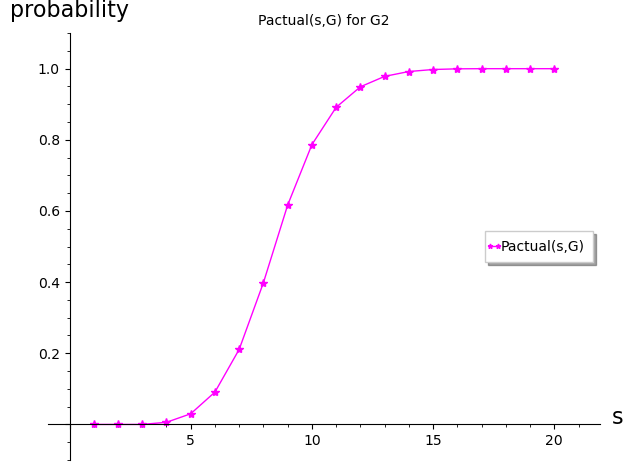

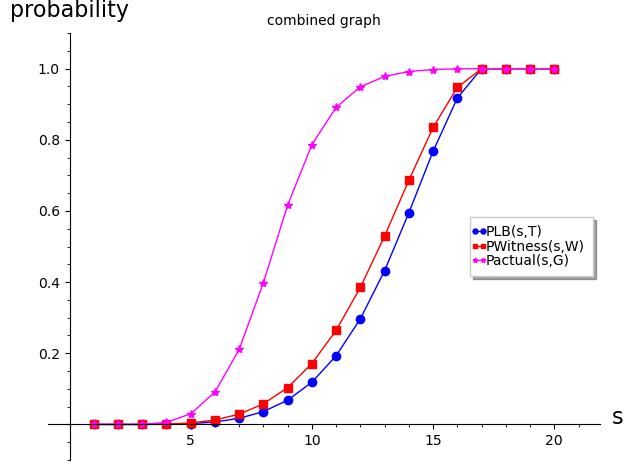

In [84]:
plot_G2 = list_plot(curve_actual_G2, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G2')
show(plot_G2, legend_loc = 'center right', axes_pad=0.1)
show(plot_T2+plot_lambdas2+plot_G2, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

In [85]:
%%time
show(G2_ori)
curve_actual_G2_ori = [(s, float(p)) for (s,p) in Pactual_curve(G2_ori, s_min = 1, s_max = None)]
print(curve_actual_G2_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.005985552115583075), (5, 0.029927760577915376), (6, 0.09091847265221878), (7, 0.2109907120743034), (8, 0.39842025879177584), (9, 0.6165515598952132), (10, 0.7864318344194505), (11, 0.8913848535365563), (12, 0.9490751766293561), (13, 0.9783668730650155), (14, 0.9920278637770897), (15, 0.9976780185758514), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 41.9 s, sys: 3.99 ms, total: 41.9 s
Wall time: 41.9 s


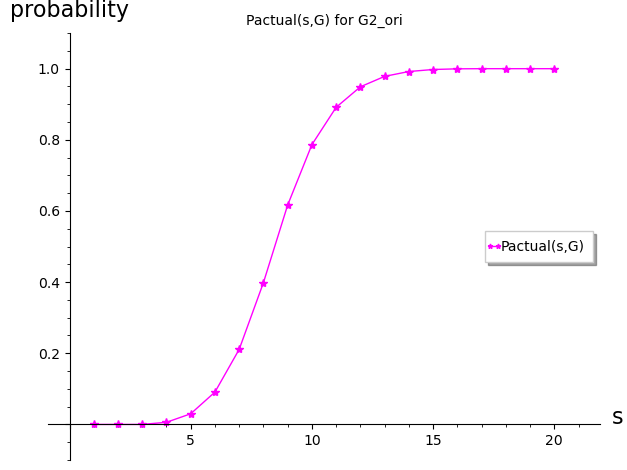

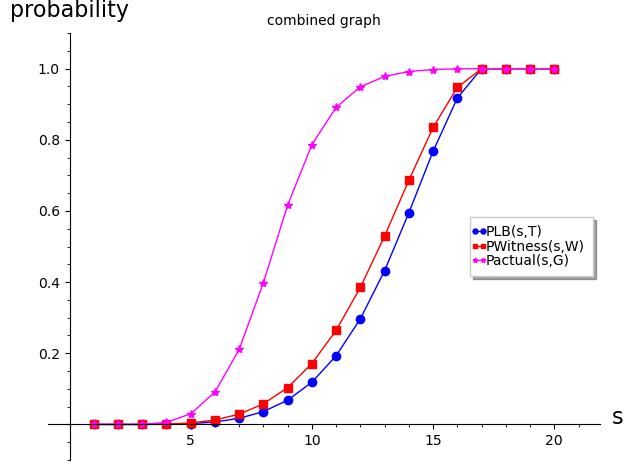

In [86]:
plot_G2_ori = list_plot(curve_actual_G2_ori, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G2_ori')
show(plot_G2_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T2_ori+plot_lambdas2_ori+plot_G2_ori, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

In [87]:
correctness(curve_T2,curve_lambdas2, curve_actual_G2, 20)
correctness(curve_T2_ori,curve_lambdas2_ori, curve_actual_G2_ori, 20)

,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,20,1.000000,1.000000,1.000000
1,19,1.000000,1.000000,1.000000
2,18,1.000000,1.000000,1.000000
3,17,1.000000,1.000000,1.000000
4,16,0.999587,0.947162,0.917441
5,15,0.997678,0.834881,0.767802
6,14,0.992028,0.686275,0.594943
7,13,0.978367,0.529412,0.432405
8,12,0.949075,0.385123,0.296975
9,11,0.891385,0.264587,0.193141


,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,20,1.000000,1.000000,1.000000
1,19,1.000000,1.000000,1.000000
2,18,1.000000,1.000000,1.000000
3,17,1.000000,1.000000,1.000000
4,16,0.999587,0.947162,0.917441
5,15,0.997678,0.834881,0.767802
6,14,0.992028,0.686275,0.594943
7,13,0.978367,0.529412,0.432405
8,12,0.949075,0.385123,0.296975
9,11,0.891385,0.264587,0.193141


## Smallness of the reconstruction vector $\bm{\lambda}_S$ for some $S \subseteq [1,n]$ for $\mathbf{G}_2$

In [88]:
%%time
curve_smallness_G2 = stats_smallness_curve(G2, s_min = 1, s_max = None)
print(curve_smallness_G2)

[(1, 1, 1), (2, 1, 2), (3, 1, 3), (4, 2, 4), (5, 2, 5), (6, 2, 6), (7, 2, 7), (8, 2, 8), (9, 2, 9), (10, 2, 10), (11, 2, 10), (12, 2, 10), (13, 2, 10), (14, 2, 10), (15, 2, 10), (16, 2, 8), (17, 2, 8), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 29.9 s, sys: 4 ms, total: 29.9 s
Wall time: 29.9 s


In [89]:
%%time
curve_smallness_G2_ori = stats_smallness_curve(G2_ori, s_min = 1, s_max = None)
print(curve_smallness_G2_ori)

[(1, 1, 1), (2, 1, 2), (3, 1, 3), (4, 2, 4), (5, 2, 5), (6, 2, 6), (7, 2, 7), (8, 2, 8), (9, 2, 9), (10, 2, 10), (11, 2, 10), (12, 2, 10), (13, 2, 10), (14, 2, 10), (15, 2, 10), (16, 2, 8), (17, 2, 8), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 30.1 s, sys: 0 ns, total: 30.1 s
Wall time: 30.1 s


Presenting using table.

In [90]:
smallness(curve_smallness_G2,20)
smallness(curve_smallness_G2_ori,20)

,t,infinity norm bound,Hamming weight
0,20,1,4
1,19,1,4
2,18,1,4
3,17,2,8
4,16,2,8
5,15,2,10
6,14,2,10
7,13,2,10
8,12,2,10
9,11,2,10


,t,infinity norm bound,Hamming weight
0,20,1,4
1,19,1,4
2,18,1,4
3,17,2,8
4,16,2,8
5,15,2,10
6,14,2,10
7,13,2,10
8,12,2,10
9,11,2,10


In [91]:
curve_smallness_G2_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G2]
curve_smallness_G2_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G2]
print(curve_smallness_G2_infty_norm)
print(curve_smallness_G2_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 2), (17, 2), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 10), (12, 10), (13, 10), (14, 10), (15, 10), (16, 8), (17, 8), (18, 4), (19, 4), (20, 4)]


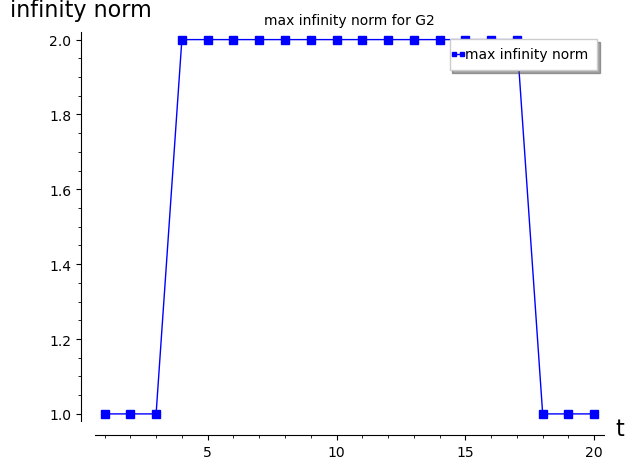

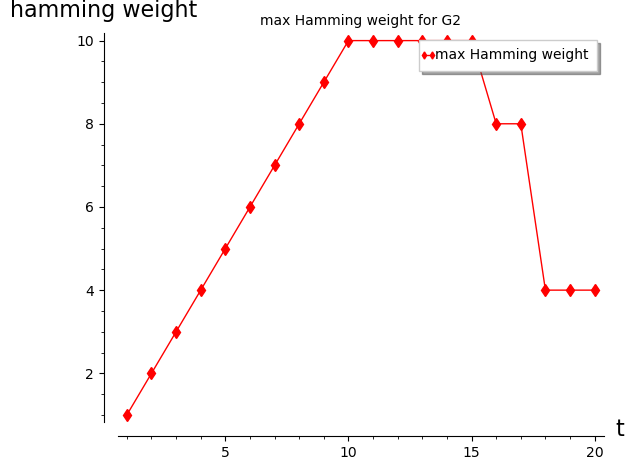

In [92]:
plot_G2_infty_norm = list_plot(curve_smallness_G2_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G2')
show(plot_G2_infty_norm, legend_loc = 'upper right')
plot_G2_hamming_weight = list_plot(curve_smallness_G2_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G2')
show(plot_G2_hamming_weight,legend_loc = 'upper right')

In [93]:
curve_smallness_G2_ori_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G2_ori]
curve_smallness_G2_ori_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G2_ori]
print(curve_smallness_G2_ori_infty_norm)
print(curve_smallness_G2_ori_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 2), (17, 2), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 10), (12, 10), (13, 10), (14, 10), (15, 10), (16, 8), (17, 8), (18, 4), (19, 4), (20, 4)]


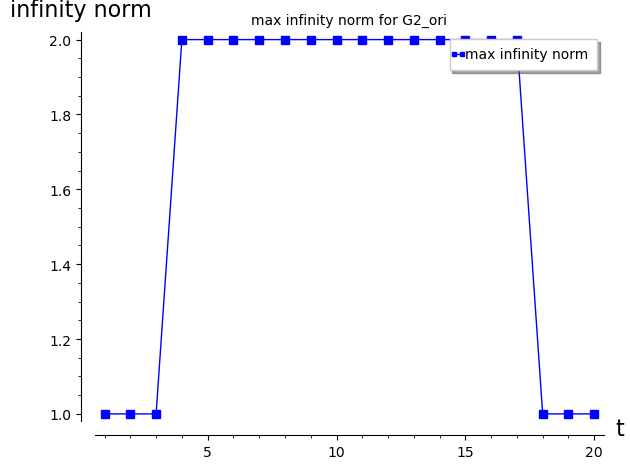

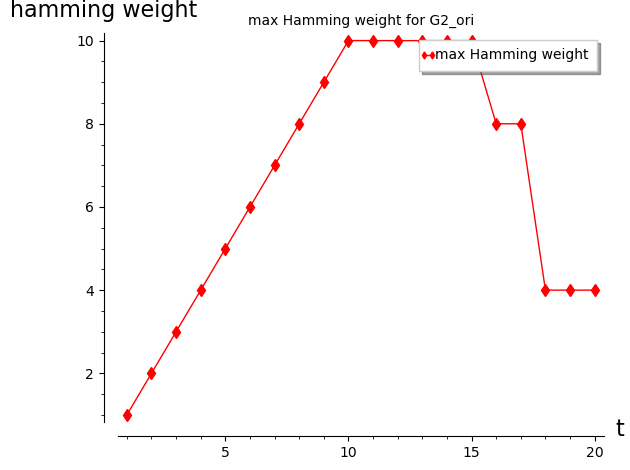

In [94]:
plot_G2_ori_infty_norm = list_plot(curve_smallness_G2_ori_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G2_ori')
show(plot_G2_ori_infty_norm, legend_loc = 'upper right')
plot_G2_ori_hamming_weight = list_plot(curve_smallness_G2_ori_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G2_ori')
show(plot_G2_ori_hamming_weight,legend_loc = 'upper right')

# Test for $\mathbf{G}_3$

The matrix $\mathbf{G}_3$

In [95]:
show(G3,G3_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries) 20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

## $\Pr_{LB}(s,\mathcal{T})$

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


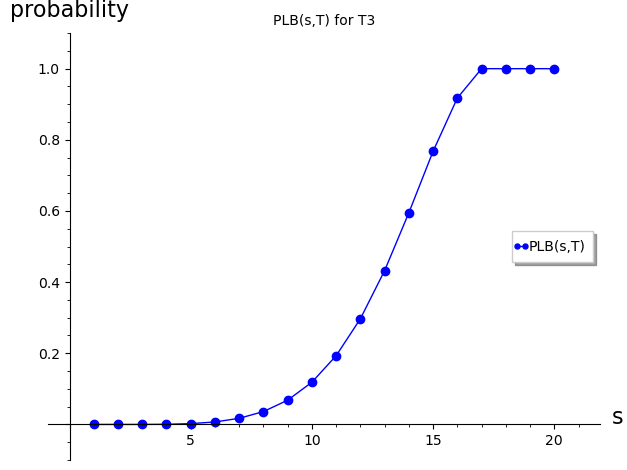

In [96]:
curve_T3 = PLB_curve(20,support_sizes(T3),s_min = 1,s_max = None)
print(curve_T3)
plot_T3 = list_plot(curve_T3, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T3')
show(plot_T3, legend_loc = 'center right',axes_pad =0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000412796697626419), (5, 0.0021929824561403508), (6, 0.00696594427244582), (7, 0.01715686274509804), (8, 0.036111772644280386), (9, 0.06817099309359372), (10, 0.11859425404317045), (11, 0.19314122410097642), (12, 0.29697547035008337), (13, 0.4324045407636739), (14, 0.5949432404540763), (15, 0.7678018575851393), (16, 0.9174406604747162), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


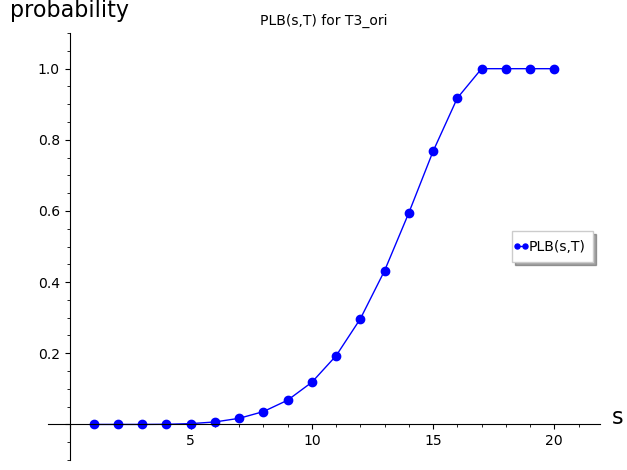

In [97]:
curve_T3_ori = PLB_curve(20,support_sizes(T3_ori),s_min = 1,s_max = None)
print(curve_T3_ori)
plot_T3_ori = list_plot(curve_T3_ori, plotjoined=True, marker='o', color='blue', legend_label= 'PLB(s,T)', axes_labels=['s','probability'], title='PLB(s,T) for T3_ori')
show(plot_T3_ori, legend_loc = 'center right',axes_pad =0.1)

## $\Pr_{Witness}(s,\mathcal{W})$

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


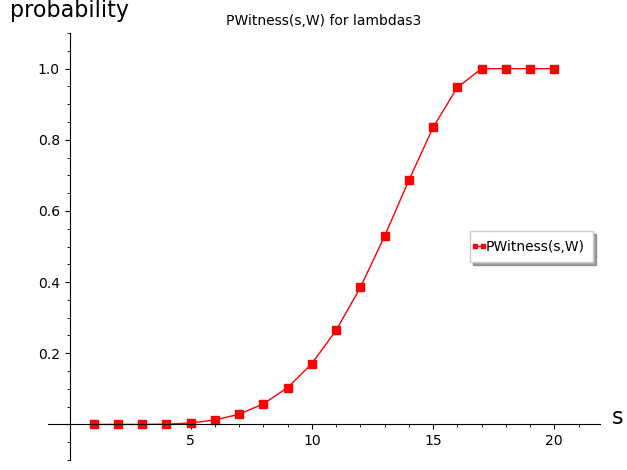

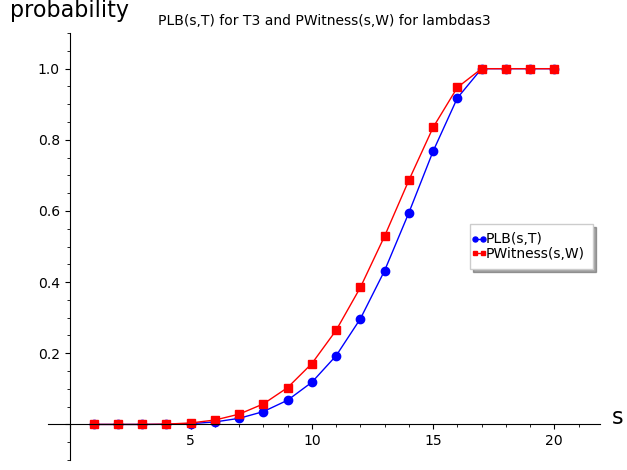

In [98]:
curve_lambdas3 = PWitness_curve(20,witness_sizes(lambdas3),s_min = 1,s_max = None)
print(curve_lambdas3)
plot_lambdas3 = list_plot(curve_lambdas3, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas3')
show(plot_lambdas3, legend_loc = 'center right', axes_pad=0.1)
show(plot_T3+plot_lambdas3,axes_labels = ['s','probability'],title='PLB(s,T) for T3 and PWitness(s,W) for lambdas3',legend_loc = 'center right', axes_pad = 0.1)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.000825593395252838), (5, 0.0041279669762641896), (6, 0.01238390092879257), (7, 0.02889576883384933), (8, 0.057743907279510995), (9, 0.10359609430816862), (10, 0.1712312455346511), (11, 0.264586806382472), (12, 0.38512344208938637), (13, 0.5294117647058824), (14, 0.6862745098039216), (15, 0.8348813209494325), (16, 0.9471620227038183), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


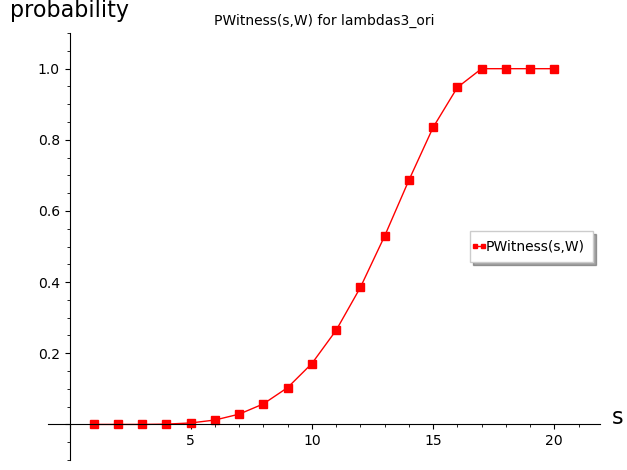

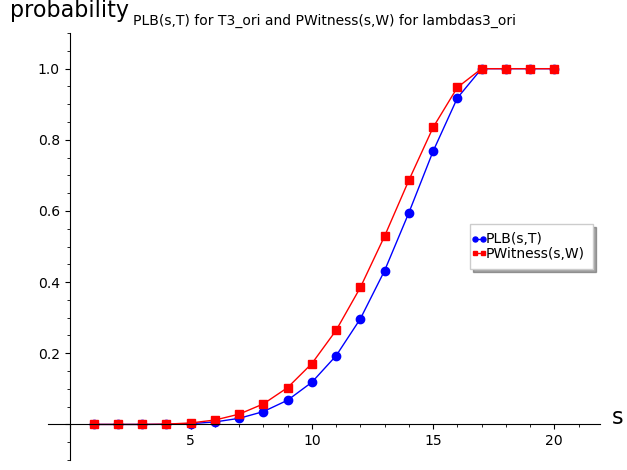

In [99]:
curve_lambdas3_ori = PWitness_curve(20,witness_sizes(lambdas3_ori),s_min = 1,s_max = None)
print(curve_lambdas3_ori)
plot_lambdas3_ori = list_plot(curve_lambdas3_ori, plotjoined=True, marker = 's',color='red', legend_label = 'PWitness(s,W)',axes_labels=['s','probability'], title='PWitness(s,W) for lambdas3_ori')
show(plot_lambdas3_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T3_ori+plot_lambdas3_ori,axes_labels = ['s','probability'],title='PLB(s,T) for T3_ori and PWitness(s,W) for lambdas3_ori',legend_loc = 'center right', axes_pad = 0.1)

## $\Pr_{actual}(s,\mathbf{G}_3)$

In [100]:
%%time
show(G3)
curve_actual_G3 = [(s, float(p)) for (s,p) in Pactual_curve(G3, s_min = 1, s_max = None)]
print(curve_actual_G3)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.007017543859649123), (5, 0.03508771929824561), (6, 0.10580495356037152), (7, 0.2422858617131063), (8, 0.4491386838136064), (9, 0.6790188140033341), (10, 0.8428900820541687), (11, 0.9328054298642534), (12, 0.9749622926093514), (13, 0.9921826625386997), (14, 0.9981424148606811), (15, 0.9997420020639834), (16, 1.0), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 41.5 s, sys: 0 ns, total: 41.5 s
Wall time: 41.4 s


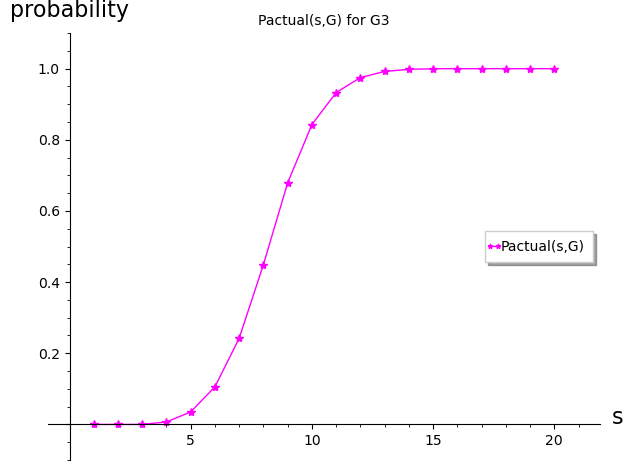

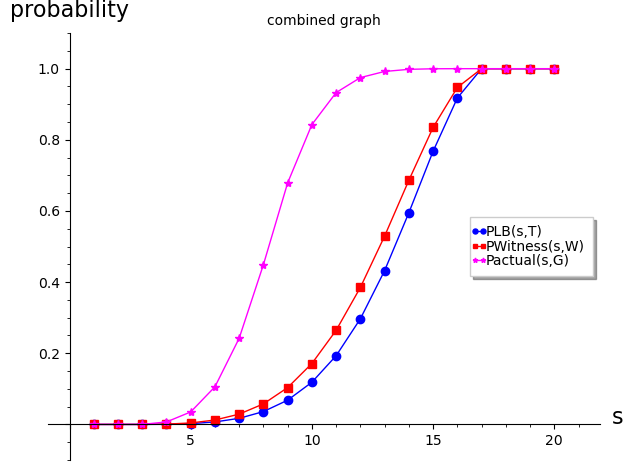

In [101]:
plot_G3 = list_plot(curve_actual_G3, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G3')
show(plot_G3, legend_loc = 'center right', axes_pad=0.1)
show(plot_T3+plot_lambdas3+plot_G3, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

In [102]:
%%time
show(G3_ori)
curve_actual_G3_ori = [(s, float(p)) for (s,p) in Pactual_curve(G3_ori, s_min = 1, s_max = None)]
print(curve_actual_G3_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.007017543859649123), (5, 0.03508771929824561), (6, 0.10580495356037152), (7, 0.2422858617131063), (8, 0.4491386838136064), (9, 0.6790188140033341), (10, 0.8428900820541687), (11, 0.9328054298642534), (12, 0.9749622926093514), (13, 0.9921826625386997), (14, 0.9981424148606811), (15, 0.9997420020639834), (16, 1.0), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 42.4 s, sys: 4 ms, total: 42.4 s
Wall time: 42.4 s


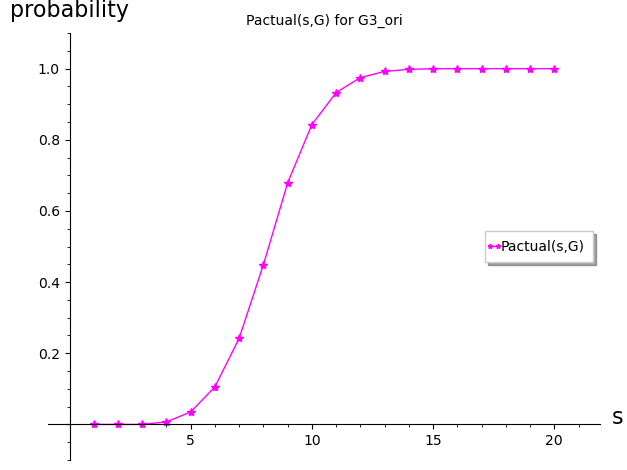

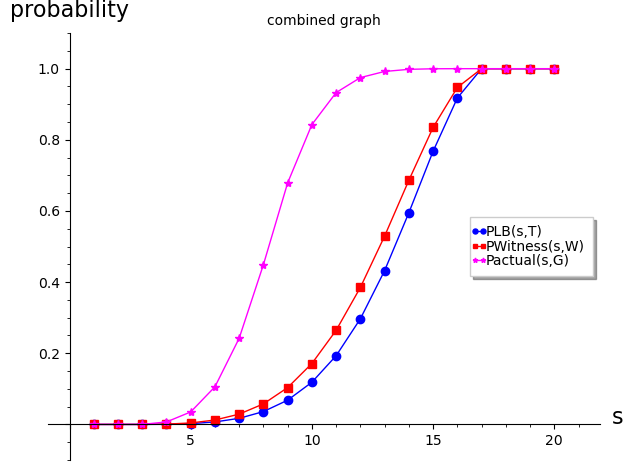

In [103]:
plot_G3_ori = list_plot(curve_actual_G3_ori, plotjoined=True, marker='*', color = 'magenta', legend_label = 'Pactual(s,G)',axes_labels=['s','probability'], title='Pactual(s,G) for G3_ori')
show(plot_G3_ori, legend_loc = 'center right', axes_pad=0.1)
show(plot_T3_ori+plot_lambdas3_ori+plot_G3_ori, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

In [104]:
correctness(curve_T3,curve_lambdas3, curve_actual_G3, 20)
correctness(curve_T3_ori,curve_lambdas3_ori, curve_actual_G3_ori, 20)

,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,20,1.000000,1.000000,1.000000
1,19,1.000000,1.000000,1.000000
2,18,1.000000,1.000000,1.000000
3,17,1.000000,1.000000,1.000000
4,16,1.000000,0.947162,0.917441
5,15,0.999742,0.834881,0.767802
6,14,0.998142,0.686275,0.594943
7,13,0.992183,0.529412,0.432405
8,12,0.974962,0.385123,0.296975
9,11,0.932805,0.264587,0.193141


,t,"Pr_actual(t,G)","Pr_Witness(t,W)","Pr_LB(t,T)"
0,20,1.000000,1.000000,1.000000
1,19,1.000000,1.000000,1.000000
2,18,1.000000,1.000000,1.000000
3,17,1.000000,1.000000,1.000000
4,16,1.000000,0.947162,0.917441
5,15,0.999742,0.834881,0.767802
6,14,0.998142,0.686275,0.594943
7,13,0.992183,0.529412,0.432405
8,12,0.974962,0.385123,0.296975
9,11,0.932805,0.264587,0.193141


## Smallness of the reconstruction vector $\bm{\lambda}_S$ for some $S \subseteq [1,n]$ for $\mathbf{G}_3$

In [105]:
%%time
curve_smallness_G3 = stats_smallness_curve(G3, s_min = 1, s_max = None)
print(curve_smallness_G3)

[(1, 1, 1), (2, 1, 2), (3, 1, 3), (4, 1, 4), (5, 2, 5), (6, 2, 6), (7, 2, 7), (8, 3, 8), (9, 3, 9), (10, 3, 10), (11, 2, 10), (12, 2, 10), (13, 2, 10), (14, 2, 10), (15, 2, 8), (16, 1, 8), (17, 1, 8), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 30 s, sys: 4 ms, total: 30 s
Wall time: 30 s


In [106]:
%%time
curve_smallness_G3_ori = stats_smallness_curve(G3_ori, s_min = 1, s_max = None)
print(curve_smallness_G3_ori)

[(1, 1, 1), (2, 1, 2), (3, 1, 3), (4, 1, 4), (5, 1, 5), (6, 1, 6), (7, 2, 7), (8, 2, 8), (9, 3, 9), (10, 3, 10), (11, 2, 10), (12, 2, 10), (13, 2, 10), (14, 2, 10), (15, 2, 8), (16, 1, 8), (17, 1, 8), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 29.8 s, sys: 0 ns, total: 29.8 s
Wall time: 29.8 s


Presenting using table.

In [107]:
smallness(curve_smallness_G3,20)
smallness(curve_smallness_G3_ori,20)

,t,infinity norm bound,Hamming weight
0,20,1,4
1,19,1,4
2,18,1,4
3,17,1,8
4,16,1,8
5,15,2,8
6,14,2,10
7,13,2,10
8,12,2,10
9,11,2,10


,t,infinity norm bound,Hamming weight
0,20,1,4
1,19,1,4
2,18,1,4
3,17,1,8
4,16,1,8
5,15,2,8
6,14,2,10
7,13,2,10
8,12,2,10
9,11,2,10


In [108]:
curve_smallness_G3_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G3]
curve_smallness_G3_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G3]
print(curve_smallness_G3_infty_norm)
print(curve_smallness_G3_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 2), (7, 2), (8, 3), (9, 3), (10, 3), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 10), (12, 10), (13, 10), (14, 10), (15, 8), (16, 8), (17, 8), (18, 4), (19, 4), (20, 4)]


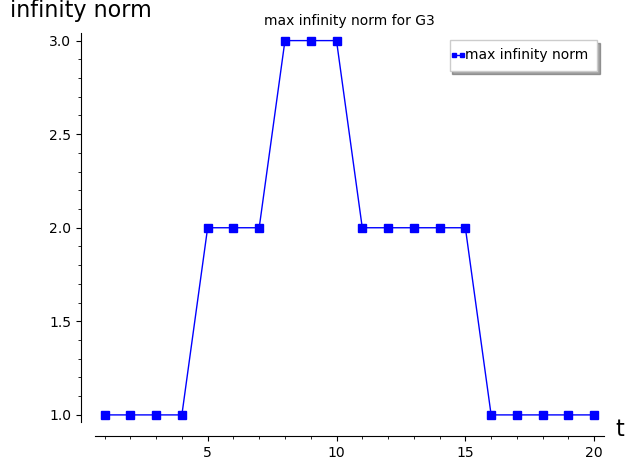

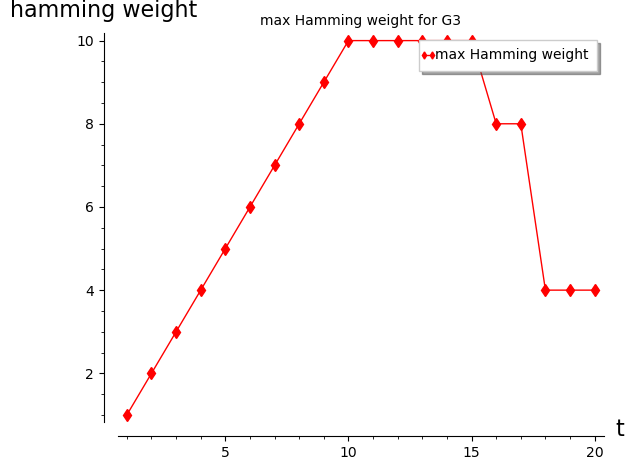

In [109]:
plot_G3_infty_norm = list_plot(curve_smallness_G3_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G3')
show(plot_G3_infty_norm, legend_loc = 'upper right')
plot_G3_hamming_weight = list_plot(curve_smallness_G2_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G3')
show(plot_G3_hamming_weight,legend_loc = 'upper right')

In [110]:
curve_smallness_G3_ori_infty_norm = [(s,linf) for (s, linf, wt) in curve_smallness_G3_ori]
curve_smallness_G3_ori_hamming_weight = [(s,wt) for (s,linf,wt) in curve_smallness_G3_ori]
print(curve_smallness_G3_ori_infty_norm)
print(curve_smallness_G3_ori_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 2), (9, 3), (10, 3), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 10), (12, 10), (13, 10), (14, 10), (15, 8), (16, 8), (17, 8), (18, 4), (19, 4), (20, 4)]


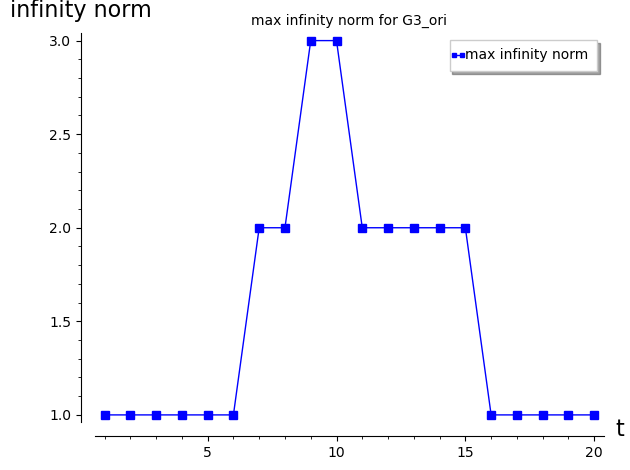

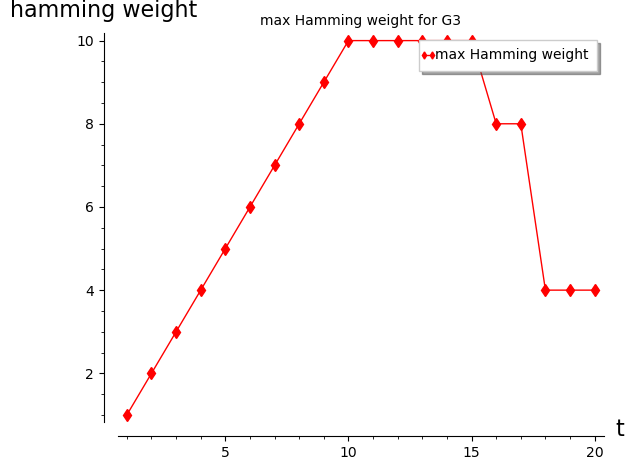

In [111]:
plot_G3_ori_infty_norm = list_plot(curve_smallness_G3_ori_infty_norm, plotjoined=True, marker='s', color='blue', legend_label = 'max infinity norm', axes_labels=['t','infinity norm'],title='max infinity norm for G3_ori')
show(plot_G3_ori_infty_norm, legend_loc = 'upper right')
plot_G3_ori_hamming_weight = list_plot(curve_smallness_G3_ori_hamming_weight, plotjoined=True, marker='d', color='red', legend_label = 'max Hamming weight', axes_labels=['t','hamming weight'],title='max Hamming weight for G3_ori')
show(plot_G3_hamming_weight,legend_loc = 'upper right')

# Constructing Small Reconstruction Vector

Suppose $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $S \subseteq [1,n]$. Recall that $S$ is certified if and only if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$. We have $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G}_S)$ if and only if there exists $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ such that $\bm{\lambda}_S^\top \mathbf{G}_S = \mathbf{e}_1^\top$. We call this vector $\bm{\lambda}_S$ as the reconstruction vector. Recall that if $\mathbf{R}_{\mathbf{G}_S} \in \mathbb{Z}^{|S| \times k}$ is the row HNF of $\mathbf{G}_S$, then there is $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$. Moreover, we also have the following lemma.

**Lemma**. Let $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $\mathbf{R}_\mathbf{G} \in \mathbb{Z}^{n \times k}$ be the row-HNF of $\mathbf{G}$, i.e., there exists $\mathbf{U}_\mathbf{G} \in GL_n(\mathbb{Z})$ such that $\mathbf{R}_\mathbf{G} = \mathbf{U}_\mathbf{G} \mathbf{G}$. Assume that $\mathbf{R}_\mathbf{G}$ is in standard row-HNF (row-echelon/upper-triangular pivot structure, positive pivots, and for each pivot column, the entries above the pivots are reduced modulo the pivot). Let $\mathbf{e}_1^\top = (1,0,\dots,0)\in \mathbb{Z}^{1 \times k}$, then $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Z}(\mathbf{G})$ if and only if $\mathbf{R}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$. ($\mathbf{R}_\mathbf{G}[1,\cdot]$ is the first row of $\mathbf{R}_\mathbf{G}$ in $1$-based indexing.)
 
By considering the lemma we can choose $\bm{\lambda}_S^\top = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$. Notice that $\bm{\lambda}_S^\top\mathbf{G}_S = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]\cdot\mathbf{G}_S = (\mathbf{U}_{\mathbf{G}_S}\cdot\mathbf{G}_S)[1,\cdot] = \mathbf{R}_{\mathbf{G}_S}[1,\cdot] = \mathbf{e}_1^\top$. Nevertheless, the entries of $\mathbf{U}_{\mathbf{G}_S}$ are not always small. We are interested in finding a reconstruction vector $\bm{\lambda}_S \in \mathbb{Z}^{|S|}$ such that $\|\bm{\lambda}_S\|_\infty$ is small. To do so, we consider the following steps:
1. Compute $\mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ with $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row-HNF of $\mathbf{G}_S$. Denote $\bm{\lambda}_{S,0} = (\mathbf{U}_{\mathbf{G}_S}[1,\cdot])^\top$.
2. Compute $K = \ker_\mathbb{Z}(\mathbf{G}_S^\top)$ and define $\mathbf{B}_K$ as the matrix whose rows are the basis of $K$.
3. Perform the LLL algorithm to $\mathbf{B}_K$ so we have the reduced basis $\mathbf{B}_K'$. For brevity, suppose $\mathbf{B}_K' = \begin{bmatrix}\mathbf{B}_K'[1,\cdot] \\ \vdots \\ \mathbf{B}_K'[r,\cdot]\end{bmatrix}$ for some $r \in \mathbb{Z}^+$ (the number of rows of $\mathbf{B}_K'$).
4. Choose $\bm{\kappa} \in K$ by considering the integer linear combinations of the rows in $\mathbf{B}_K'$, i.e., $\bm{\kappa}^\top = \sum_{i=1}^r\alpha_i \cdot \mathbf{B}_K'[i,\cdot] = \bm{\alpha}^\top \mathbf{B}_K' $ or equivalently $\mathbf{B}_K'^\top \bm{\alpha} = \bm{\kappa}$ for some $\bm{\alpha} \in \mathbb{Z}^{r}$. In particular $\bm{\kappa}$ is chosen so that $\bm{\lambda}_S  = \bm{\lambda}_{S,0} + \bm{\kappa}$ has small entries, i.e., $\|\bm{\lambda}_S\|_\infty$ is sufficiently small.

Notice that
\begin{align*}
    \bm{\lambda}_S^\top \cdot\mathbf{G}_S &= \left(\bm{\lambda}_{S,0} + \bm{\kappa}\right)^\top \cdot \mathbf{G}_S = \bm{\lambda}_{S,0}^\top \cdot \mathbf{G}_S + \bm{\kappa}^\top \cdot \mathbf{G}_S \\
    &= \bm{\lambda}_{S,0}^\top\cdot \mathbf{G}_S = \mathbf{U}_{\mathbf{G}_S}[1,\cdot] \cdot \mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}[1,\cdot].
\end{align*}

## Some Basic Algorithms

### Without Babai's algorithm

Helper functions.

In [112]:
def linf_norm(v):
    """Infinity norm for a ZZ vector-like object."""
    if len(v) == 0:
        return ZZ(0)
    return max(abs(ZZ(x)) for x in v)

Compute the initial solution $\bm{\lambda}_{S,0} = \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row HNF of $\mathbf{G}_S$.

In [113]:
def hnf_initial_lambda(G_S):
    """
    Compute row-HNF of G_S with transformation:
        U * G_S = R
    Return:
        lam0 = U.row(0)  (ZZ row vector length |S|)
    """
    # Assume G_S is already over ZZ
    if G_S.nrows() == 0:
        return None

    R, U = G_S.hermite_form(transformation=True)

    # IMPORTANT: we use U.row(0) (vector-like), NOT U[0,:] (1×n matrix slice)
    lam0 = U.row(0)

    return lam0

Compute the LLL-reduced kernel basis of $\ker_\mathbb{Z}(\mathbf{G}_S^\top)$.

In [114]:
def kernel_basis_lll_of_GS_transpose(G_S, use_lll=True):
    """
    Compute a basis matrix B for K = ker_Z(G_S^T) such that:
        rows(B) span K as a Z-lattice.
    Optionally LLL-reduce the row basis.

    Returns:
        B (ZZ matrix with r rows and |S| columns)
    """
    A = G_S.transpose()              # k x |S|
    K = A.right_kernel(ZZ)           # integer kernel lattice
    B = K.basis_matrix()             # rows are a Z-basis

    if use_lll and B.nrows() > 1:
        B = B.LLL()

    return B

Implementing greedy reduction of $\|\bm{\lambda}\|_\infty$ using the kernel basis.

In [115]:
def greedy_reduce_linf(lambda0, B_kernel, passes=3, window=3):
    """
    Greedy reduction of ||lambda||_inf by adding integer kernel vectors.

    Inputs:
      lambda0 : ZZ row vector length s (initial)
      B_kernel: ZZ matrix whose rows b_i satisfy b_i^T * G_S = 0^T
      passes  : number of passes over the basis
      window  : search window around alpha0 (nearest integer)

    Output:
      lambda_best : ZZ row vector
    """
    lam = vector(ZZ, list(lambda0))
    best = linf_norm(lam)

    if B_kernel.nrows() == 0:
        return lam  # no kernel directions available

    for _ in range(int(passes)):
        improved = False

        for i in range(B_kernel.nrows()):
            b = vector(ZZ, list(B_kernel.row(i)))

            # choose index j of largest coordinate of lam
            j = max(range(len(lam)), key=lambda t: abs(lam[t]))

            if b[j] == 0:
                continue  # cannot change the worst coordinate

            # nearest integer to -lam[j]/b[j]
            alpha0 = ZZ(round(QQ(-lam[j]) / QQ(b[j])))

            lam_best = lam
            norm_best = best

            for alpha in range(int(alpha0 - window), int(alpha0 + window) + 1):
                cand = lam + ZZ(alpha) * b
                cand_norm = linf_norm(cand)
                if cand_norm < norm_best:
                    lam_best = cand
                    norm_best = cand_norm

            if norm_best < best:
                lam = lam_best
                best = norm_best
                improved = True

        if not improved:
            break

    return lam

Given a subset $S \subseteq [1,n]$, the reconstruction vector $\bm{\lambda}_S$ is obtained from $\mathbf{G}_S$ using the following steps:
1. Get $\bm{\lambda}_{S,0}^\top := \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row HNF of $\mathbf{G}_S$. That is, $\mathbf{U}_{G}[1,\cdot]$ is the first row of the unimodular matrix that transforms $\mathbf{G}_S$ to its row HNF $\mathbf{R}_{\mathbf{G}_S}$.
2. Compute $K := \ker_\mathbb{Z}(\mathbf{G}_S^\top)$ and define $\mathbf{B}_K \in \mathbb{Z}^{r \times |S|}$ matrix whose rows are the basis of $K$.
3. Perform LLL to obtain an LLL-reduced basis for $K$, define $\mathbf{B}_K' \in \mathbb{Z}^{r \times |S|}$ as the matrix whose rows are the LLL-reduced basis of $K$.
4. Greedy reduced $\|\bm{\lambda}_S\|_\infty$ by considering the LLL-reduced basis $\mathbf{B}_K'$.

In [116]:
def construct_small_lambda(G, S, passes = 3, window = 3):
    '''
    Input:
    G: ZZ matrix (n x k)
    S: subset of row indice (0-based)
    Return
    lambda_small (the small reconstruction vector lambda)
    '''
    S = list(S)
    assert len(S) > 0
    # G_S = G[S,:]
    G_S = G.matrix_from_rows(S)
    # computing lambda_0 = U_G[0,:]
    lambda_0 = hnf_initial_lambda(G_S)
    # computing the matrix whose rows are the LLL-reduced basis of G_S^T 
    B = kernel_basis_lll_of_GS_transpose(G_S,use_lll=True)
    # computing lambda_small
    lambda_small = greedy_reduce_linf(lambda_0, B, passes = passes, window = window)

    return lambda_small

### With Babai's algorithm

Given a lattice basis $B = \{\mathbf{b}_i,\dots,\mathbf{b}_r\}$ and a target $\mathbf{t}$, Babai's (nearest plane) algorithm works from the last basis vector down to the first, greedily snapping to the nearest hyperplane at each step. The algorithm returns a vector spanned by $B$ aproximate closest to $\mathbf{t}$. Here are the steps:
1. Compute the Gram-Schmidt orthogonalization $\tilde{B}$.
2. Set $\mathbf{b}:= \mathbf{t}$.
3. For $i = r$ down to $1$.
   1. Compute the coordinate $\mathbf{b}$ along $\mathbf{\tilde{b}}_i$ as $c_i = \frac{\langle\mathbf{b},\mathbf{\tilde{b}}_i\rangle}{\|\mathbf{\tilde{b}}_i\|_2^2}$.
   2. Set $\hat{c}_i = \lfloor c_i \rceil$.
   3. Update $\mathbf{b}:= \mathbf{b}-\hat{c}_i \cdot \mathbf{b}_i$.
4. Return $\mathbf{t}-\mathbf{b}$ as the approximate closest lattice vector.

In [117]:
from sage.all import ZZ, RealField, vector

def babai_nearest(B, target, prec=128):
    """
    Babai's nearest-plane algorithm (rows-as-basis).

    Input:
      B      : matrix (r x m), rows are lattice basis vectors in ZZ^m (typically LLL-reduced)
      target : vector-like of length m (ZZ/QQ/RR entries ok)
      prec   : real precision in bits for Gram–Schmidt/projections (default 128)

    Output:
      None if dimension mismatch
      otherwise: a vector in ZZ^m lying in the ZZ-span of rows(B),
                 approximating the closest lattice vector to target (Euclidean sense).
    """
    r = B.nrows()
    m = B.ncols()
    if len(target) != m:
        return None

    R = RealField(prec)
    t = vector(R, list(target))
    b = [vector(R, list(B.row(i))) for i in range(r)]

    # Gram–Schmidt orthogonalization: build b_star[i] = tilde{b}_i
    b_star = []
    for i in range(r):
        v = b[i]
        for j in range(i):
            denom = b_star[j].dot_product(b_star[j])
            if denom != 0:
                mu = v.dot_product(b_star[j]) / denom
                v = v - mu * b_star[j]
        b_star.append(v)

    # Nearest-plane loop (backwards)
    residual = t
    coeffs = [ZZ(0)] * r

    for i in reversed(range(r)):
        denom = b_star[i].dot_product(b_star[i])
        if denom == 0:
            # linearly dependent basis vector; ignore it
            coeffs[i] = ZZ(0)
            continue

        # c_i = <residual, b*_i> / ||b*_i||^2
        ci = residual.dot_product(b_star[i]) / denom

        # Built-in rounding to nearest integer, then coerce to ZZ
        ci_hat = ZZ(ci.round())
        coeffs[i] = ci_hat

        residual = residual - R(ci_hat) * b[i]

    # Construct lattice vector sum_i coeffs[i] * (integer row i)
    closest = vector(ZZ, [0]*m)
    for i in range(r):
        if coeffs[i] != 0:
            closest += coeffs[i] * vector(ZZ, list(B.row(i)))

    return closest

Given a subset $S \subseteq [1,n]$, the reconstruction vector $\bm{\lambda}_S$ is obtained from $\mathbf{G}_S$ using the following steps:
1. Get $\bm{\lambda}_{S,0}^\top := \mathbf{U}_{\mathbf{G}_S}[1,\cdot]$ where $\mathbf{U}_{\mathbf{G}_S} \in GL_{|S|}(\mathbb{Z})$ such that $\mathbf{U}_{\mathbf{G}_S}\mathbf{G}_S = \mathbf{R}_{\mathbf{G}_S}$ and $\mathbf{R}_{\mathbf{G}_S}$ is the row HNF of $\mathbf{G}_S$. That is, $\mathbf{U}_{G}[1,\cdot]$ is the first row of the unimodular matrix that transforms $\mathbf{G}_S$ to its row HNF $\mathbf{R}_{\mathbf{G}_S}$.
2. Compute $K := \ker_\mathbb{Z}(\mathbf{G}_S^\top)$ and define $\mathbf{B}_K \in \mathbb{Z}^{r \times |S|}$ matrix whose rows are the basis of $K$.
3. Perform LLL to obtain an LLL-reduced basis for $K$, define $\mathbf{B}_K' \in \mathbb{Z}^{r \times |S|}$ as the matrix whose rows are the LLL-reduced basis of $K$.
4. Compute $\bm{\kappa} \in K$ as the lattice vector spanned by the rows of $\mathbf{B}_K'$ with target vector $\bm{\lambda}_{S,0}$.
5. Compute $\bm{\lambda}_{Babai} = \bm{\lambda}_{S,0} + \bm{\kappa}$.
6. If $\|\bm{\lambda}_{Babai}\|_\infty \leq \|\bm{\lambda}_{S,0}\|_\infty$, update $\bm{\lambda}_S:= \bm{\lambda}_{Babai}$.
7. Greedy reduced $\|\bm{\lambda}_S\|_\infty$ by considering the LLL-reduced basis $\mathbf{B}_K'$.

In [118]:
def construct_small_lambda_babai(G, S, passes=3, window=3):
    """
    Input:
      G : ZZ matrix (n x k)
      S : subset of row indices (0-based)
    Output:
      lambda_small : reduced reconstruction vector (ZZ vector of length |S|)
    """
    S = list(S)
    assert len(S) > 0

    G_S = G.matrix_from_rows(S)

    # HNF initial vector
    lambda_0 = hnf_initial_lambda(G_S)
    assert lambda_0 is not None

    # LLL-reduced kernel basis of G_S^T
    B = kernel_basis_lll_of_GS_transpose(G_S, use_lll=True)

    # Try Babai initializer
    kappa = babai_nearest(B, -lambda_0)
    lambda_start = lambda_0

    if kappa is not None:
        lambda_babai = lambda_0 + kappa
        linf0 = linf_norm(lambda_0)
        linf_b = linf_norm(lambda_babai)
        if linf_b <= linf0:
            lambda_start = lambda_babai

    # Greedy refinement
    lambda_small = greedy_reduce_linf(lambda_start, B, passes=passes, window=window)
    return lambda_small

## Checking the smallnes of the reduced reconstruction vector

### Without Babai's algorithm

The previous **construct_small_lambda(G,S,passes,window)** is a greedy algorithm that constructs a small $\bm{\lambda}_S$ using the greedy approach. The function **linf_max_reduced(G,s,passes,window)** for $s \in [1,n]$ compute $\max\{\|\bm{\lambda}_S\|_\infty: |S| = s, \bm{\lambda}_S\text{ is obtained from the above reduction}\}$ and its corresponding Hamming weight where $\bm{\lambda}_S$ is obtained from **construct_small_lambda(G,S,passes,window)**.

In [119]:
from itertools import combinations

def linf_max_reduced(G, s, passes=3, window=3, return_argmax=False):
    """
    Compute max ||lambda_S||_inf and wt_H(lambda_S) over all subsets S of size s,
    where lambda_S is produced by construct_small_lambda(G, S, passes, window).

    If return_argmax=True, also return one subset achieving the max.
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    linf_max = ZZ(0)
    lam_max = None
    S_max = None

    for S in combinations(range(n), s):
        lam = construct_small_lambda(G, S, passes=passes, window=window)
        linf_curr = linf_norm(lam)

        if linf_curr > linf_max:
            linf_max = linf_curr
            lam_max = lam
            S_max = list(S)
    # Hamming weight of the optimized lambda_S
    ham_weight_max = hamming_weight(lam_max)
    if return_argmax:
        return (linf_max, ham_weight_max, S_max)
    return (linf_max, ham_weight_max)

Constructing the curve for **linf_max_reduced(G,s)** for a given $\mathbf{G}$ and $1\leq s\leq n$.

In [120]:
def linf_max_reduced_curve(G, passes=3, window=3, s_min=1, s_max=None):
    '''
    Return a list of pairs
        [(s, linf_max_reduced(G, s)) for s in [s_min, s_max]]
    using exact enumeration.
    '''
    n = G.nrows()

    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []
    for s in range(s_min, s_max + 1):
        linf_max_reduced_s, ham_weight_max_reduced_s = linf_max_reduced(G, s, passes=passes, window=window, return_argmax=False)
        curve.append((s, linf_max_reduced_s, ham_weight_max_reduced_s))
    return curve


### With Babai's algorithm

The previous **construct_small_lambda_babai(G,S,passes,window)** is a greedy algorithm that constructs a small $\bm{\lambda}_S$ using the greedy approach. The function **linf_max_reduced_babai(G,s,passes,window)** for $s \in [1,n]$ compute $\max\{\|\bm{\lambda}_S\|_\infty: |S| = s, \bm{\lambda}_S\text{ is obtained from the above reduction}\}$ and its corresponding Hamming weight where $\bm{\lambda}_S$ is obtained from **construct_small_lambda_babai(G,S,passes,window)**.

In [121]:
from itertools import combinations

def linf_max_reduced_babai(G, s, passes=3, window=3, return_argmax=False):
    """
    Compute max ||lambda_S||_inf and wt_H(lambda_S) over all subsets S of size s,
    where lambda_S is produced by construct_small_lambda_babai(G, S, passes, window).

    If return_argmax=True, also return one subset achieving the max.
    """
    n = G.nrows()
    s = int(s)
    assert 1 <= s <= n

    linf_max = ZZ(0)
    lam_max = None
    S_max = None

    for S in combinations(range(n), s):
        lam = construct_small_lambda_babai(G, S, passes=passes, window=window)
        linf_curr = linf_norm(lam)

        if linf_curr > linf_max:
            linf_max = linf_curr
            lam_max = lam
            S_max = list(S)
    # Hamming weight of the optimized lambda_S
    ham_weight_max = hamming_weight(lam_max)
    if return_argmax:
        return (linf_max, ham_weight_max, S_max)
    return (linf_max, ham_weight_max)

Constructing the curve for **linf_max_reduced_babai(G,s)** for a given $\mathbf{G}$ and $1\leq s\leq n$.

In [122]:
def linf_max_reduced_babai_curve(G, passes=3, window=3, s_min=1, s_max=None):
    '''
    Return a list of pairs
        [(s, linf_max_reduced_babai(G, s)) for s in [s_min, s_max]]
    using exact enumeration.
    '''
    n = G.nrows()

    if s_max is None:
        s_max = n

    s_min = max(1, int(s_min))
    s_max = min(int(s_max), n)

    curve = []
    for s in range(s_min, s_max + 1):
        linf_max_reduced_s, ham_weight_max_reduced_s = linf_max_reduced_babai(G, s, passes=passes, window=window, return_argmax=False)
        curve.append((s, linf_max_reduced_s, ham_weight_max_reduced_s))
    return curve

### Helper for presentation

A function to create a combined table (used later).

In [123]:
def smallness_with_reduced(curve_smallness_G, curve_smallness_G_red, n):
    """
    Combine two smallness curves into a single table.
    
    INPUT:
    - curve_smallness_G: list of triples (t, inf_norm, hamming_wt)
    - curve_smallness_G_red: list of triples (t, inf_norm_reduced, hamming_wt_reduced)
    - n: parameter for the caption
    
    OUTPUT:
    - displays a pandas DataFrame with columns:
      t, infinity norm bound, Hamming weight,
      infinity norm bound (reduced), Hamming weight (reduced)
    """
    df_G = pd.DataFrame(curve_smallness_G, columns=['t', 'infinity norm bound', 'Hamming weight'])
    df_G_red = pd.DataFrame(curve_smallness_G_red, columns=['t', 'infinity norm bound (reduced)', 'Hamming weight (reduced)'])
    
    # Merge on 't' — since t_G and t_H are identical, inner join is fine
    df = df_G.merge(df_G_red, on='t', how='inner')
    
    df = df.sort_values('t', ascending=False).reset_index(drop=True)
    
    caption = f"experiment for smallness and sparsity for n = {n}"
    display(df.style.set_caption(caption))

# Testing the effect on reducing the reconstruction vector

## Testing for $\mathbf{G}_1$

### With randomized $\mathbf{H}$

#### Greedy only

In [124]:
%%time
show(G1)
curve_linf_max_reduced_G1 = linf_max_reduced_curve(G1,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_G1)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 1, 1), (5, 1, 1), (6, 2, 6), (7, 2, 6), (8, 2, 6), (9, 2, 6), (10, 2, 8), (11, 2, 8), (12, 2, 9), (13, 2, 9), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 6min 6s, sys: 3.14 s, total: 6min 9s
Wall time: 6min 9s


In [125]:
smallness_with_reduced(curve_smallness_G1,curve_linf_max_reduced_G1,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,6,1,4
4,16,1,6,1,4
5,15,1,6,1,4
6,14,2,10,1,4
7,13,2,10,2,9
8,12,2,10,2,9
9,11,2,10,2,8


In [126]:
curve_smallness_G1_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G1]
curve_smallness_G1_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G1]
print(curve_smallness_G1_red_infty_norm)
print(curve_smallness_G1_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 6), (7, 6), (8, 6), (9, 6), (10, 8), (11, 8), (12, 9), (13, 9), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


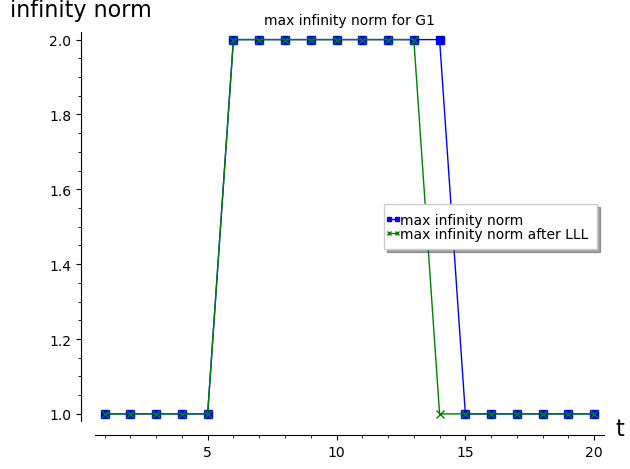

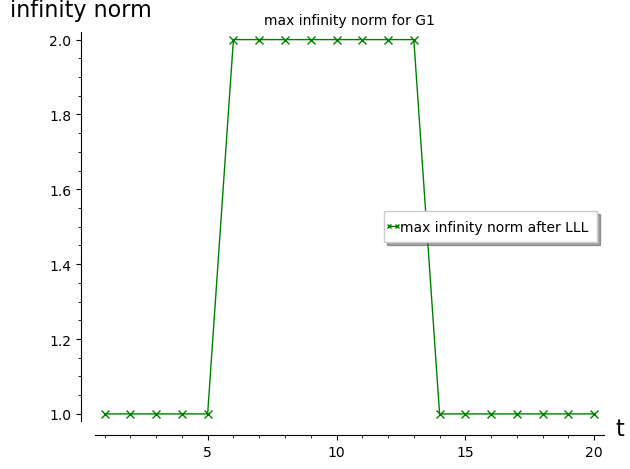

In [127]:
plot_G1_red_inf_norm = list_plot(curve_smallness_G1_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after LLL', axes_labels=['t','infinity norm'],title='max infinity norm for G1')
show(plot_G1_infty_norm + plot_G1_red_inf_norm)
show(plot_G1_red_inf_norm)

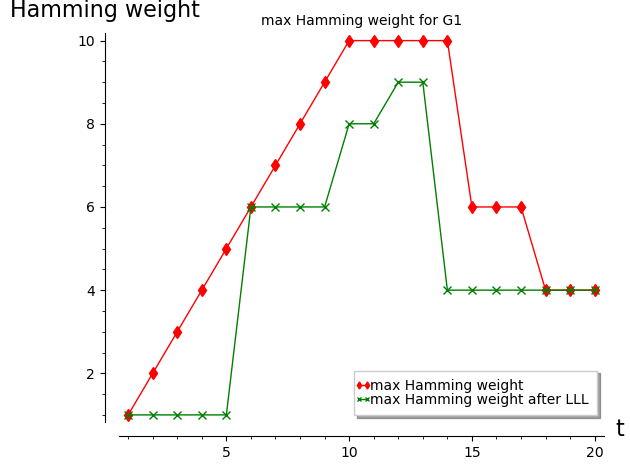

In [128]:
plot_G1_red_ham_weight = list_plot(curve_smallness_G1_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after LLL', axes_labels=['t','Hamming weight'],title='max Hamming weight for G1')
show(plot_G1_hamming_weight+plot_G1_red_ham_weight)

#### With Babai

In [129]:
%%time
show(G1)
curve_linf_max_reduced_babai_G1 = linf_max_reduced_babai_curve(G1,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_babai_G1)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 1, 1), (5, 1, 1), (6, 2, 6), (7, 2, 6), (8, 2, 6), (9, 2, 6), (10, 2, 6), (11, 2, 6), (12, 1, 4), (13, 1, 4), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 9min 8s, sys: 3.84 s, total: 9min 12s
Wall time: 9min 12s


In [130]:
smallness_with_reduced(curve_smallness_G1,curve_linf_max_reduced_babai_G1,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,6,1,4
4,16,1,6,1,4
5,15,1,6,1,4
6,14,2,10,1,4
7,13,2,10,1,4
8,12,2,10,1,4
9,11,2,10,2,6


In [131]:
curve_smallness_G1_babai_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_babai_G1]
curve_smallness_G1_babai_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_babai_G1]
print(curve_smallness_G1_babai_red_infty_norm)
print(curve_smallness_G1_babai_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 6), (12, 4), (13, 4), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


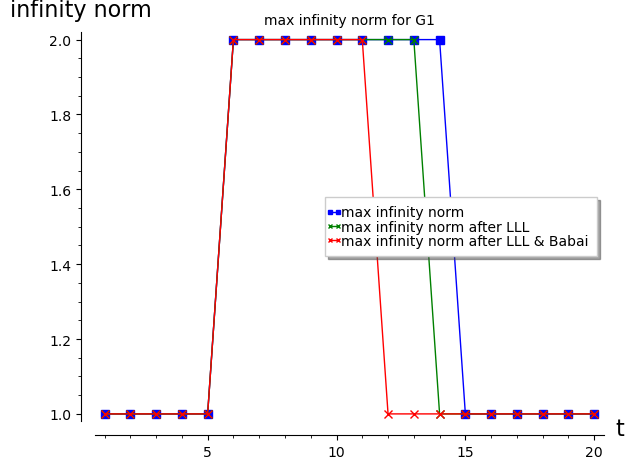

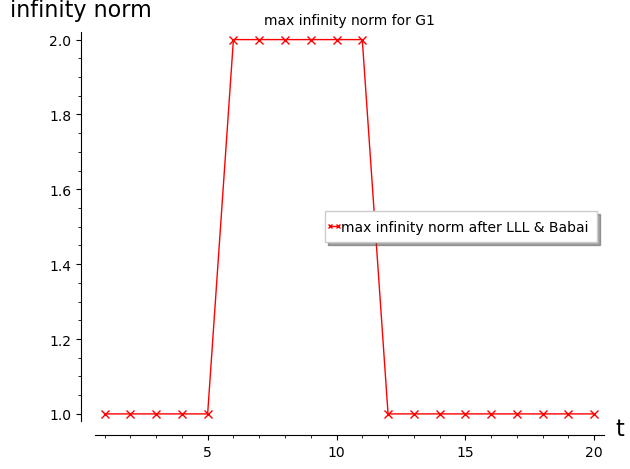

In [132]:
plot_G1_babai_red_inf_norm = list_plot(curve_smallness_G1_babai_red_infty_norm, plotjoined=True, marker='x', color='red', legend_label = 'max infinity norm after LLL & Babai', axes_labels=['t','infinity norm'],title='max infinity norm for G1')
show(plot_G1_infty_norm + plot_G1_red_inf_norm + plot_G1_babai_red_inf_norm)
show(plot_G1_babai_red_inf_norm)

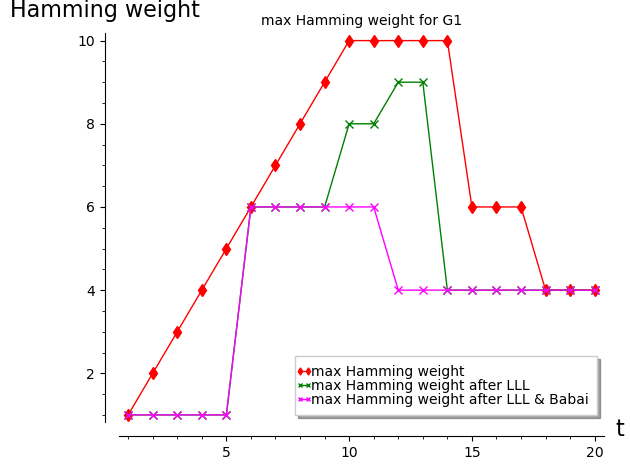

In [133]:
plot_G1_babai_red_ham_weight = list_plot(curve_smallness_G1_babai_red_hamming_weight, plotjoined=True, marker='x', color='magenta', legend_label = 'max Hamming weight after LLL & Babai', axes_labels=['t','Hamming weight'],title='max Hamming weight for G1')
show(plot_G1_hamming_weight+plot_G1_red_ham_weight+plot_G1_babai_red_ham_weight)

### Original $\mathbf{H}$

#### Greedy only

In [134]:
%%time
show(G1_ori)
curve_linf_max_reduced_G1_ori = linf_max_reduced_curve(G1_ori,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_G1_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 1, 1), (5, 1, 1), (6, 1, 3), (7, 1, 3), (8, 1, 3), (9, 1, 3), (10, 1, 1), (11, 1, 1), (12, 1, 4), (13, 1, 4), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 6min 7s, sys: 3.22 s, total: 6min 10s
Wall time: 6min 10s


In [135]:
smallness_with_reduced(curve_smallness_G1_ori,curve_linf_max_reduced_G1_ori,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,6,1,4
4,16,1,6,1,4
5,15,1,6,1,4
6,14,1,10,1,4
7,13,1,10,1,4
8,12,1,10,1,4
9,11,1,10,1,1


In [136]:
curve_smallness_G1_ori_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G1_ori]
curve_smallness_G1_ori_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G1_ori]
print(curve_smallness_G1_ori_red_infty_norm)
print(curve_smallness_G1_ori_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 3), (7, 3), (8, 3), (9, 3), (10, 1), (11, 1), (12, 4), (13, 4), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


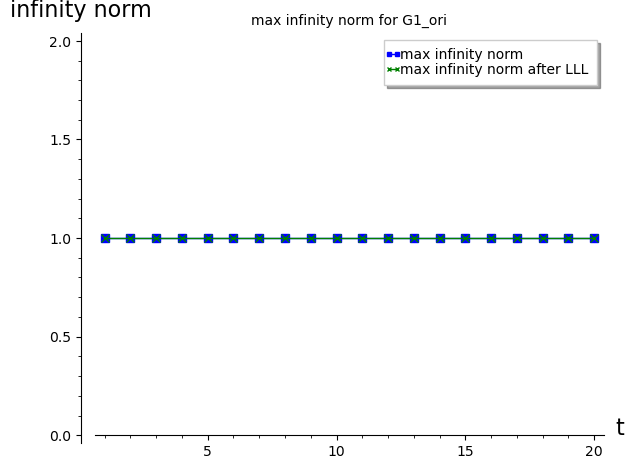

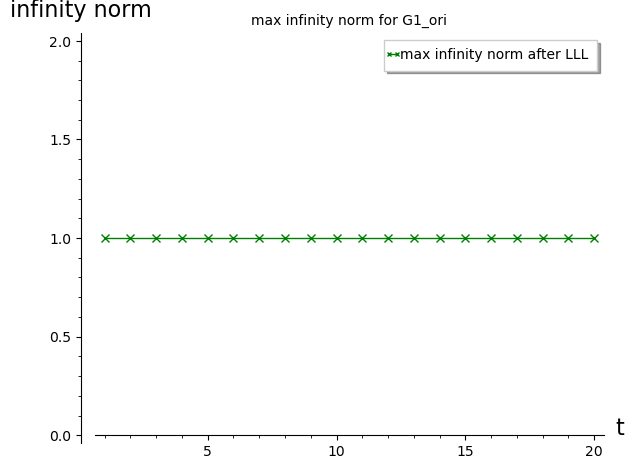

In [137]:
plot_G1_ori_red_inf_norm = list_plot(curve_smallness_G1_ori_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after LLL', axes_labels=['t','infinity norm'],title='max infinity norm for G1_ori')
show(plot_G1_ori_infty_norm + plot_G1_ori_red_inf_norm)
show(plot_G1_ori_red_inf_norm)

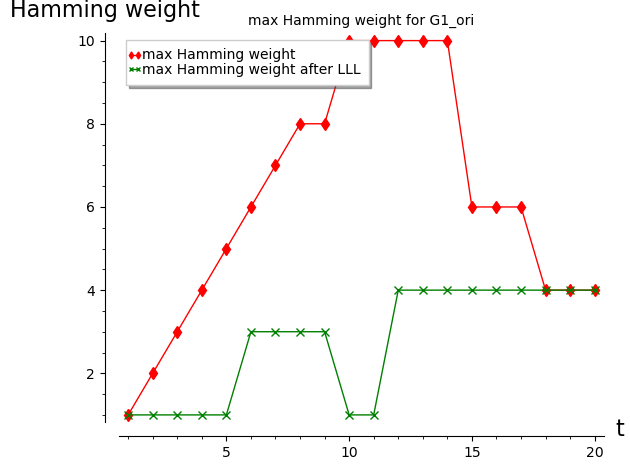

In [138]:
plot_G1_ori_red_ham_weight = list_plot(curve_smallness_G1_ori_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after LLL', axes_labels=['t','Hamming weight'],title='max Hamming weight for G1_ori')
show(plot_G1_ori_hamming_weight+plot_G1_ori_red_ham_weight)

#### With Babai

In [139]:
%%time
show(G1_ori)
curve_linf_max_reduced_babai_G1_ori = linf_max_reduced_babai_curve(G1_ori,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_babai_G1_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 1, 1), (5, 1, 1), (6, 1, 3), (7, 1, 3), (8, 1, 3), (9, 1, 3), (10, 1, 1), (11, 1, 1), (12, 1, 4), (13, 1, 4), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 9min 4s, sys: 3.72 s, total: 9min 7s
Wall time: 9min 7s


In [140]:
smallness_with_reduced(curve_smallness_G1,curve_linf_max_reduced_babai_G1_ori,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,6,1,4
4,16,1,6,1,4
5,15,1,6,1,4
6,14,2,10,1,4
7,13,2,10,1,4
8,12,2,10,1,4
9,11,2,10,1,1


In [141]:
curve_smallness_G1_ori_babai_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_babai_G1_ori]
curve_smallness_G1_ori_babai_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_babai_G1_ori]
print(curve_smallness_G1_ori_babai_red_infty_norm)
print(curve_smallness_G1_ori_babai_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 3), (7, 3), (8, 3), (9, 3), (10, 1), (11, 1), (12, 4), (13, 4), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


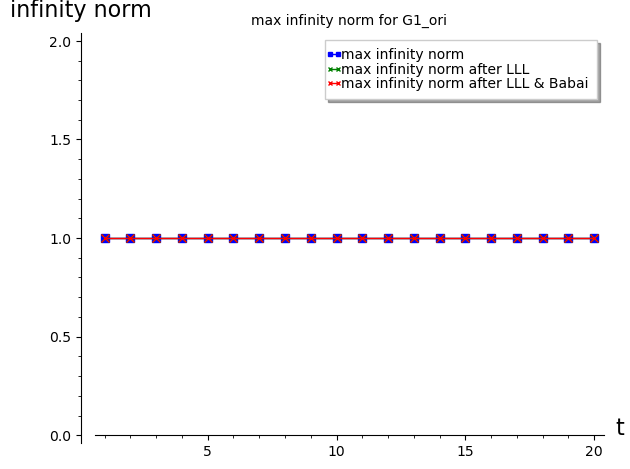

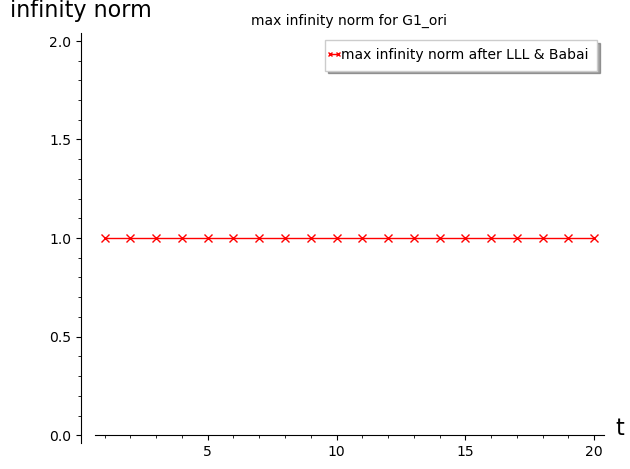

In [142]:
plot_G1_ori_babai_red_inf_norm = list_plot(curve_smallness_G1_ori_babai_red_infty_norm, plotjoined=True, marker='x', color='red', legend_label = 'max infinity norm after LLL & Babai', axes_labels=['t','infinity norm'],title='max infinity norm for G1_ori')
show(plot_G1_ori_infty_norm + plot_G1_ori_red_inf_norm + plot_G1_ori_babai_red_inf_norm)
show(plot_G1_ori_babai_red_inf_norm)

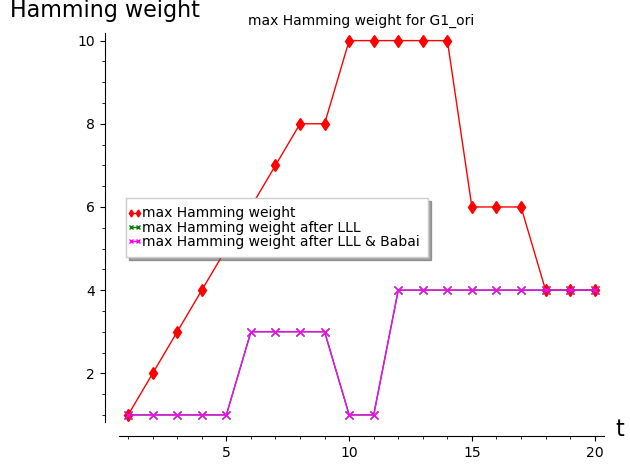

In [187]:
plot_G1_ori_babai_red_ham_weight = list_plot(curve_smallness_G1_ori_babai_red_hamming_weight, plotjoined=True, marker='x', color='magenta', legend_label = 'max Hamming weight after LLL & Babai', axes_labels=['t','Hamming weight'],title='max Hamming weight for G1_ori')
show(plot_G1_ori_hamming_weight+plot_G1_ori_red_ham_weight+plot_G1_ori_babai_red_ham_weight)

## Testing for $\mathbf{G}_2$

### With randomized $\mathbf{H}$

#### Greedy only

In [144]:
%%time
show(G2)
curve_linf_max_reduced_G2 = linf_max_reduced_curve(G2,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_G2)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 2, 4), (5, 2, 4), (6, 2, 4), (7, 2, 4), (8, 2, 4), (9, 2, 7), (10, 2, 7), (11, 2, 8), (12, 2, 8), (13, 2, 8), (14, 2, 7), (15, 2, 7), (16, 2, 7), (17, 2, 8), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 6min 8s, sys: 3.18 s, total: 6min 11s
Wall time: 6min 11s


In [145]:
smallness_with_reduced(curve_smallness_G2,curve_linf_max_reduced_G2,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,2,8,2,8
4,16,2,8,2,7
5,15,2,10,2,7
6,14,2,10,2,7
7,13,2,10,2,8
8,12,2,10,2,8
9,11,2,10,2,8


In [146]:
curve_smallness_G2_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G2]
curve_smallness_G2_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G2]
print(curve_smallness_G2_red_infty_norm)
print(curve_smallness_G2_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 2), (17, 2), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 4), (5, 4), (6, 4), (7, 4), (8, 4), (9, 7), (10, 7), (11, 8), (12, 8), (13, 8), (14, 7), (15, 7), (16, 7), (17, 8), (18, 4), (19, 4), (20, 4)]


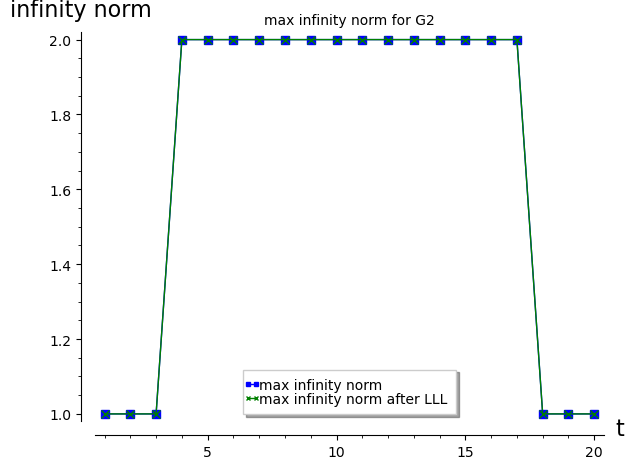

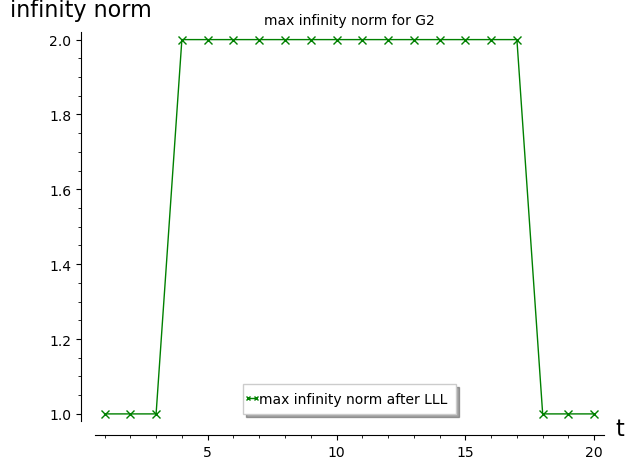

In [147]:
plot_G2_red_inf_norm = list_plot(curve_smallness_G2_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after LLL', axes_labels=['t','infinity norm'],title='max infinity norm for G2')
show(plot_G2_infty_norm +plot_G2_red_inf_norm)
show(plot_G2_red_inf_norm)

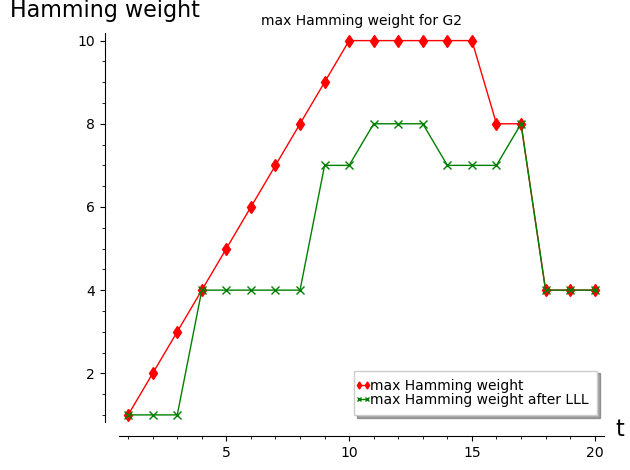

In [148]:
plot_G2_red_ham_weight = list_plot(curve_smallness_G2_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after LLL', axes_labels=['t','Hamming weight'],title='max Hamming weight for G2')
show(plot_G2_hamming_weight+plot_G2_red_ham_weight)

#### With Babai

In [149]:
%%time
show(G2)
curve_linf_max_reduced_babai_G2 = linf_max_reduced_babai_curve(G2,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_babai_G2)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 2, 4), (5, 2, 4), (6, 2, 4), (7, 2, 4), (8, 2, 4), (9, 2, 4), (10, 2, 4), (11, 2, 4), (12, 2, 4), (13, 1, 1), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 8min 52s, sys: 3.42 s, total: 8min 55s
Wall time: 8min 55s


In [150]:
smallness_with_reduced(curve_smallness_G2,curve_linf_max_reduced_babai_G2,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,2,8,1,4
4,16,2,8,1,4
5,15,2,10,1,4
6,14,2,10,1,4
7,13,2,10,1,1
8,12,2,10,2,4
9,11,2,10,2,4


In [151]:
curve_smallness_G2_babai_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_babai_G2]
curve_smallness_G2_babai_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_babai_G2]
print(curve_smallness_G2_babai_red_infty_norm)
print(curve_smallness_G2_babai_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 4), (5, 4), (6, 4), (7, 4), (8, 4), (9, 4), (10, 4), (11, 4), (12, 4), (13, 1), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


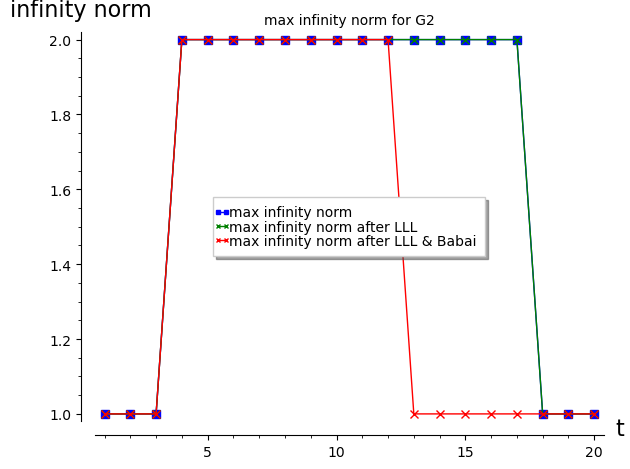

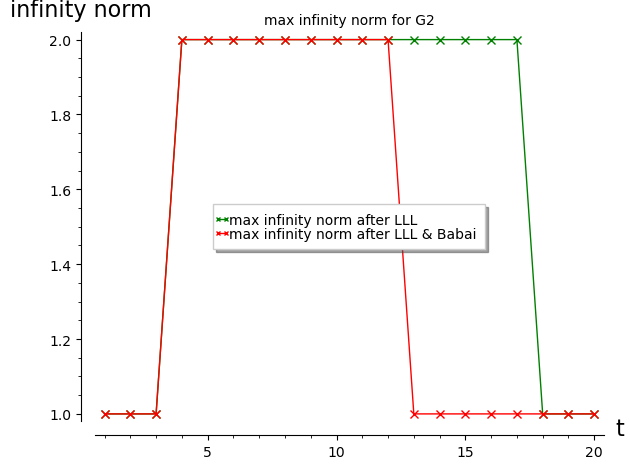

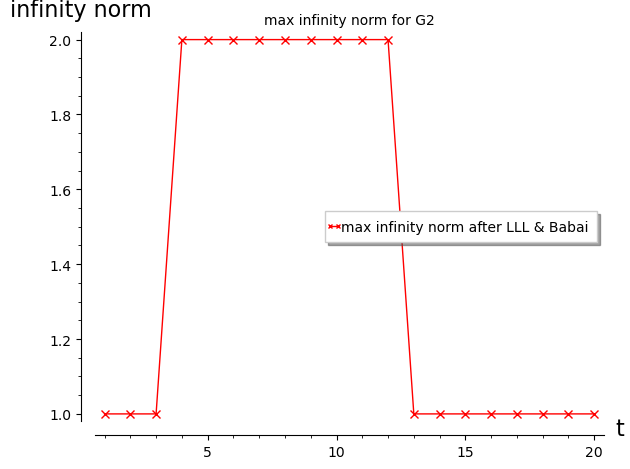

In [152]:
plot_G2_babai_red_inf_norm = list_plot(curve_smallness_G2_babai_red_infty_norm, plotjoined=True, marker='x', color='red', legend_label = 'max infinity norm after LLL & Babai', axes_labels=['t','infinity norm'],title='max infinity norm for G2')
show(plot_G2_infty_norm + plot_G2_red_inf_norm + plot_G2_babai_red_inf_norm)
show(plot_G2_red_inf_norm + plot_G2_babai_red_inf_norm)
show(plot_G2_babai_red_inf_norm)

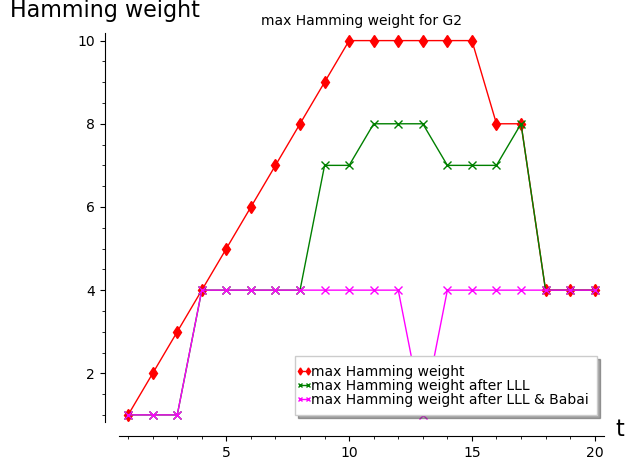

In [153]:
plot_G2_babai_red_ham_weight = list_plot(curve_smallness_G2_babai_red_hamming_weight, plotjoined=True, marker='x', color='magenta', legend_label = 'max Hamming weight after LLL & Babai', axes_labels=['t','Hamming weight'],title='max Hamming weight for G2')
show(plot_G2_hamming_weight+plot_G2_red_ham_weight+plot_G2_babai_red_ham_weight)

### Original $\mathbf{H}$

#### Greedy only

In [154]:
%%time
show(G2_ori)
curve_linf_max_reduced_G2_ori = linf_max_reduced_curve(G2_ori,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_G2_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 2, 4), (5, 2, 5), (6, 2, 6), (7, 2, 6), (8, 2, 6), (9, 2, 6), (10, 2, 6), (11, 2, 8), (12, 2, 8), (13, 2, 9), (14, 2, 7), (15, 2, 7), (16, 2, 7), (17, 2, 8), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 6min 42s, sys: 3.64 s, total: 6min 46s
Wall time: 6min 46s


In [155]:
smallness_with_reduced(curve_smallness_G2_ori,curve_linf_max_reduced_G2_ori,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,2,8,2,8
4,16,2,8,2,7
5,15,2,10,2,7
6,14,2,10,2,7
7,13,2,10,2,9
8,12,2,10,2,8
9,11,2,10,2,8


In [156]:
curve_smallness_G2_ori_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G2_ori]
curve_smallness_G2_ori_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G2_ori]
print(curve_smallness_G2_ori_red_infty_norm)
print(curve_smallness_G2_ori_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 2), (16, 2), (17, 2), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 4), (5, 5), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 8), (12, 8), (13, 9), (14, 7), (15, 7), (16, 7), (17, 8), (18, 4), (19, 4), (20, 4)]


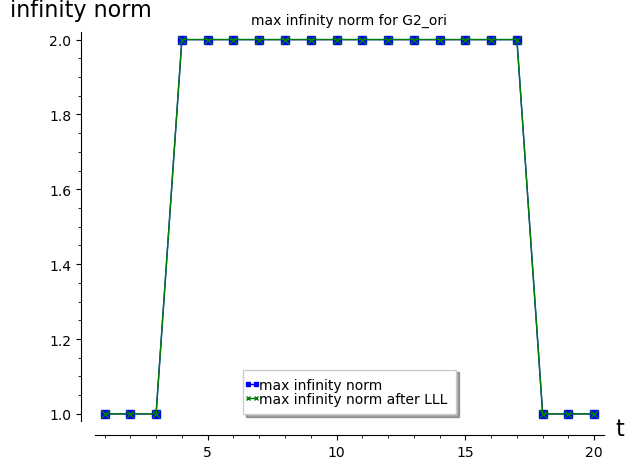

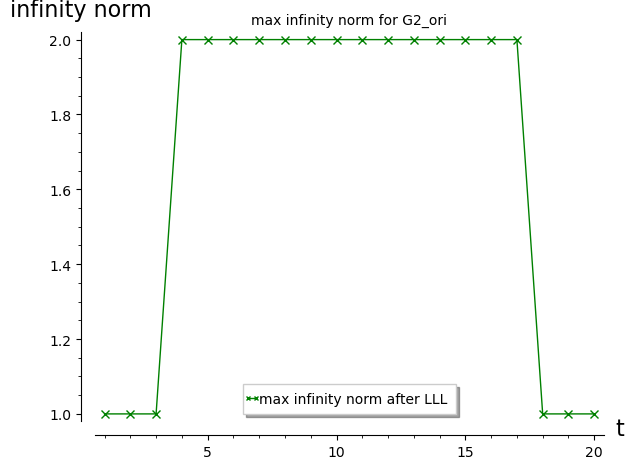

In [157]:
plot_G2_ori_red_inf_norm = list_plot(curve_smallness_G2_ori_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after LLL', axes_labels=['t','infinity norm'],title='max infinity norm for G2_ori')
show(plot_G2_ori_infty_norm +plot_G2_ori_red_inf_norm)
show(plot_G2_ori_red_inf_norm)

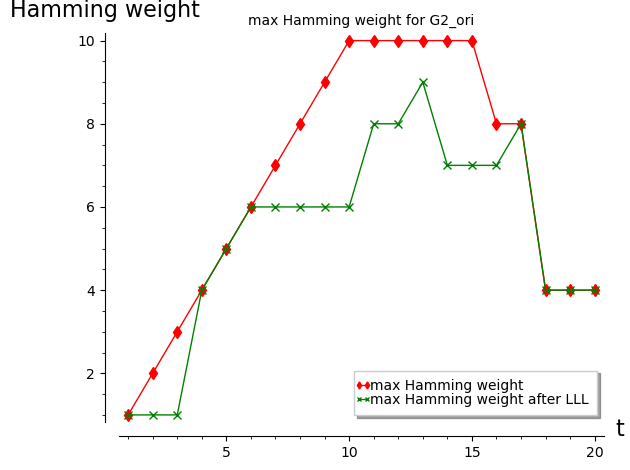

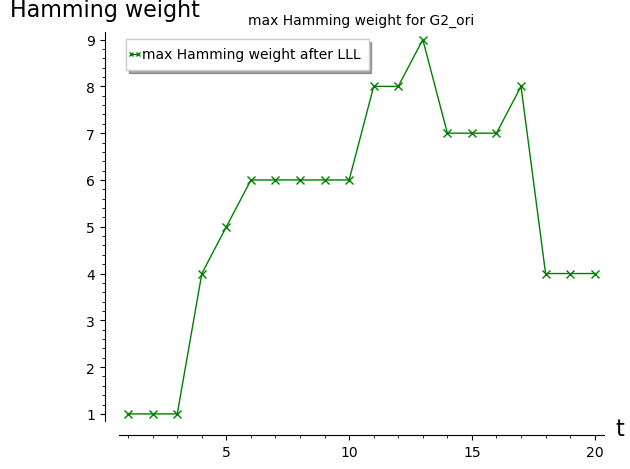

In [158]:
plot_G2_ori_red_ham_weight = list_plot(curve_smallness_G2_ori_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after LLL', axes_labels=['t','Hamming weight'],title='max Hamming weight for G2_ori')
show(plot_G2_ori_hamming_weight+plot_G2_ori_red_ham_weight)
show(plot_G2_ori_red_ham_weight)

#### With Babai

In [159]:
%%time
show(G2_ori)
curve_linf_max_reduced_babai_G2_ori = linf_max_reduced_babai_curve(G2_ori,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_babai_G2_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 2, 4), (5, 2, 5), (6, 2, 6), (7, 2, 6), (8, 2, 6), (9, 2, 6), (10, 2, 6), (11, 2, 6), (12, 2, 6), (13, 2, 6), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 9min 29s, sys: 4.13 s, total: 9min 33s
Wall time: 9min 33s


In [160]:
smallness_with_reduced(curve_smallness_G2_ori,curve_linf_max_reduced_babai_G2_ori,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,2,8,1,4
4,16,2,8,1,4
5,15,2,10,1,4
6,14,2,10,1,4
7,13,2,10,2,6
8,12,2,10,2,6
9,11,2,10,2,6


In [161]:
curve_smallness_G2_ori_babai_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_babai_G2_ori]
curve_smallness_G2_ori_babai_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_babai_G2_ori]
print(curve_smallness_G2_ori_babai_red_infty_norm)
print(curve_smallness_G2_ori_babai_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 2), (9, 2), (10, 2), (11, 2), (12, 2), (13, 2), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 4), (5, 5), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 6), (12, 6), (13, 6), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


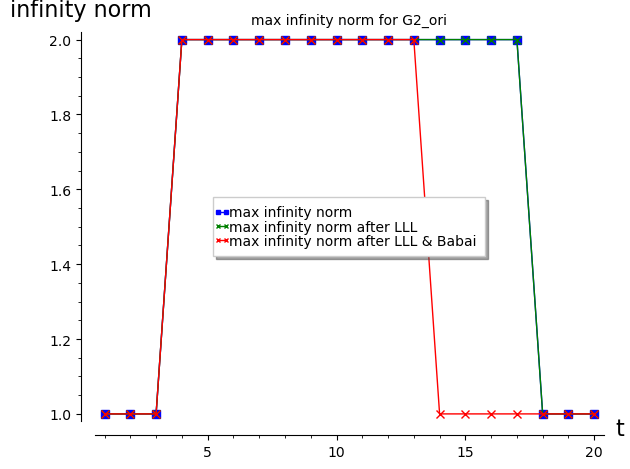

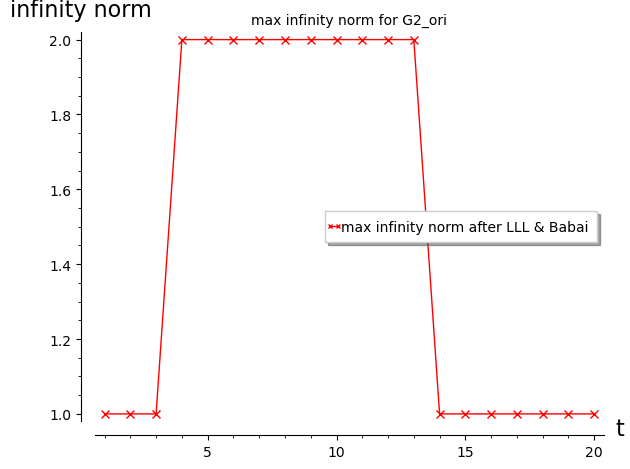

In [162]:
plot_G2_ori_babai_red_inf_norm = list_plot(curve_smallness_G2_ori_babai_red_infty_norm, plotjoined=True, marker='x', color='red', legend_label = 'max infinity norm after LLL & Babai', axes_labels=['t','infinity norm'],title='max infinity norm for G2_ori')
show(plot_G2_ori_infty_norm + plot_G2_ori_red_inf_norm + plot_G2_ori_babai_red_inf_norm)
show(plot_G2_ori_babai_red_inf_norm)

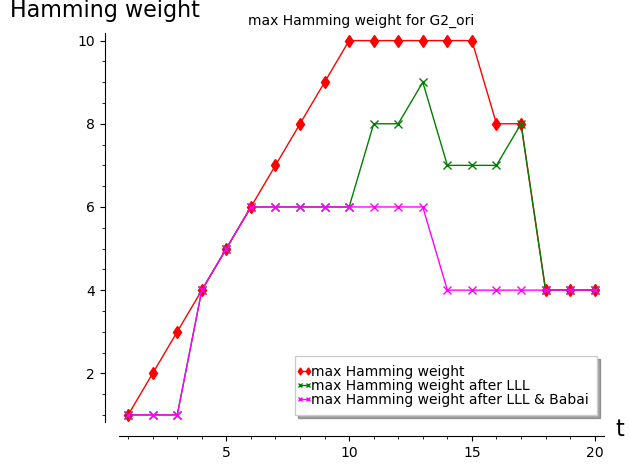

In [163]:
plot_G2_ori_babai_red_ham_weight = list_plot(curve_smallness_G2_ori_babai_red_hamming_weight, plotjoined=True, marker='x', color='magenta', legend_label = 'max Hamming weight after LLL & Babai', axes_labels=['t','Hamming weight'],title='max Hamming weight for G2_ori')
show(plot_G2_ori_hamming_weight+plot_G2_ori_red_ham_weight+plot_G2_ori_babai_red_ham_weight)

## Testing for $\mathbf{G}_3$

### With randomized $\mathbf{H}$

#### Greedy only

In [164]:
%%time
show(G3)
curve_linf_max_reduced_G3 = linf_max_reduced_curve(G3,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_G3)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 1, 1), (5, 2, 5), (6, 2, 5), (7, 2, 6), (8, 3, 8), (9, 3, 8), (10, 2, 8), (11, 2, 9), (12, 2, 9), (13, 2, 9), (14, 2, 9), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 6min 14s, sys: 3.22 s, total: 6min 17s
Wall time: 6min 17s


In [165]:
smallness_with_reduced(curve_smallness_G3,curve_linf_max_reduced_G3,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,8,1,4
4,16,1,8,1,4
5,15,2,8,1,4
6,14,2,10,2,9
7,13,2,10,2,9
8,12,2,10,2,9
9,11,2,10,2,9


In [166]:
curve_smallness_G3_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G3]
curve_smallness_G3_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G3]
print(curve_smallness_G3_red_infty_norm)
print(curve_smallness_G3_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 2), (7, 2), (8, 3), (9, 3), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 1), (5, 5), (6, 5), (7, 6), (8, 8), (9, 8), (10, 8), (11, 9), (12, 9), (13, 9), (14, 9), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


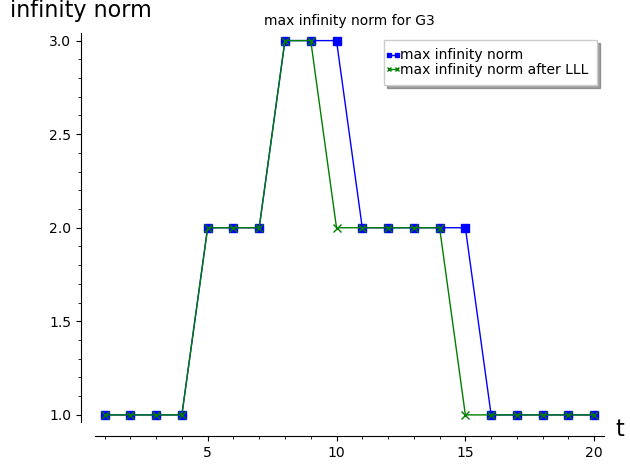

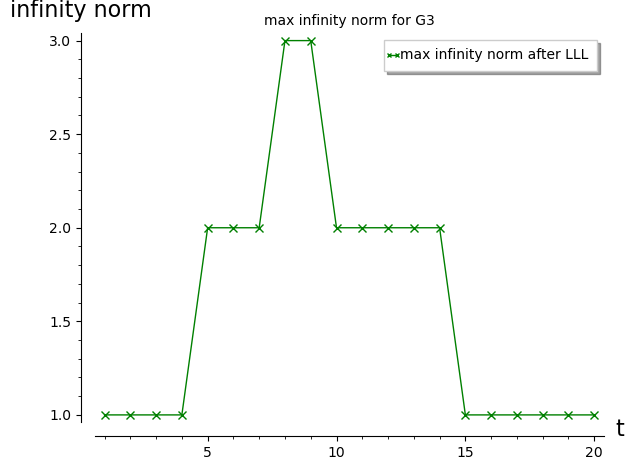

In [167]:
plot_G3_red_inf_norm = list_plot(curve_smallness_G3_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after LLL', axes_labels=['t','infinity norm'],title='max infinity norm for G3')
show(plot_G3_infty_norm +plot_G3_red_inf_norm)
show(plot_G3_red_inf_norm)

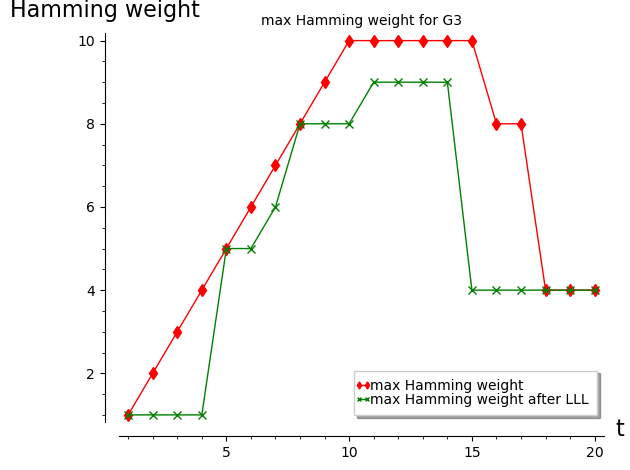

In [168]:
plot_G3_red_ham_weight = list_plot(curve_smallness_G3_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after LLL', axes_labels=['t','Hamming weight'],title='max Hamming weight for G3')
show(plot_G3_hamming_weight+plot_G3_red_ham_weight)

#### With Babai

In [169]:
%%time
show(G3)
curve_linf_max_reduced_babai_G3 = linf_max_reduced_babai_curve(G3,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_babai_G3)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 1), (3, 1, 1), (4, 1, 1), (5, 2, 5), (6, 2, 5), (7, 2, 6), (8, 3, 8), (9, 3, 8), (10, 2, 7), (11, 2, 7), (12, 1, 4), (13, 1, 4), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 8min 32s, sys: 3.42 s, total: 8min 36s
Wall time: 8min 36s


In [170]:
smallness_with_reduced(curve_smallness_G3,curve_linf_max_reduced_babai_G3,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,8,1,4
4,16,1,8,1,4
5,15,2,8,1,4
6,14,2,10,1,4
7,13,2,10,1,4
8,12,2,10,1,4
9,11,2,10,2,7


In [171]:
curve_smallness_G3_babai_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_babai_G3]
curve_smallness_G3_babai_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_babai_G3]
print(curve_smallness_G3_babai_red_infty_norm)
print(curve_smallness_G3_babai_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 2), (7, 2), (8, 3), (9, 3), (10, 2), (11, 2), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 1), (3, 1), (4, 1), (5, 5), (6, 5), (7, 6), (8, 8), (9, 8), (10, 7), (11, 7), (12, 4), (13, 4), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


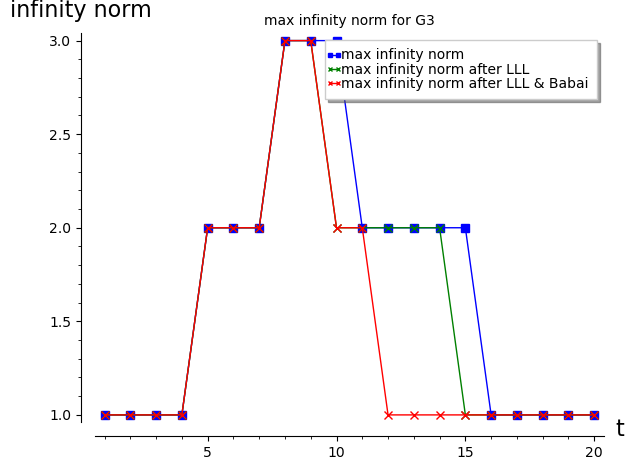

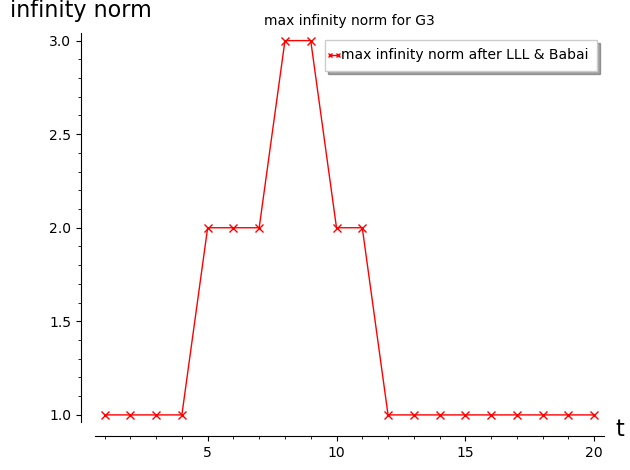

In [172]:
plot_G3_babai_red_inf_norm = list_plot(curve_smallness_G3_babai_red_infty_norm, plotjoined=True, marker='x', color='red', legend_label = 'max infinity norm after LLL & Babai', axes_labels=['t','infinity norm'],title='max infinity norm for G3')
show(plot_G3_infty_norm + plot_G3_red_inf_norm + plot_G3_babai_red_inf_norm)
show(plot_G3_babai_red_inf_norm)

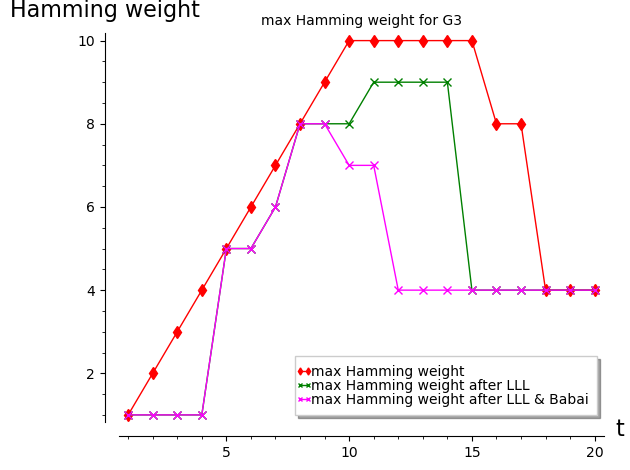

In [173]:
plot_G3_babai_red_ham_weight = list_plot(curve_smallness_G3_babai_red_hamming_weight, plotjoined=True, marker='x', color='magenta', legend_label = 'max Hamming weight after LLL & Babai', axes_labels=['t','Hamming weight'],title='max Hamming weight for G3')
show(plot_G3_hamming_weight+plot_G3_red_ham_weight+plot_G3_babai_red_ham_weight)

### Original $\mathbf{H}$

#### Greedy only

In [174]:
%%time
show(G3_ori)
curve_linf_max_reduced_G3_ori = linf_max_reduced_curve(G3_ori,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_G3_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 2), (3, 1, 2), (4, 1, 2), (5, 1, 2), (6, 1, 2), (7, 2, 7), (8, 2, 7), (9, 3, 9), (10, 2, 7), (11, 2, 8), (12, 2, 9), (13, 2, 9), (14, 2, 9), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 6min, sys: 3.19 s, total: 6min 3s
Wall time: 6min 3s


In [175]:
smallness_with_reduced(curve_smallness_G3_ori,curve_linf_max_reduced_G3_ori,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,8,1,4
4,16,1,8,1,4
5,15,2,8,1,4
6,14,2,10,2,9
7,13,2,10,2,9
8,12,2,10,2,9
9,11,2,10,2,8


In [176]:
curve_smallness_G3_ori_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_G3_ori]
curve_smallness_G3_ori_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_G3_ori]
print(curve_smallness_G3_ori_red_infty_norm)
print(curve_smallness_G3_ori_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 2), (9, 3), (10, 2), (11, 2), (12, 2), (13, 2), (14, 2), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 2), (4, 2), (5, 2), (6, 2), (7, 7), (8, 7), (9, 9), (10, 7), (11, 8), (12, 9), (13, 9), (14, 9), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


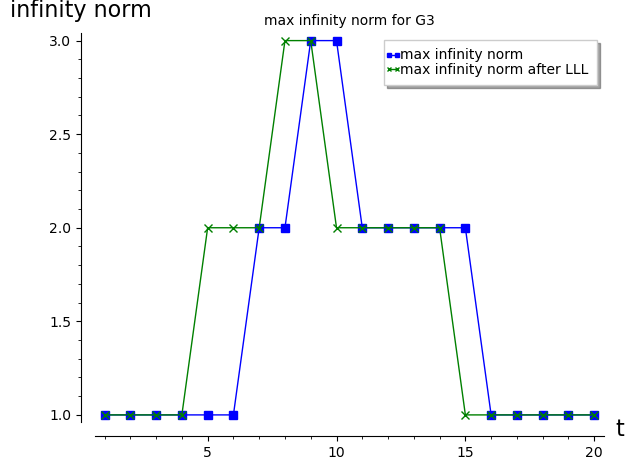

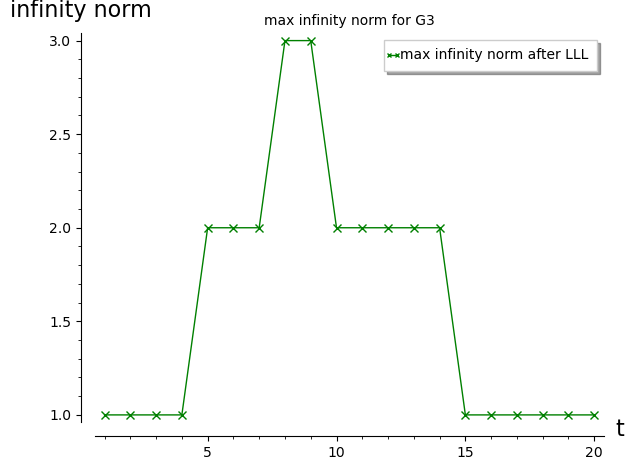

In [177]:
plot_G3_ori_red_inf_norm = list_plot(curve_smallness_G3_ori_red_infty_norm, plotjoined=True, marker='x', color='green', legend_label = 'max infinity norm after LLL', axes_labels=['t','infinity norm'],title='max infinity norm for G3_ori')
show(plot_G3_ori_infty_norm +plot_G3_red_inf_norm)
show(plot_G3_red_inf_norm)

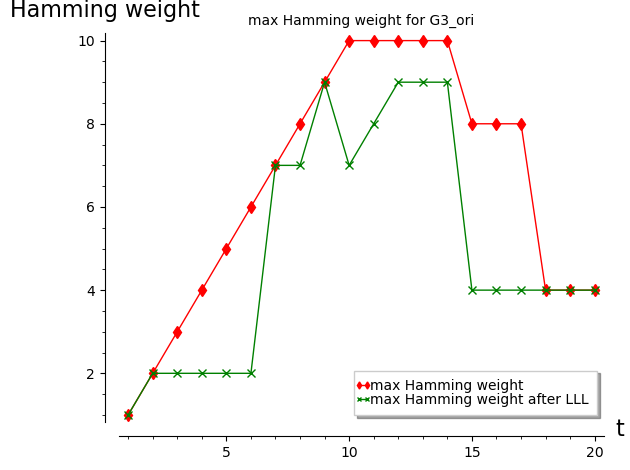

In [178]:
plot_G3_ori_red_ham_weight = list_plot(curve_smallness_G3_ori_red_hamming_weight, plotjoined=True, marker='x', color='green', legend_label = 'max Hamming weight after LLL', axes_labels=['t','Hamming weight'],title='max Hamming weight for G3_ori')
show(plot_G3_ori_hamming_weight+plot_G3_ori_red_ham_weight)

#### With Babai

In [179]:
%%time
show(G3_ori)
curve_linf_max_reduced_babai_G3_ori = linf_max_reduced_babai_curve(G3_ori,passes = 3, window =3 , s_min = 1, s_max = None)
print(curve_linf_max_reduced_babai_G3_ori)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 1, 1), (2, 1, 2), (3, 1, 2), (4, 1, 2), (5, 1, 2), (6, 1, 2), (7, 2, 7), (8, 2, 7), (9, 3, 9), (10, 2, 7), (11, 2, 7), (12, 1, 4), (13, 1, 4), (14, 1, 4), (15, 1, 4), (16, 1, 4), (17, 1, 4), (18, 1, 4), (19, 1, 4), (20, 1, 4)]
CPU times: user 8min 36s, sys: 3.61 s, total: 8min 40s
Wall time: 8min 40s


In [180]:
smallness_with_reduced(curve_smallness_G3_ori,curve_linf_max_reduced_babai_G3_ori,20)

,t,infinity norm bound,Hamming weight,infinity norm bound (reduced),Hamming weight (reduced)
0,20,1,4,1,4
1,19,1,4,1,4
2,18,1,4,1,4
3,17,1,8,1,4
4,16,1,8,1,4
5,15,2,8,1,4
6,14,2,10,1,4
7,13,2,10,1,4
8,12,2,10,1,4
9,11,2,10,2,7


In [181]:
curve_smallness_G3_ori_babai_red_infty_norm = [(s,linf) for (s, linf, wt) in curve_linf_max_reduced_babai_G3_ori]
curve_smallness_G3_ori_babai_red_hamming_weight = [(s,wt) for (s, linf, wt) in curve_linf_max_reduced_babai_G3_ori]
print(curve_smallness_G3_ori_babai_red_infty_norm)
print(curve_smallness_G3_ori_babai_red_hamming_weight)

[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 2), (9, 3), (10, 2), (11, 2), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)]
[(1, 1), (2, 2), (3, 2), (4, 2), (5, 2), (6, 2), (7, 7), (8, 7), (9, 9), (10, 7), (11, 7), (12, 4), (13, 4), (14, 4), (15, 4), (16, 4), (17, 4), (18, 4), (19, 4), (20, 4)]


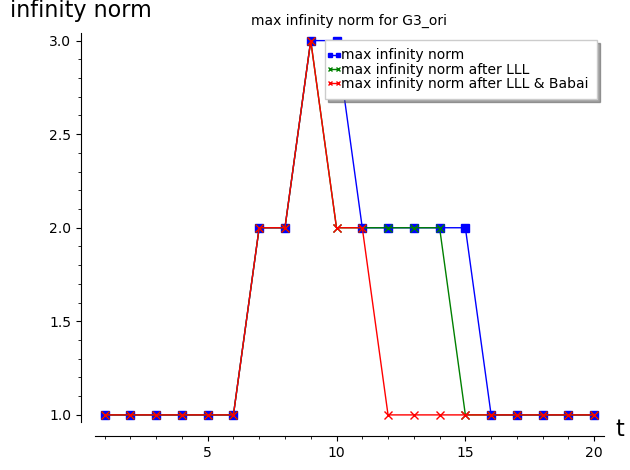

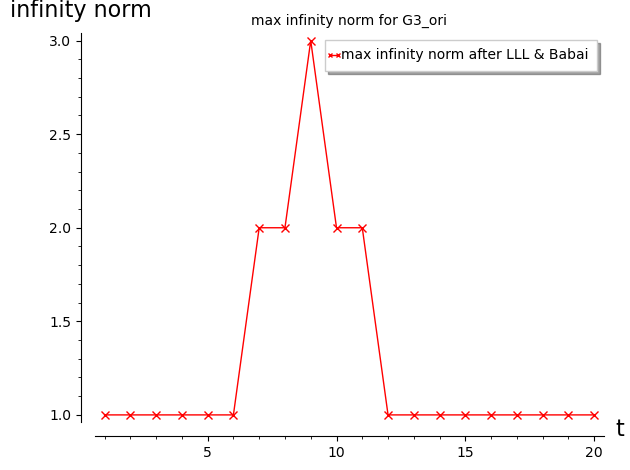

In [182]:
plot_G3_ori_babai_red_inf_norm = list_plot(curve_smallness_G3_ori_babai_red_infty_norm, plotjoined=True, marker='x', color='red', legend_label = 'max infinity norm after LLL & Babai', axes_labels=['t','infinity norm'],title='max infinity norm for G3_ori')
show(plot_G3_ori_infty_norm + plot_G3_ori_red_inf_norm + plot_G3_ori_babai_red_inf_norm)
show(plot_G3_ori_babai_red_inf_norm)

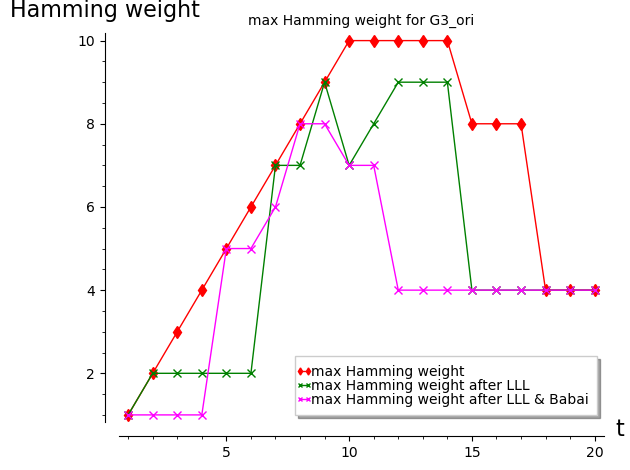

In [183]:
plot_G3_ori_babai_red_ham_weight = list_plot(curve_smallness_G3_babai_red_hamming_weight, plotjoined=True, marker='x', color='magenta', legend_label = 'max Hamming weight after LLL & Babai', axes_labels=['t','Hamming weight'],title='max Hamming weight for G3_ori')
show(plot_G3_ori_hamming_weight+plot_G3_ori_red_ham_weight+plot_G3_ori_babai_red_ham_weight)

# Final Choice

## Printing information for $\mathbf{G}$

In [69]:
G_20_10_3 = G1
show(G_20_10_3)
print(G_20_10_3)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[ 1  0  0  0  0  0 -1  0  0 -1]
[ 1  1  0  0  0  0  0  0  0 -1]
[ 1  0  0  0  0  0  0  0  1 -1]
[ 1  0  0 -1  0  0  0  0  0 -1]
[ 1  0  0  0  0  1  0  0  0 -1]
[ 1  0  0  0  1  0 -1  0  0  0]
[ 1  1  0  0  1  0  0  0  0  0]
[ 1  0  0  0  1  0  0  0  1  0]
[ 1  0  0 -1  1  0  0  0  0  0]
[ 1  0  0  0  1  1  0  0  0  0]
[ 0  0 -1  0  0  0 -1  0  0  0]
[-1  1 -1  0  0  0  0  0  0  0]
[-1  0 -1  0  0  0  0  0  1  0]
[ 0  0 -1 -1  0  0  0  0  0  0]
[ 0  0 -1  0  0  1  0  0  0  0]
[-1  0  0  0  0  0 -1 -1  0  0]
[-1  1  0  0  0  0  0 -1  0  0]
[ 0  0  0  0  0  0  0 -1  1  0]
[ 0  0  0 -1  0  0  0 -1  0  0]
[ 0  0  0  0  0  1  0 -1  0  0]


In [70]:
print(T1)
print(lambdas1)

[[0, 2, 3, 12, 13], [5, 9, 15, 19], [6, 7, 8, 16, 17], [1, 4, 11, 14]]
[(0, 1, -1, -1, 1), (1, -1, -1, 1), (1, -1, 0, -1, 1), (1, -1, -1, 1)]


## Empirical privacy analysis: proportion of $U$ that completely leaks the secret

Suppose we consider a fixed $U \subseteq [1,n]$. Then, $U$ completely leaks the secret if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_U)$, i.e., $\mathbf{e}_1^\top$ can be expressed as a $\mathbb{Q}$-linear combination of the rows of $\mathbf{G}_U$. We can prove the following lemma.

**Lemma**: Fix $U \subseteq [1,n]$ and the matrix $\mathbf{G}$. The following conditions are equivalent.
1. $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_U)$.
2. If $\mathbf{F}_{\mathbf{G}_U}$ is the canonical reduced row echelon form (RREF) of $\mathbf{G}_U$, then $\mathbf{F}_{\mathbf{G}_U}[1,\cdot] = \mathbf{e}_1^\top = (1,0,\dots,0) \in \mathbb{Q}^k$.

We define the function **rational_span(G)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{s \times k}$ as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G})$.

Suppose $\mathbf{G} \in \mathbb{Z}^{s \times k}$ and $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G})$. This means $\mathbf{e}_1^\top$ can be obtained using elementary row operations (over $\mathbb{Q}$) on $\mathbf{G}$. If $\mathbf{F}_\mathbf{G} \in \mathbb{Q}^{s \times k}$ is the RREF of $\mathbf{G}$, then it is unique lower triangular matrix such that $\mathbf{F}_\mathbf{G} = \mathbf{E}_\mathbf{G} \mathbf{G}$ for some invertible matrix $\mathbf{E}_\mathbf{G} \in \mathbb{Q}^{s \times s}$. By the RREF pivot condition, if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G})$, we must have $\mathbf{F}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$ (i.e., the first row of $\mathbf{F}_\mathbf{G}$ ($1$-based indexing) is $\mathbf{e}_1^\top$. In short: $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}) \Leftrightarrow \mathbf{F}_\mathbf{G}[1,\cdot] = \mathbf{e}_1^\top$. For fast testing, we consider the following equivalence:
\begin{align*}
    \mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}) \Leftrightarrow \mathrm{rank}_\mathbb{Q}(\mathbf{G}) = \mathrm{rank}_\mathbb{Q}\left(\begin{bmatrix}\mathbf{e}_1^\top\\\mathbf{G}\end{bmatrix}\right)
\end{align*}

We define the function **rational_span_S(G,S)** that takes a matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $S \subseteq [0,n-1]$ ($0$-based-index) as input and returns true if $\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_S)$.

In [96]:
from sage.all import QQ, vector

def rational_span(G):
    if G.nrows() == 0:
        return False
    k = G.ncols()
    e1 = vector(QQ, [1] + [0]*(k-1))
    A = G.change_ring(QQ)
    return A.rank() == A.stack(e1).rank()

def rational_span_S(G, S):
    """
    Return True iff e1^T is in Row_Q(G_S).
    """
    if len(S) == 0:
        return False

    # quick reject: if col0 restricted to S is all zeros
    if all(G[i,0] == 0 for i in S):
        return False

    G_S = G.matrix_from_rows(S)
    return rational_span(G_S)

We define $\Pr_{\text{complete leak}}(s,\mathbf{G})$ for a fixed matrix $\mathbf{G} \in \mathbb{Z}^{n \times k}$ and $s \in [1,n]$ as
\begin{align}
    \Pr_{\text{complete leak}}(s,\mathbf{G}) &\stackrel{\text{def}}{=} \frac{|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_S)\right)\}|}{|\{S\subseteq [1,n]: \left(|S| = s\right)\}|}\\
    &= \frac{1}{\binom{n}{s}}|\{S\subseteq [1,n]: \left(|S| = s\right) \land \left(\mathbf{e}_1^\top \in \mathrm{Row}_\mathbb{Q}(\mathbf{G}_S)\right)\}|
\end{align}

In [97]:
from itertools import combinations
from sage.all import binomial, QQ

def Pcomleak(s, G):
    """
    Exact Pr_{complete leak}(s, G) by enumerating all subsets S of size s.
    Works for small n (e.g., n=20).
    Returns an exact rational in QQ.
    """
    n = G.nrows()
    total = binomial(n, s)
    if total == 0:
        return QQ(0)

    good = 0
    for S in combinations(range(n), s):
        if rational_span_S(G, S):
            good += 1

    return QQ(good) / QQ(total)

Some test for **Pcomleak(s,G)**.

In [98]:
%%time
G_chosen = G_20_10_3
show(G_chosen)
Pcomleak17 = Pcomleak(17,G1)
Pcomleak16 = Pcomleak(16,G1)
Pcomleak15 = Pcomleak(15,G1)
Pcomleak14 = Pcomleak(14,G1)
show("17","--",Pcomleak17,"--",1-Pcomleak17)
show("16","--",Pcomleak16,"--",1-Pcomleak16)
show("15","--",Pcomleak15,"--",1-Pcomleak15)
show("14","--",Pcomleak14,"--",1-Pcomleak14)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

'17' '--' 1 '--' 0

'16' '--' 4843/4845 '--' 2/4845

'15' '--' 455/456 '--' 1/456

'14' '--' 38479/38760 '--' 281/38760

CPU times: user 6.22 s, sys: 3 μs, total: 6.22 s
Wall time: 6.22 s


Constructing the curve for $\Pr_{\text{complete leak}}(s,\mathbf{G})$ for a given $\mathbf{G}$ and $1\leq s\leq n$. 

In [99]:
def Pcomleak_curve(G, s_min=1, s_max=None):
    """
    Return the Pcomleak curve as a list of pairs [(s, Pcomleak(s,G)) for s in [s_min..s_max]] exactly (small n only).

    Parameters
    -----------
    s_min : int
        Minimum s to include (default 1).
    s_max : int or None
        Maximum s to include, inclusive (default n).

    Returns
    --------
    list of tuples
        [(s, QQ probability), ...]
    """
    n = G.nrows()
    if s_max is None:
        s_max = n
    return [(s, Pcomleak(s, G)) for s in range(s_min, s_max + 1)]

## Experiment

In [100]:
%%time
show(G_chosen)
# curve_comleak_G_chosen = Pcomleak_curve(G_chosen,s_min=1,s_max=None)
curve_comleak_G_chosen = [(s, float(p)) for (s,p) in Pcomleak_curve(G_chosen, s_min = 1, s_max = None)]
print(curve_comleak_G_chosen)

20 x 10 dense matrix over Integer Ring (use the '.str()' method to see the entries)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006398348813209494), (5, 0.03199174406604747), (6, 0.09762641898864809), (7, 0.2275283797729618), (8, 0.42948321028816383), (9, 0.6562395808525839), (10, 0.8130994392604299), (11, 0.905227435103596), (12, 0.9553147574819402), (13, 0.9807791537667698), (14, 0.992750257997936), (15, 0.9978070175438597), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
CPU times: user 1min 30s, sys: 11.9 ms, total: 1min 30s
Wall time: 1min 30s


Presenting using graph and tables.

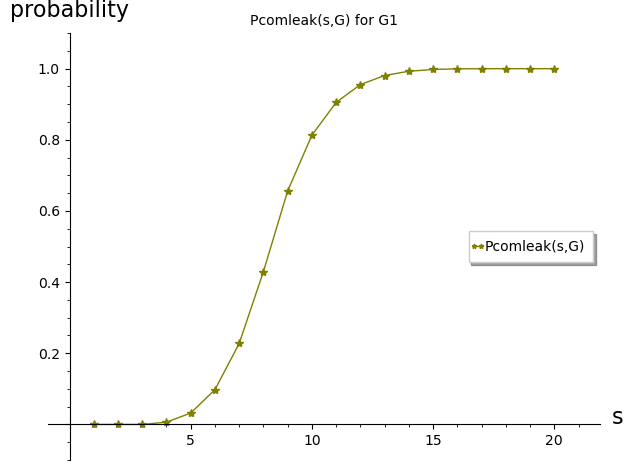

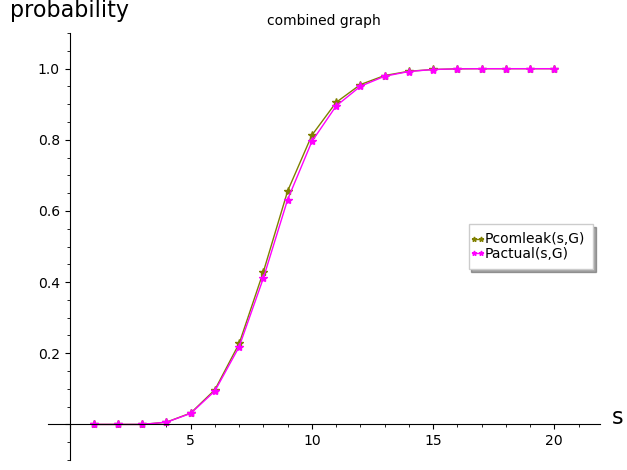

In [101]:
plot_G_chosen = list_plot(curve_comleak_G_chosen, plotjoined=True, marker='*', color = 'olive', legend_label = 'Pcomleak(s,G)',axes_labels=['s','probability'], title='Pcomleak(s,G) for G1')
show(plot_G_chosen, legend_loc = 'center right', axes_pad=0.1)
show(plot_G_chosen+plot_G1, axes_labels=['s','probability'],title='combined graph',legend_loc='center right', axes_pad =0.1)

Table preparation.

In [102]:
curve_correctness_chosen = curve_actual_G1
curve_comleak_chosen = curve_comleak_G_chosen
print(curve_correctness_chosen)
print(curve_comleak_chosen)

[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006191950464396285), (5, 0.030959752321981424), (6, 0.09414344685242518), (7, 0.21852425180598556), (8, 0.411709137096134), (9, 0.6322457728030484), (10, 0.7953625322046375), (11, 0.8951655155989521), (12, 0.9503929507025483), (13, 0.9787151702786377), (14, 0.9920794633642931), (15, 0.9976780185758514), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]
[(1, 0.0), (2, 0.0), (3, 0.0), (4, 0.006398348813209494), (5, 0.03199174406604747), (6, 0.09762641898864809), (7, 0.2275283797729618), (8, 0.42948321028816383), (9, 0.6562395808525839), (10, 0.8130994392604299), (11, 0.905227435103596), (12, 0.9553147574819402), (13, 0.9807791537667698), (14, 0.992750257997936), (15, 0.9978070175438597), (16, 0.9995872033023736), (17, 1.0), (18, 1.0), (19, 1.0), (20, 1.0)]


In [103]:
import pandas as pd
def leak_correctness(curve_correctness_chosen,curve_comleak_chosen,n):
    '''
    creating a combined table of curve_comleak_chosen and curve_correctness_chosen
    the number is rounded to eight digit after decimal point
    '''
    # convert each list of pairs into a small dataframe
    df_curve_comleak_chosen = pd.DataFrame(curve_comleak_chosen, columns = ['t',' Pr_complete-leak(t,G)'])
    df_curve_correctness_chosen = pd.DataFrame(curve_correctness_chosen, columns = ['t',' Pr_actual(t,G)'])
    # merge on 't' using outer join to keep all t values
    df = df_curve_correctness_chosen.merge(df_curve_comleak_chosen, on = 't', how = 'outer')
    df = df.sort_values('t', ascending=False).reset_index(drop=True)
    caption = f"experiment for correctness and privacy threshold for n = {n}"
    return df.style.set_caption(caption)

In [104]:
leak_correctness(curve_correctness_chosen,curve_comleak_chosen,20)

,t,"Pr_actual(t,G)","Pr_complete-leak(t,G)"
0,20,1.000000,1.000000
1,19,1.000000,1.000000
2,18,1.000000,1.000000
3,17,1.000000,1.000000
4,16,0.999587,0.999587
5,15,0.997678,0.997807
6,14,0.992079,0.992750
7,13,0.978715,0.980779
8,12,0.950393,0.955315
9,11,0.895166,0.905227
